In [1]:
import os
import numpy as np
import glob
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms
import shutil #用于拷贝
import xml.etree.ElementTree as ET
import pydicom

d:\anaconda\Lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
d:\anaconda\Lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
d:\anaconda\Lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


# tra+sag (ConvNeXt+YOLO)

In [ ]:
# tra-ConvNeXt_Tiny + sag-YOLO 
import json
import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision import transforms
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import glob
from ultralytics import YOLO
from collections import defaultdict
import pydicom 
import warnings
warnings.filterwarnings('ignore')

def read_dcm_as_uint8(dcm_path, window_center=40, window_width=400):
    """
    读取 DICOM 图像，并应用临床特定的窗宽窗位，将其安全转换为 8位(0-255) 数组
    默认使用脊柱常规软组织窗 (WC: 40, WW: 400)
    """
    ds = pydicom.dcmread(dcm_path)
    img = ds.pixel_array.astype(float)
    
    if hasattr(ds, 'RescaleSlope') and hasattr(ds, 'RescaleIntercept'):
        img = img * float(ds.RescaleSlope) + float(ds.RescaleIntercept)
        
    min_pixel = window_center - (window_width / 2)
    max_pixel = window_center + (window_width / 2)
    img = np.clip(img, min_pixel, max_pixel)
    
    img = (img - min_pixel) / (max_pixel - min_pixel + 1e-8) * 255
    return img.astype(np.uint8)


class RetinaNetWithConvNeXtPredictor:
    def __init__(self, retina_model_path, convnext_model_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        self.retina_model = torchvision.models.detection.retinanet_resnet50_fpn(
            pretrained=False, progress=True, num_classes=3
        )
        retina_checkpoint = torch.load(retina_model_path, map_location=self.device)
        if 'model_state_dict' in retina_checkpoint:
            self.retina_model.load_state_dict(retina_checkpoint['model_state_dict'])
        else:
            self.retina_model.load_state_dict(retina_checkpoint)
        self.retina_model.to(self.device)
        self.retina_model.eval()
        
        self.convnext_model = torchvision.models.convnext_tiny(pretrained=False)
        num_ftrs = self.convnext_model.classifier[2].in_features
        self.convnext_model.classifier[2] = torch.nn.Linear(num_ftrs, 2)
        
        convnext_checkpoint = torch.load(convnext_model_path, map_location=self.device)
        self.convnext_model.load_state_dict(convnext_checkpoint)
        self.convnext_model.to(self.device)
        self.convnext_model.eval()
        
        self.convnext_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    def extract_roi(self, dcm_path):
        img_array = read_dcm_as_uint8(dcm_path) 
        img_tensor = F.to_tensor(img_array).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            prediction = self.retina_model(img_tensor)

        if len(prediction) > 0:
            pred_boxes = prediction[0]['boxes'].cpu().numpy()
            pred_scores = prediction[0]['scores'].cpu().numpy()

            if len(pred_scores) > 0:
                max_score_idx = np.argmax(pred_scores)
                bbox = pred_boxes[max_score_idx]
                
                xmin, ymin, xmax, ymax = map(int, bbox)
                roi = img_array[ymin:ymax, xmin:xmax]
                
                roi_img = Image.fromarray(roi)
                return roi_img, bbox, img_array
                
        return None, None, None
    
    def predict(self, image_path):
        try:
            roi_img, bbox, original_img_array = self.extract_roi(image_path)
            
            if roi_img is None:
                print(f"No valid ROI detected in {image_path}")
                return 0, 0.0
            
            roi_img = roi_img.convert("RGB")
            roi_img_tensor = self.convnext_transform(roi_img).unsqueeze(0).to(self.device)
            
            with torch.no_grad():
                outputs = self.convnext_model(roi_img_tensor)
                probabilities = torch.softmax(outputs, dim=1)[:, 1]
                preds = (probabilities > 0.5).long()
            
            pred_label = preds.item()
            max_score = probabilities.item()
            
            print(f"Tra prediction - DCM: {os.path.basename(image_path)}, Prob: {max_score:.4f}, Pred: {pred_label}")
            return pred_label, max_score
            
        except Exception as e:
            print(f"Error predicting {image_path}: {e}")
            return 0, 0.0


class YOLOPredictor:
    def __init__(self, model_path):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = YOLO(model_path)
    
    def predict(self, dcm_path):
        try:
            img_uint8 = read_dcm_as_uint8(dcm_path)
            img_rgb = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2RGB)
            
            results = self.model(img_rgb, verbose=False)
            
            if len(results) > 0 and len(results[0].boxes) > 0:
                boxes = results[0].boxes
                scores = boxes.conf.cpu().numpy()
                labels = boxes.cls.cpu().numpy()
                
                max_score_idx = np.argmax(scores)
                pred_label = int(labels[max_score_idx]) + 1
                max_score = float(scores[max_score_idx])
                
                print(f"Sag prediction - DCM: {os.path.basename(dcm_path)}, Score: {max_score:.4f}, Pred: {pred_label}")
            else:
                pred_label = 0
                max_score = 0.0
                print(f"Sag prediction - DCM: {os.path.basename(dcm_path)}, No detection")
                
            return pred_label, max_score
            
        except Exception as e:
            print(f"Error predicting {dcm_path}: {e}")
            return 0, 0.0


def get_true_label(image_path):
    json_path = os.path.splitext(image_path)[0] + '.json'
    
    if os.path.exists(json_path):
        try:
            with open(json_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            if 'shapes' in data and len(data['shapes']) > 0:
                label_str = data['shapes'][0]['label']
                return int(label_str)
            else:
                return 0
        except Exception as e:
            print(f"Error reading JSON {json_path}: {e}")
            return 0
    else:
        return 0


def process_patient_data(base_dir, retina_convnext_model, yolo_model):
    image_results = []
    patient_data = defaultdict(lambda: {
        'tra_images': [],
        'sag_images': [],
        'dataset_type': '',
        'p_true_label': 0
    })
    
    dataset_folders = ['train-sag', 'valid-sag', 'test-sag']
    
    for dataset_folder in dataset_folders:
        dataset_path = os.path.join(base_dir, dataset_folder)
        dataset_type = dataset_folder.split('-')[0]
        
        if not os.path.exists(dataset_path):
            print(f"Dataset folder not found: {dataset_path}")
            continue
            
        patient_folders = [f for f in os.listdir(dataset_path) 
                           if os.path.isdir(os.path.join(dataset_path, f))]
        
        for patient_folder in patient_folders:
            patient_path = os.path.join(dataset_path, patient_folder)
            print(f"Processing patient: {patient_folder}")
            
            tra_folder = os.path.join(patient_path, 'tra')
            if os.path.exists(tra_folder):
                tra_images = glob.glob(os.path.join(tra_folder, '*.dcm'))
                print(f"  Found {len(tra_images)} tra dcm images")
                
                for image_path in tra_images:
                    pred_label, max_score = retina_convnext_model.predict(image_path)
                    true_label = get_true_label(image_path)
                    
                    image_results.append({
                        'patient_name': patient_folder,
                        'image_path': os.path.abspath(image_path),
                        'dataset_type': dataset_type,
                        'image_type': 'tra',
                        'true_label': true_label,
                        'pred_label': pred_label,
                        'max_score': max_score
                    })
                    
                    patient_data[patient_folder]['tra_images'].append({
                        'path': os.path.abspath(image_path),
                        'score': max_score,
                        'true_label': true_label
                    })
                    patient_data[patient_folder]['dataset_type'] = dataset_type
            
            sag_folder = os.path.join(patient_path, 'sag', 't2')
            if os.path.exists(sag_folder):
                sag_images = glob.glob(os.path.join(sag_folder, '*.dcm'))
                print(f"  Found {len(sag_images)} sag dcm images")
                
                for image_path in sag_images:
                    pred_label, max_score = yolo_model.predict(image_path)
                    true_label = get_true_label(image_path)
                    
                    image_results.append({
                        'patient_name': patient_folder,
                        'image_path': os.path.abspath(image_path),
                        'dataset_type': dataset_type,
                        'image_type': 'sag',
                        'true_label': true_label,
                        'pred_label': pred_label,
                        'max_score': max_score
                    })
                    
                    patient_data[patient_folder]['sag_images'].append({
                        'path': os.path.abspath(image_path),
                        'score': max_score,
                        'true_label': true_label
                    })
                    patient_data[patient_folder]['dataset_type'] = dataset_type
                    
                    if true_label == 1:
                        patient_data[patient_folder]['p_true_label'] = 1
    
    return image_results, patient_data


def create_patient_level_csv(patient_data):
    patient_results = []
    for patient_name, data in patient_data.items():
        tra_images_sorted = sorted(data['tra_images'], key=lambda x: x['score'], reverse=True)
        sag_images_sorted = sorted(data['sag_images'], key=lambda x: x['score'], reverse=True)
        
        patient_result = {
            'patient_name': patient_name,
            'tra_top1_path': tra_images_sorted[0]['path'] if len(tra_images_sorted) > 0 else '',
            'tra_top1_score': tra_images_sorted[0]['score'] if len(tra_images_sorted) > 0 else 0.0,
            'tra_top2_path': tra_images_sorted[1]['path'] if len(tra_images_sorted) > 1 else '',
            'tra_top2_score': tra_images_sorted[1]['score'] if len(tra_images_sorted) > 1 else 0.0,
            'tra_top3_path': tra_images_sorted[2]['path'] if len(tra_images_sorted) > 2 else '',
            'tra_top3_score': tra_images_sorted[2]['score'] if len(tra_images_sorted) > 2 else 0.0,
            'sag_top1_path': sag_images_sorted[0]['path'] if len(sag_images_sorted) > 0 else '',
            'sag_top1_score': sag_images_sorted[0]['score'] if len(sag_images_sorted) > 0 else 0.0,
            'sag_top2_path': sag_images_sorted[1]['path'] if len(sag_images_sorted) > 1 else '',
            'sag_top2_score': sag_images_sorted[1]['score'] if len(sag_images_sorted) > 1 else 0.0,
            'sag_top3_path': sag_images_sorted[2]['path'] if len(sag_images_sorted) > 2 else '',
            'sag_top3_score': sag_images_sorted[2]['score'] if len(sag_images_sorted) > 2 else 0.0,
            'p_true_label': data['p_true_label'],
            'dataset_type': data['dataset_type']
        }
        patient_results.append(patient_result)
    return patient_results


def main():
    print("Loading models...")
    retina_convnext_model = RetinaNetWithConvNeXtPredictor(
        retina_model_path=r"D:\MED\SpM\SpM_pth\Retina\3_train_mIou_0.8730000257492065_valid_mIou_0.8809999823570251.pth",
        convnext_model_path=r"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_ConvNeXt_Tiny_pth\epoch_3_train_auc_0.9972_valid_auc_0.9797.pth" 
    )
    
    yolo_model = YOLOPredictor(
        r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\best_model.pt"
    )
    
    base_dir = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini"
    print("Processing patient DICOM data...")
    image_results, patient_data = process_patient_data(base_dir, retina_convnext_model, yolo_model)
    
    print("Creating image-level CSV...")
    image_df = pd.DataFrame(image_results)
    output_dir = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini"
    os.makedirs(output_dir, exist_ok=True)
    
    image_csv_path = os.path.join(output_dir, 'image_predictions_mini_DCM.csv')
    image_df.to_csv(image_csv_path, index=False, encoding='utf-8-sig')
    print(f"Image-level CSV created at: {image_csv_path}")
    
    print("Creating patient-level CSV...")
    patient_results = create_patient_level_csv(patient_data)
    patient_df = pd.DataFrame(patient_results)
    
    patient_csv_path = os.path.join(output_dir, 'retinayolo_patient_predictions_detailed_mini_ConvnextYOLO_DCM.csv')
    patient_df.to_csv(patient_csv_path, index=False, encoding='utf-8-sig')
    print(f"Patient-level CSV created at: {patient_csv_path}")
    
    print("🎉 Done!")
    print(f"Processed {len(image_results)} DICOM files and {len(patient_results)} patients.")

if __name__ == "__main__":
    main()

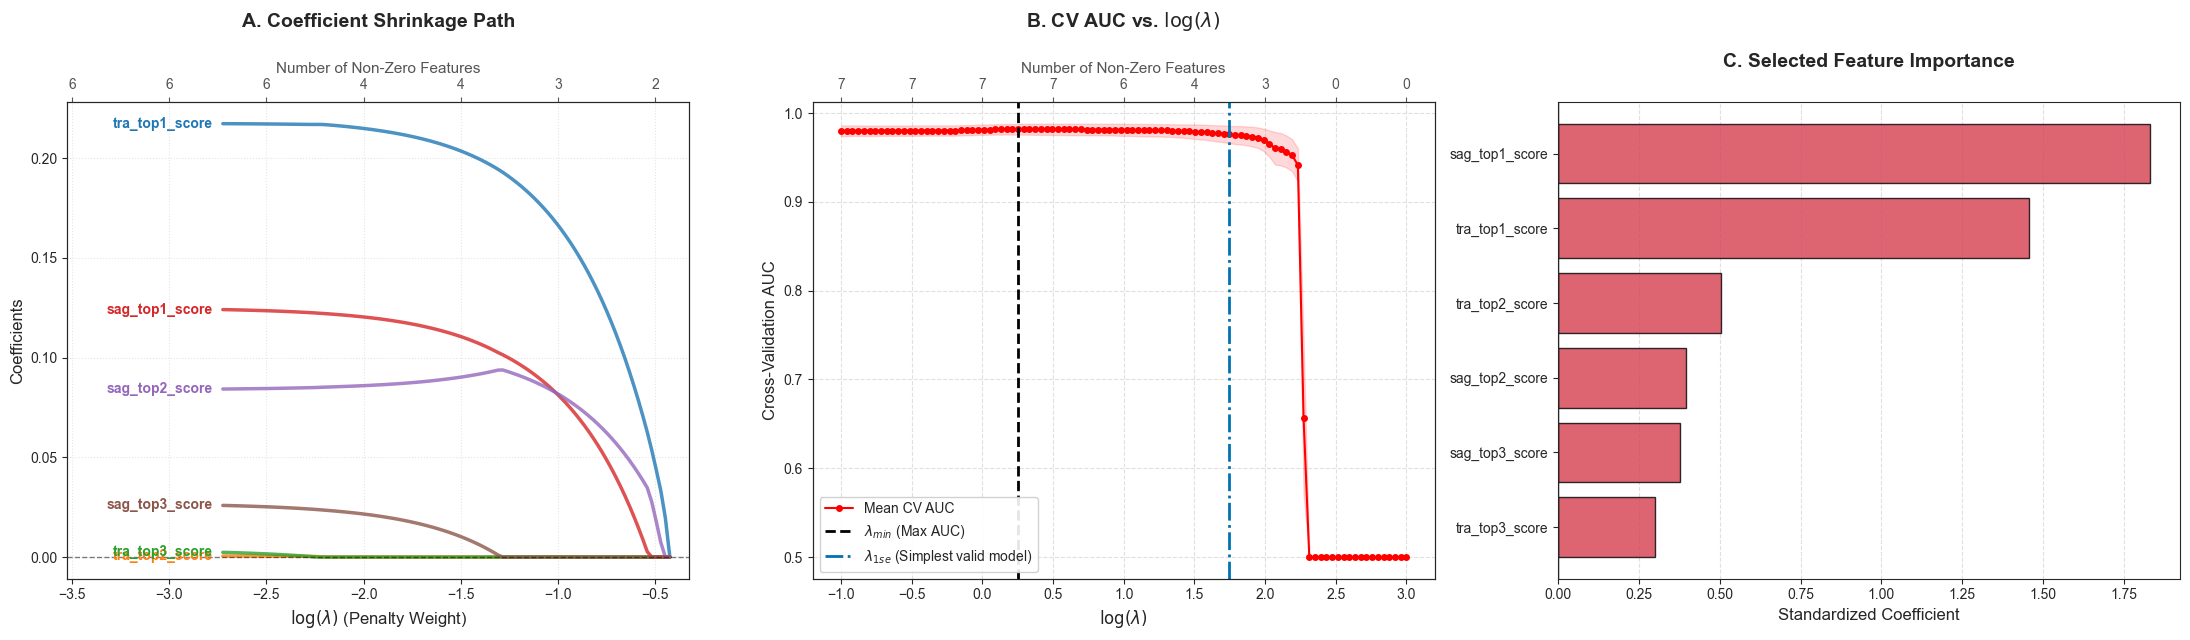

--- LASSO 统计学诊断结论 ---
🥇 [绝对最优] λ_min  : log(λ)=0.253, AUC=0.9819 (对应保留特征数: 7)
🥈 [简约最优] λ_1se  : log(λ)=1.747, AUC=0.9760 (对应保留特征数: 3)


In [ ]:
# LASSO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegressionCV, lasso_path
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

file_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\retinayolo_patient_predictions_detailed_mini_ConvnextYOLO.csv"
df = pd.read_csv(file_path)

features = [
    'tra_top1_score', 'tra_top2_score', 'tra_top3_score',
    'sag_top1_score', 'sag_top2_score', 'sag_top3_score'
]
target = 'p_true_label'

X = df[features]
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cv_folds = 5
lasso_model = LogisticRegressionCV(
    Cs=np.logspace(-3, 1, 100), 
    cv=cv_folds, penalty='l1', solver='liblinear', 
    random_state=42, max_iter=10000, class_weight='balanced',
    scoring='roc_auc'
)
lasso_model.fit(X_scaled, y)

alphas_path, coefs_path, _ = lasso_path(X_scaled, y, eps=5e-3)
log_alphas_path = np.log10(alphas_path)

non_zeros_A = np.sum(np.abs(coefs_path) > 1e-7, axis=0) 
mean_coefs_path = np.mean(lasso_model.coefs_paths_[1], axis=0)
non_zeros_B = np.sum(np.abs(mean_coefs_path) > 1e-7, axis=1)

log_lambdas = -np.log10(lasso_model.Cs_)
scores = lasso_model.scores_[1]
mean_scores = np.mean(scores, axis=0)

se_scores = np.std(scores, axis=0) / np.sqrt(cv_folds)

idx_min = np.argmax(mean_scores)
log_lambda_min = log_lambdas[idx_min]
max_auc = mean_scores[idx_min]
se_at_min = se_scores[idx_min]

threshold_1se = max_auc - se_at_min
valid_indices = np.where(mean_scores >= threshold_1se)[0]
idx_1se = valid_indices[0]
log_lambda_1se = log_lambdas[idx_1se]

# Figures
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6.5), dpi=100)

colors = plt.get_cmap('tab10')
for i in range(len(features)):
    line = ax1.plot(log_alphas_path, coefs_path[i], color=colors(i), lw=2.5, alpha=0.8, label=features[i])
    x_pos = log_alphas_path[-1]
    y_pos = coefs_path[i][-1]
    ax1.text(x_pos - 0.05, y_pos, features[i], color=colors(i), 
             fontsize=10, fontweight='bold', ha='right', va='center')

ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel(r'$\log(\lambda)$ (Penalty Weight)', fontsize=12)
ax1.set_ylabel('Coefficients', fontsize=12)
ax1.set_title('A. Coefficient Shrinkage Path', fontsize=14, fontweight='bold', pad=25)

min_log, max_log = min(log_alphas_path), max(log_alphas_path)
ax1.set_xlim(left=min_log - 0.8, right=max_log + 0.1) 
ax1.grid(True, linestyle=':', alpha=0.5)

ax1_top = ax1.twiny()
ax1_top.set_xlim(ax1.get_xlim())
valid_ticks_A = [t for t in ax1.get_xticks() if min(ax1.get_xlim()) <= t <= max(ax1.get_xlim())]
tick_labels_A = [str(non_zeros_A[(np.abs(log_alphas_path - t)).argmin()]) for t in valid_ticks_A]
ax1_top.set_xticks(valid_ticks_A)
ax1_top.set_xticklabels(tick_labels_A)
ax1_top.set_xlabel('Number of Non-Zero Features', fontsize=11, color='#555555')
ax1_top.tick_params(axis='x', colors='#555555', labelsize=10)


ax2.plot(log_lambdas, mean_scores, 'r-o', markersize=4, label='Mean CV AUC')
ax2.fill_between(log_lambdas, mean_scores - se_scores, mean_scores + se_scores, color='red', alpha=0.15)

ax2.axvline(log_lambda_min, color='black', linestyle='--', lw=2, label=r'$\lambda_{min}$ (Max AUC)')
ax2.axvline(log_lambda_1se, color='#0072B2', linestyle='-.', lw=2, label=r'$\lambda_{1se}$ (Simplest valid model)')

ax2.set_xlabel(r'$\log(\lambda)$', fontsize=12)
ax2.set_ylabel('Cross-Validation AUC', fontsize=12)
ax2.set_title(r'B. CV AUC vs. $\log(\lambda)$', fontsize=14, fontweight='bold', pad=25)

ax2.legend(loc='lower left', framealpha=0.9)
ax2.grid(True, linestyle='--', alpha=0.6)

ax2_top = ax2.twiny()
ax2_top.set_xlim(ax2.get_xlim()) 
valid_ticks_B = [t for t in ax2.get_xticks() if min(ax2.get_xlim()) <= t <= max(ax2.get_xlim())]
tick_labels_B = [str(non_zeros_B[(np.abs(log_lambdas - t)).argmin()]) for t in valid_ticks_B]
ax2_top.set_xticks(valid_ticks_B)
ax2_top.set_xticklabels(tick_labels_B)
ax2_top.set_xlabel('Number of Non-Zero Features', fontsize=11, color='#555555')
ax2_top.tick_params(axis='x', colors='#555555', labelsize=10)


coefs_final = lasso_model.coef_[0]
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefs_final})
coef_df = coef_df.sort_values(by='Coefficient', ascending=True)

bar_colors = ['#d53e4f' if c > 0 else '#3288bd' for c in coef_df['Coefficient']]
ax3.barh(coef_df['Feature'], coef_df['Coefficient'], color=bar_colors, edgecolor='black', alpha=0.8)
ax3.axvline(x=0, color='black', lw=1)
ax3.set_xlabel('Standardized Coefficient', fontsize=12)
ax3.set_title('C. Selected Feature Importance', fontsize=14, fontweight='bold', pad=25)
ax3.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"--- LASSO 统计学诊断结论 ---")
print(f"🥇 [绝对最优] λ_min  : log(λ)={log_lambda_min:.3f}, AUC={max_auc:.4f} (对应保留特征数: {non_zeros_B[idx_min]})")
print(f"🥈 [简约最优] λ_1se  : log(λ)={log_lambda_1se:.3f}, AUC={mean_scores[idx_1se]:.4f} (对应保留特征数: {non_zeros_B[idx_1se]})")

## Fusion

🚀 正在启动 3 因素模型 (LASSO精简版) 分析流程...


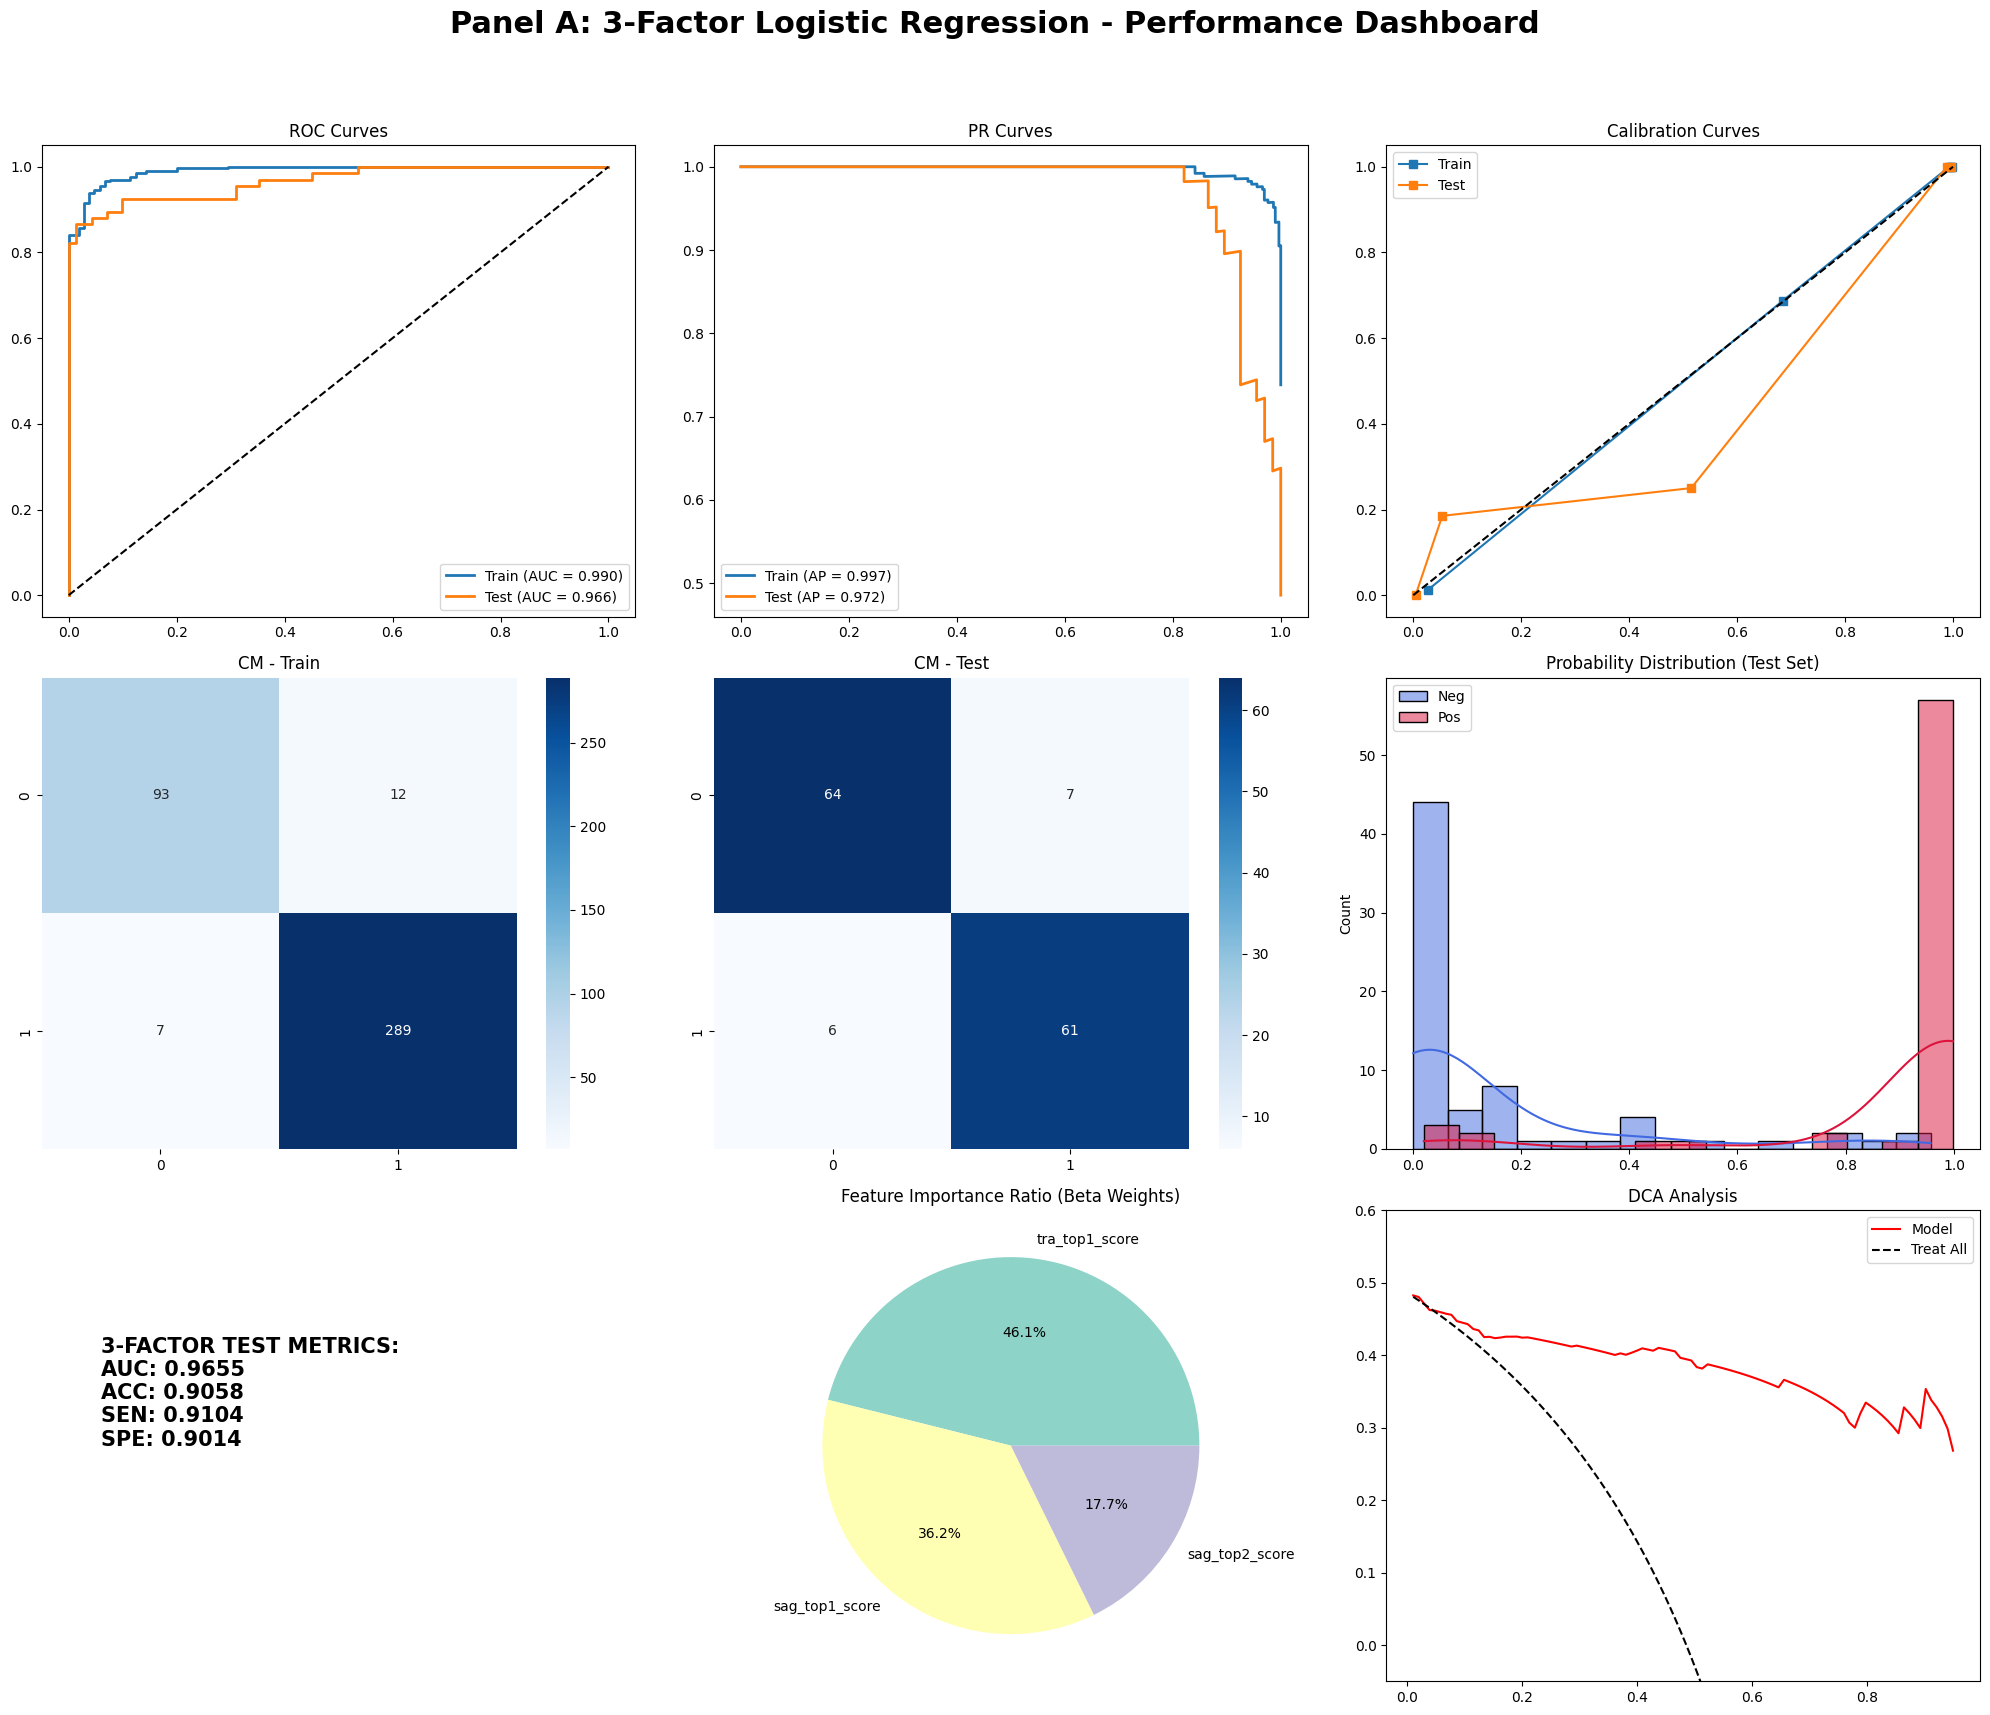

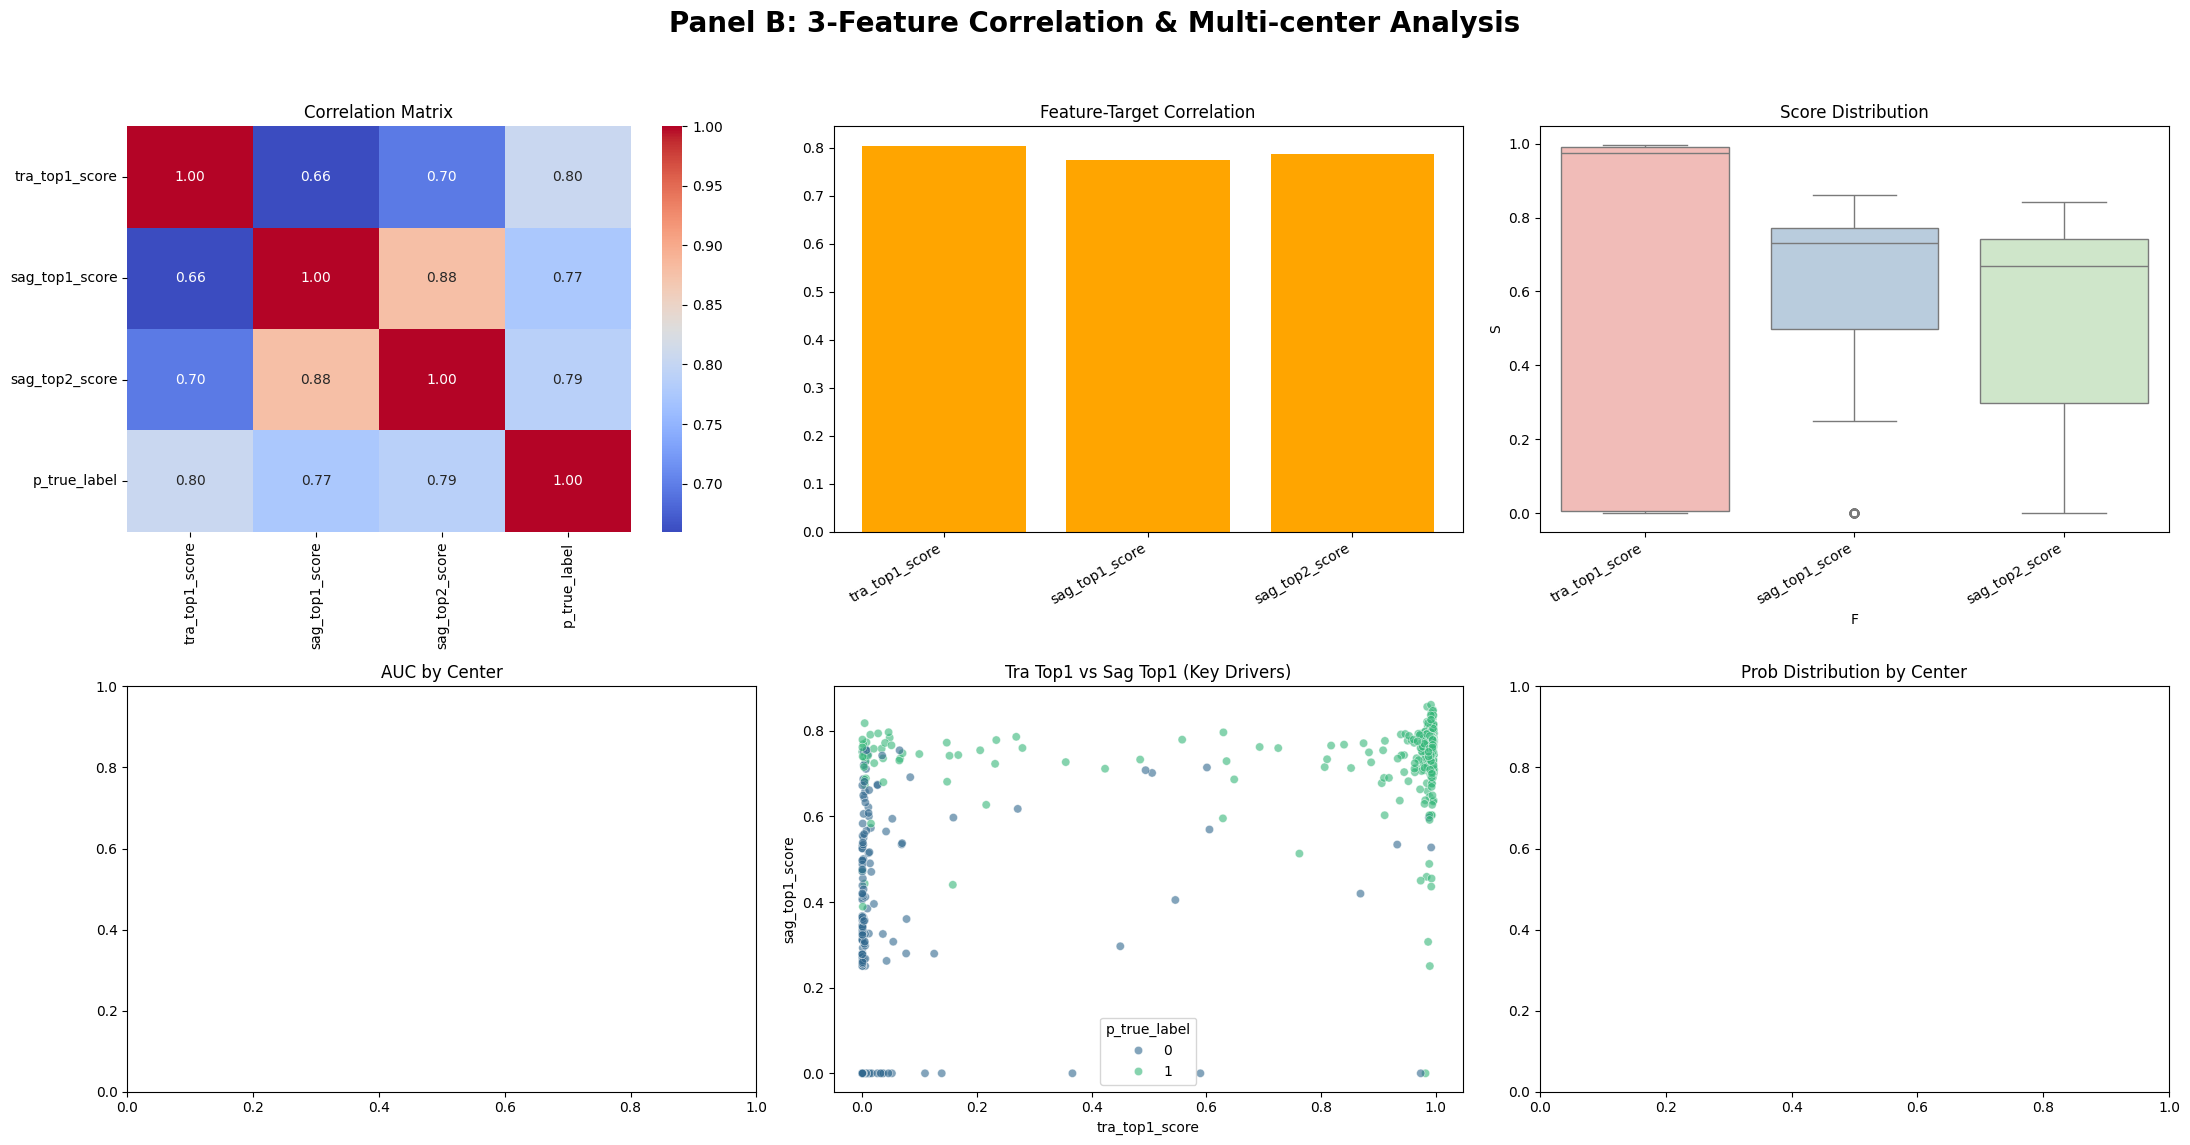


✅ 3因素模型已成功打包保存至: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\logistic_lasso_3factors_convnext.pkl

[ 3 因素 LASSO 数学表达式 ]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# Logistic：tra_top1, sag_top1, sag_top2
import pandas as pd
import numpy as np
import os
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, 
                             precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from IPython.display import display, Math

def calculate_detailed_metrics(y_true, y_pred, y_pred_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / len(y_true)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_score = roc_auc_score(y_true, y_pred_proba)
    ap_score = average_precision_score(y_true, y_pred_proba)
    return {'accuracy': accuracy, 'sensitivity': sensitivity, 'specificity': specificity, 
            'auc': auc_score, 'ap': ap_score, 'cm': cm}

def plot_comprehensive_performance(y_train, y_train_proba, y_test, y_test_proba, 
                                  train_metrics, test_metrics, feature_columns, logreg):
    fig, axes = plt.subplots(3, 3, figsize=(20, 18))
    plt.suptitle("Panel A: 3-Factor Logistic Regression - Performance Dashboard", fontsize=22, fontweight='bold')

    for y, p, m, l, c in [(y_train, y_train_proba, train_metrics, 'Train', 'darkorange'), 
                          (y_test, y_test_proba, test_metrics, 'Test', 'blue')]:
        fpr, tpr, _ = roc_curve(y, p)
        axes[0,0].plot(fpr, tpr, label=f'{l} (AUC = {m["auc"]:.3f})', lw=2)
        prec, rec, _ = precision_recall_curve(y, p)
        axes[0,1].plot(rec, prec, label=f'{l} (AP = {m["ap"]:.3f})', lw=2)
        prob_true, prob_pred = calibration_curve(y, p, n_bins=5, strategy='quantile')
        axes[0,2].plot(prob_pred, prob_true, 's-', label=f'{l}')

    axes[0,0].set_title("ROC Curves"); axes[0,0].legend(); axes[0,0].plot([0, 1], [0, 1], 'k--')
    axes[0,1].set_title("PR Curves"); axes[0,1].legend()
    axes[0,2].set_title("Calibration Curves"); axes[0,2].legend(); axes[0,2].plot([0, 1], [0, 1], 'k--')

    sns.heatmap(train_metrics['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[1,0]); axes[1,0].set_title("CM - Train")
    sns.heatmap(test_metrics['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[1,1]); axes[1,1].set_title("CM - Test")

    sns.histplot(x=y_test_proba[y_test==0], bins=15, color='royalblue', label='Neg', ax=axes[1,2], kde=True, alpha=0.5)
    sns.histplot(x=y_test_proba[y_test==1], bins=15, color='crimson', label='Pos', ax=axes[1,2], kde=True, alpha=0.5)
    axes[1,2].set_title("Probability Distribution (Test Set)"); axes[1,2].legend()

    axes[2,0].axis('off')
    txt = f"3-FACTOR TEST METRICS:\nAUC: {test_metrics['auc']:.4f}\nACC: {test_metrics['accuracy']:.4f}\nSEN: {test_metrics['sensitivity']:.4f}\nSPE: {test_metrics['specificity']:.4f}"
    axes[2,0].text(0.1, 0.5, txt, fontsize=15, fontweight='bold')

    importance = np.abs(logreg.coef_[0])
    axes[2,1].pie(importance, labels=feature_columns, autopct='%1.1f%%', colors=sns.color_palette("Set3"))
    axes[2,1].set_title("Feature Importance Ratio (Beta Weights)")

    def calculate_nb(y_t, y_p, ths):
        n = len(y_t)
        return [(np.sum((y_p >= t) & (y_t == 1)) / n) - (np.sum((y_p >= t) & (y_t == 0)) / n) * (t / (1 - t)) if t < 1.0 else 0 for t in ths]
    ths = np.linspace(0.01, 0.95, 100)
    axes[2,2].plot(ths, calculate_nb(y_test, y_test_proba, ths), 'r-', label='Model')
    axes[2,2].plot(ths, calculate_nb(y_test, np.ones(len(y_test)), ths), 'k--', label='Treat All')
    axes[2,2].set_title("DCA Analysis"); axes[2,2].legend(); axes[2,2].set_ylim(-0.05, 0.6)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def plot_feature_and_center_analysis(df, feature_cols):
    plt.figure(figsize=(22, 12))
    plt.suptitle("Panel B: 3-Feature Correlation & Multi-center Analysis", fontsize=20, fontweight='bold')
    
    plt.subplot(2, 3, 1)
    sns.heatmap(df[feature_cols + ['p_true_label']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation Matrix")
    
    plt.subplot(2, 3, 2)
    plt.bar(feature_cols, [df[f].corr(df['p_true_label']) for f in feature_cols], color='orange')
    plt.xticks(rotation=30, ha='right'); plt.title("Feature-Target Correlation")
    
    plt.subplot(2, 3, 3)
    df_melt = df.melt(value_vars=feature_cols, var_name='F', value_name='S')
    sns.boxplot(data=df_melt, x='F', y='S', palette='Pastel1')
    plt.xticks(rotation=30, ha='right'); plt.title("Score Distribution")
    
    plt.subplot(2, 3, 4)
    if 'center' in df.columns:
        centers = df['center'].unique()
        valid_centers = [c for c in centers if len(df[df['center']==c]['p_true_label'].unique()) > 1]
        if valid_centers:
            aucs = [roc_auc_score(df[df['center']==c]['p_true_label'], df[df['center']==c]['logreg_prob']) for c in valid_centers]
            plt.bar(valid_centers, aucs, color='teal')
    plt.title("AUC by Center")
    
    plt.subplot(2, 3, 5)
    sns.scatterplot(data=df, x='tra_top1_score', y='sag_top1_score', hue='p_true_label', alpha=0.6, palette='viridis')
    plt.title("Tra Top1 vs Sag Top1 (Key Drivers)")
    
    plt.subplot(2, 3, 6)
    if 'center' in df.columns:
        sns.violinplot(data=df, x='center', y='logreg_prob', hue='p_true_label', split=True, palette='muted')
    plt.title("Prob Distribution by Center")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

csv_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\retinayolo_patient_predictions_detailed_mini_ConvnextYOLO.csv"

if os.path.exists(csv_path):
    print("🚀 正在启动 3 因素模型 (LASSO精简版) 分析流程...")
    df = pd.read_csv(csv_path)
    
    lasso_features = ['tra_top1_score', 'sag_top1_score', 'sag_top2_score']
    df[lasso_features] = df[lasso_features].fillna(0)

    train_valid_df = df[df['dataset_type'].isin(['train', 'valid'])].copy()
    test_df = df[df['dataset_type'] == 'test'].copy()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(train_valid_df[lasso_features].values)
    X_test_scaled = scaler.transform(test_df[lasso_features].values)

    final_logreg = LogisticRegression(random_state=42, max_iter=1000)
    final_logreg.fit(X_train_scaled, train_valid_df['p_true_label'].values)

    y_train_proba = final_logreg.predict_proba(X_train_scaled)[:, 1]
    y_test_proba = final_logreg.predict_proba(X_test_scaled)[:, 1]
    y_test_pred = (y_test_proba > 0.5).astype(int)

    train_metrics = calculate_detailed_metrics(train_valid_df['p_true_label'], (y_train_proba > 0.5).astype(int), y_train_proba)
    test_metrics = calculate_detailed_metrics(test_df['p_true_label'], y_test_pred, y_test_proba)

    train_valid_df.loc[:, 'logreg_prob'] = y_train_proba
    test_df.loc[:, 'logreg_prob'] = y_test_proba
    combined_df = pd.concat([train_valid_df, test_df], ignore_index=True)

    plot_comprehensive_performance(train_valid_df['p_true_label'], y_train_proba, 
                                  test_df['p_true_label'], y_test_proba, 
                                  train_metrics, test_metrics, lasso_features, final_logreg)
    plot_feature_and_center_analysis(combined_df, lasso_features)

    output_dir = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini"
    package_path = os.path.join(output_dir, 'logistic_lasso_3factors_convnext.pkl')
    package = {
        'model': final_logreg,
        'scaler': scaler,
        'features': lasso_features,
        'model_desc': 'Integrated LASSO 3-Feature Logistic Regression'
    }
    joblib.dump(package, package_path)
    print(f"\n✅ 3因素模型已成功打包保存至: {package_path}")

    intercept = final_logreg.intercept_[0]
    coeffs = final_logreg.coef_[0]
    means = scaler.mean_
    scales = scaler.scale_

    z_parts = [f"{intercept:.4f}"]
    for i, feat in enumerate(lasso_features):
        symbol = "+" if coeffs[i] >= 0 else "-"
        clean_name = "\\text{" + feat.replace('_', '\\_') + "}"
        part = f" {symbol} {abs(coeffs[i]):.4f} \\times \\left( \\frac{{{clean_name} - {means[i]:.4f}}}{{{scales[i]:.4f}}} \\right)"
        z_parts.append(part)

    print("\n" + "="*80)
    print("[ 3 因素 LASSO 数学表达式 ]")
    display(Math("z = " + "".join(z_parts)))
    display(Math(r"P(\text{Compression}) = \frac{1}{1 + e^{-z}}"))
    print("="*80)

else:
    print("❌ 找不到数据文件，请核对路径。")

🚀 正在启动 随机森林 (Random Forest) 5折交叉验证建模流程...

⏳ 正在进行 5 折交叉验证寻找最优超参数，请稍候...
Fitting 5 folds for each of 144 candidates, totalling 720 fits

🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟
🏆 交叉验证完毕！机器找到的最佳参数组合如下 (写论文时可以直接用):
   - max_depth: 3
   - min_samples_leaf: 2
   - min_samples_split: 10
   - n_estimators: 50
   - 对应的内部交叉验证平均 AUC: 0.9883
🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟



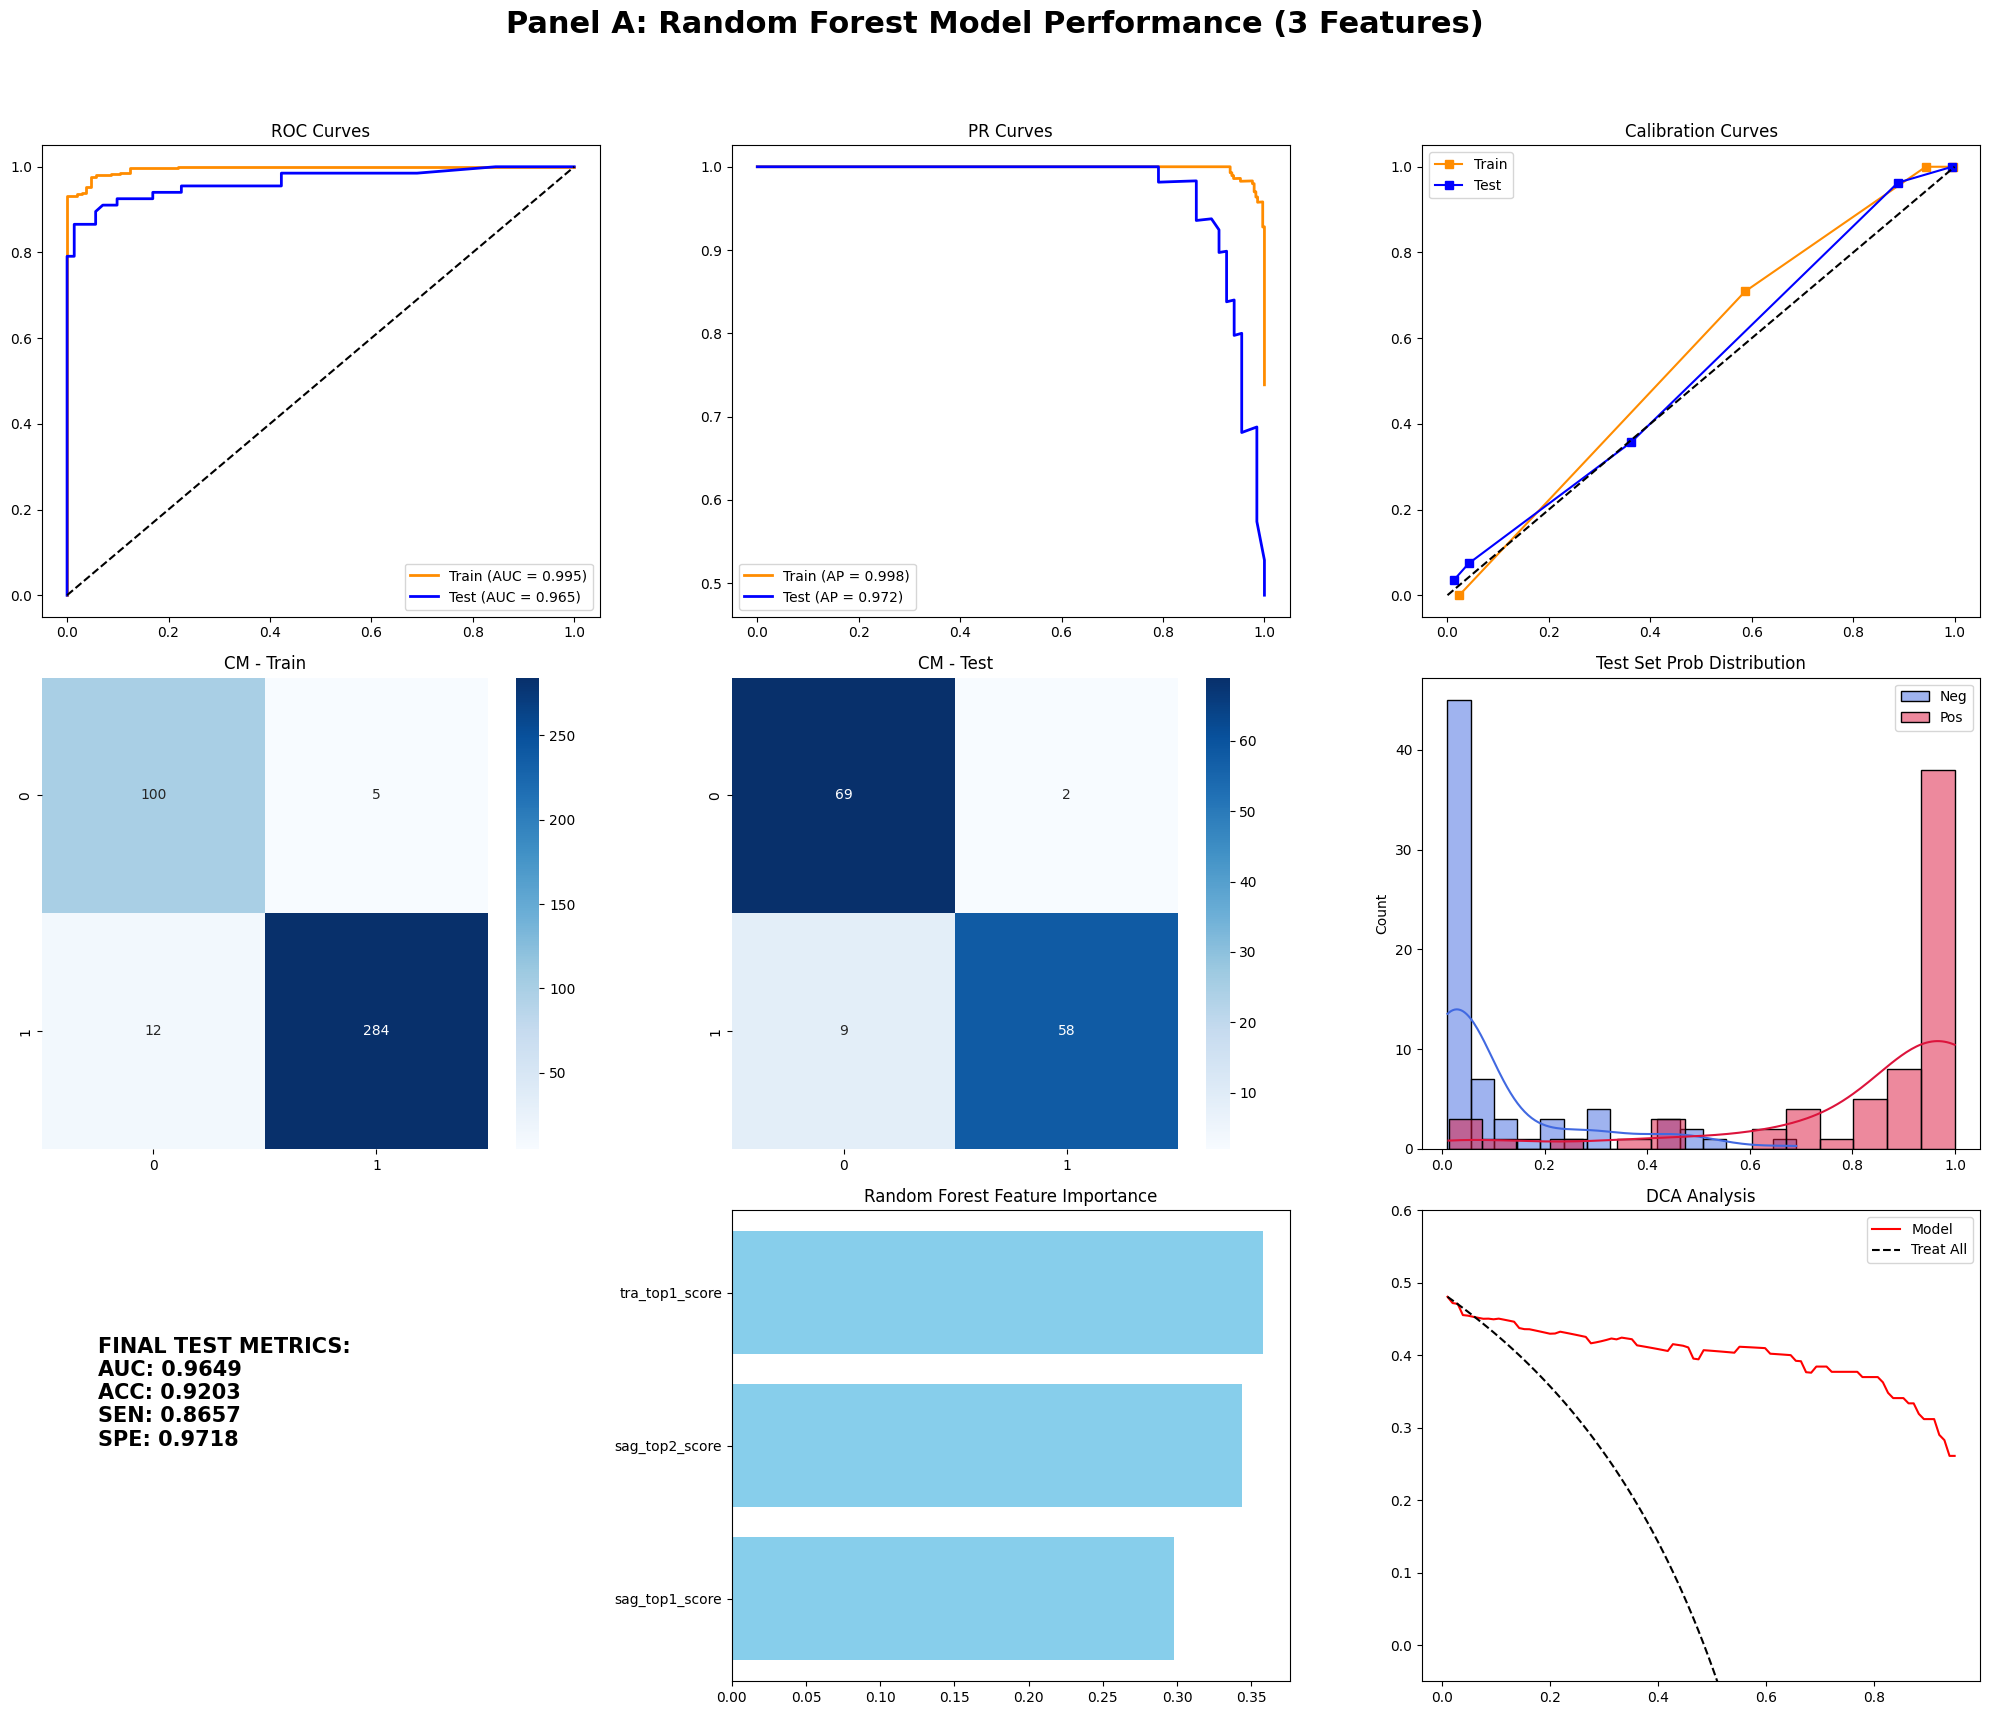

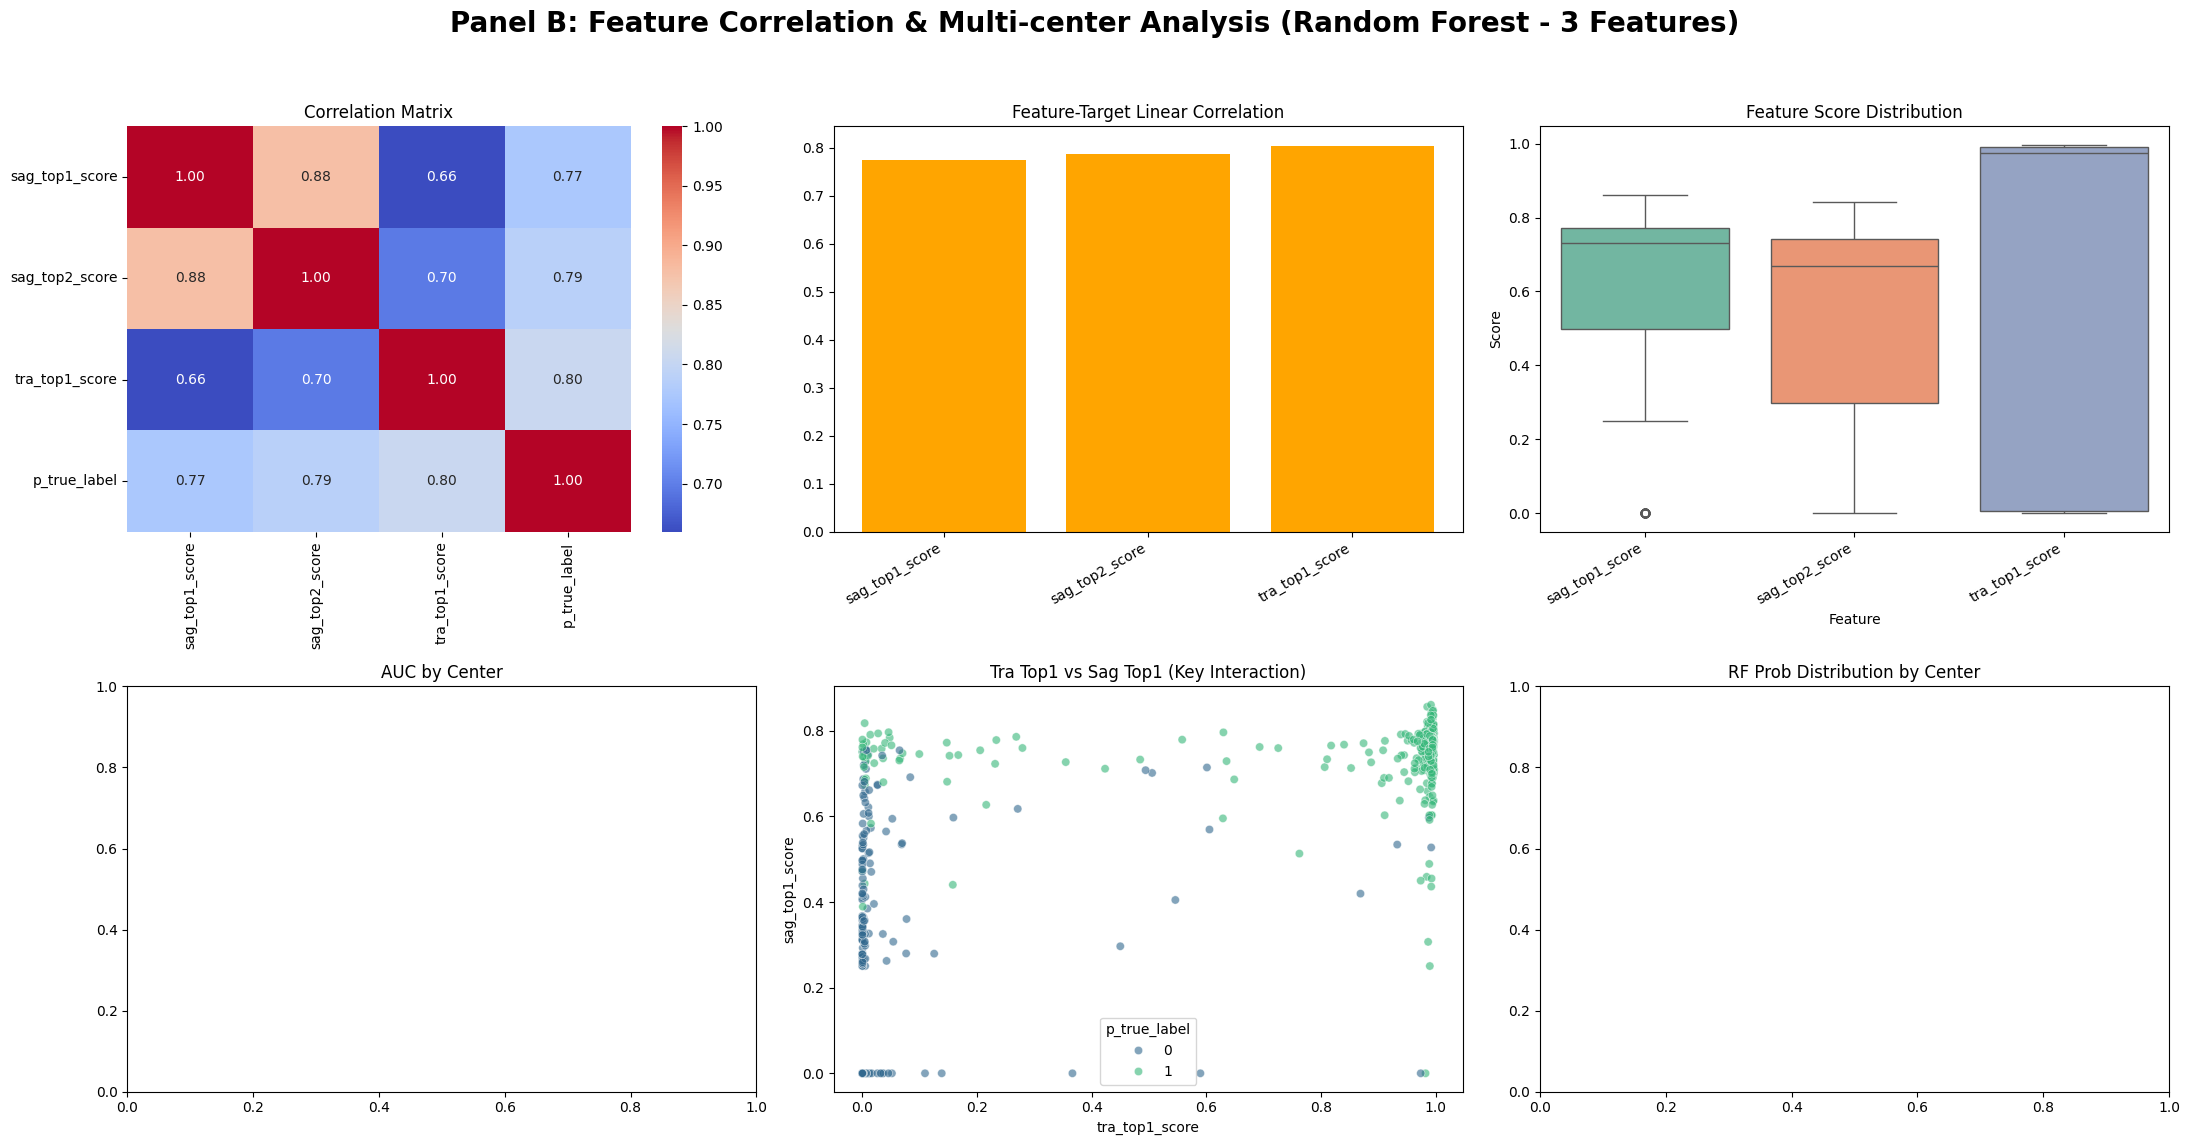


✅ 经过调参的随机森林模型包已成功保存至: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\random_forest_3factors_cv_convnext.pkl

[ 最优随机森林特征重要性 (Gini Importance) ]
------------------------------------------------------------
 ⭐ tra_top1_score     : 0.3581 (35.81%)
 ⭐ sag_top2_score     : 0.3439 (34.39%)
 ⭐ sag_top1_score     : 0.2979 (29.79%)


In [ ]:
# Random Forest
import pandas as pd
import numpy as np
import os
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, 
                             precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from IPython.display import display, Math

def calculate_detailed_metrics(y_true, y_pred, y_pred_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / len(y_true)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_score = roc_auc_score(y_true, y_pred_proba)
    ap_score = average_precision_score(y_true, y_pred_proba)
    return {'accuracy': accuracy, 'sensitivity': sensitivity, 'specificity': specificity, 
            'auc': auc_score, 'ap': ap_score, 'cm': cm}

def plot_comprehensive_performance(y_train, y_train_proba, y_test, y_test_proba, 
                                  train_metrics, test_metrics, feature_columns, rf_model):
    fig, axes = plt.subplots(3, 3, figsize=(20, 18))
    plt.suptitle("Panel A: Random Forest Model Performance (3 Features)", fontsize=22, fontweight='bold')

    # ROC, PR, Calibration
    for y, p, m, l, c in [(y_train, y_train_proba, train_metrics, 'Train', 'darkorange'), 
                          (y_test, y_test_proba, test_metrics, 'Test', 'blue')]:
        fpr, tpr, _ = roc_curve(y, p)
        axes[0,0].plot(fpr, tpr, label=f'{l} (AUC = {m["auc"]:.3f})', lw=2, color=c)
        prec, rec, _ = precision_recall_curve(y, p)
        axes[0,1].plot(rec, prec, label=f'{l} (AP = {m["ap"]:.3f})', lw=2, color=c)
        prob_true, prob_pred = calibration_curve(y, p, n_bins=5, strategy='quantile')
        axes[0,2].plot(prob_pred, prob_true, 's-', label=f'{l}', color=c)

    axes[0,0].set_title("ROC Curves"); axes[0,0].legend(); axes[0,0].plot([0, 1], [0, 1], 'k--')
    axes[0,1].set_title("PR Curves"); axes[0,1].legend()
    axes[0,2].set_title("Calibration Curves"); axes[0,2].legend(); axes[0,2].plot([0, 1], [0, 1], 'k--')

    # Confusion Matrix
    sns.heatmap(train_metrics['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[1,0]); axes[1,0].set_title("CM - Train")
    sns.heatmap(test_metrics['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[1,1]); axes[1,1].set_title("CM - Test")

    # Confidence Distribution
    sns.histplot(x=y_test_proba[y_test==0], bins=15, color='royalblue', label='Neg', ax=axes[1,2], kde=True, alpha=0.5)
    sns.histplot(x=y_test_proba[y_test==1], bins=15, color='crimson', label='Pos', ax=axes[1,2], kde=True, alpha=0.5)
    axes[1,2].set_title("Test Set Prob Distribution"); axes[1,2].legend()

    # Metrics Text
    axes[2,0].axis('off')
    txt = f"FINAL TEST METRICS:\nAUC: {test_metrics['auc']:.4f}\nACC: {test_metrics['accuracy']:.4f}\nSEN: {test_metrics['sensitivity']:.4f}\nSPE: {test_metrics['specificity']:.4f}"
    axes[2,0].text(0.1, 0.5, txt, fontsize=15, fontweight='bold')

    # Importance (Random Forest Feature Importances)
    importance = rf_model.feature_importances_
    sorted_idx = np.argsort(importance)
    axes[2,1].barh(np.array(feature_columns)[sorted_idx], importance[sorted_idx], color='skyblue')
    axes[2,1].set_title("Random Forest Feature Importance")

    # DCA (Decision Curve Analysis)
    def calculate_nb(y_t, y_p, ths):
        n = len(y_t)
        return [(np.sum((y_p >= t) & (y_t == 1)) / n) - (np.sum((y_p >= t) & (y_t == 0)) / n) * (t / (1 - t)) if t < 1.0 else 0 for t in ths]
    ths = np.linspace(0.01, 0.95, 100)
    axes[2,2].plot(ths, calculate_nb(y_test, y_test_proba, ths), 'r-', label='Model')
    axes[2,2].plot(ths, calculate_nb(y_test, np.ones(len(y_test)), ths), 'k--', label='Treat All')
    axes[2,2].set_title("DCA Analysis"); axes[2,2].legend(); axes[2,2].set_ylim(-0.05, 0.6)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def plot_feature_and_center_analysis(df, feature_cols):
    plt.figure(figsize=(22, 12))
    plt.suptitle("Panel B: Feature Correlation & Multi-center Analysis (Random Forest - 3 Features)", fontsize=20, fontweight='bold')
    
    plt.subplot(2, 3, 1)
    sns.heatmap(df[feature_cols + ['p_true_label']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation Matrix")
    
    plt.subplot(2, 3, 2)
    plt.bar(feature_cols, [df[f].corr(df['p_true_label']) for f in feature_cols], color='orange')
    plt.xticks(rotation=30, ha='right')
    plt.title("Feature-Target Linear Correlation")
    
    plt.subplot(2, 3, 3)
    df_melt = df.melt(value_vars=feature_cols, var_name='Feature', value_name='Score')
    sns.boxplot(data=df_melt, x='Feature', y='Score', palette='Set2')
    plt.xticks(rotation=30, ha='right')
    plt.title("Feature Score Distribution")
    
    plt.subplot(2, 3, 4)
    if 'center' in df.columns:
        centers = df['center'].unique()
        valid_centers = [c for c in centers if len(df[df['center']==c]['p_true_label'].unique()) > 1]
        if valid_centers:
            aucs = [roc_auc_score(df[df['center']==c]['p_true_label'], df[df['center']==c]['rf_prob']) for c in valid_centers]
            plt.bar(valid_centers, aucs, color='teal')
    plt.title("AUC by Center")
    
    plt.subplot(2, 3, 5)
    sns.scatterplot(data=df, x='tra_top1_score', y='sag_top1_score', hue='p_true_label', alpha=0.6, palette='viridis')
    plt.title("Tra Top1 vs Sag Top1 (Key Interaction)")
    
    plt.subplot(2, 3, 6)
    if 'center' in df.columns:
        sns.violinplot(data=df, x='center', y='rf_prob', hue='p_true_label', split=True, palette='muted')
    plt.title("RF Prob Distribution by Center")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()


from sklearn.model_selection import GridSearchCV 

csv_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\retinayolo_patient_predictions_detailed_mini_ConvnextYOLO.csv"

if os.path.exists(csv_path):
    print("🚀 正在启动 随机森林 (Random Forest) 5折交叉验证建模流程...")
    df = pd.read_csv(csv_path)
    
    selected_features = ['sag_top1_score', 'sag_top2_score', 'tra_top1_score']
    df[selected_features] = df[selected_features].fillna(0)
    
    train_valid_df = df[df['dataset_type'].isin(['train', 'valid'])].copy()
    test_df = df[df['dataset_type'] == 'test'].copy()
    
    X_train = train_valid_df[selected_features].values
    y_train = train_valid_df['p_true_label'].values
    X_test = test_df[selected_features].values
    y_test = test_df['p_true_label'].values

    print("\n⏳ 正在进行 5 折交叉验证寻找最优超参数，请稍候...")
    
    rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
    
    param_grid = {
        'n_estimators': [50, 100, 200, 300],  
        'max_depth': [3, 5, 7, 10],           
        'min_samples_split': [2, 5, 10],      
        'min_samples_leaf': [1, 2, 4]         
    }
    
    grid_search = GridSearchCV(
        estimator=rf_base, 
        param_grid=param_grid, 
        cv=5, 
        scoring='roc_auc', 
        n_jobs=-1, 
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    rf_model = grid_search.best_estimator_
    
    print("\n" + "🌟"*30)
    print("🏆 交叉验证完毕！机器找到的最佳参数组合如下 (写论文时可以直接用):")
    for param, value in grid_search.best_params_.items():
        print(f"   - {param}: {value}")
    print(f"   - 对应的内部交叉验证平均 AUC: {grid_search.best_score_:.4f}")
    print("🌟"*30 + "\n")

    y_train_proba = rf_model.predict_proba(X_train)[:, 1]
    y_test_proba = rf_model.predict_proba(X_test)[:, 1]
    y_test_pred = rf_model.predict(X_test)
    
    train_metrics = calculate_detailed_metrics(y_train, (y_train_proba > 0.5).astype(int), y_train_proba)
    test_metrics = calculate_detailed_metrics(y_test, y_test_pred, y_test_proba)
    
    train_valid_df.loc[:, 'rf_prob'] = y_train_proba
    test_df.loc[:, 'rf_prob'] = y_test_proba
    combined_df = pd.concat([train_valid_df, test_df], ignore_index=True)

    plot_comprehensive_performance(y_train, y_train_proba, y_test, y_test_proba, 
                                  train_metrics, test_metrics, selected_features, rf_model)
    plot_feature_and_center_analysis(combined_df, selected_features)

    output_dir = os.path.dirname(csv_path)
    package_path = os.path.join(output_dir, 'random_forest_3factors_cv_convnext.pkl')
    package = {
        'model': rf_model,
        'features': selected_features,
        'best_params': grid_search.best_params_,  
        'model_desc': 'Random Forest Classifier (3 Features, 5-Fold CV Tuned)'
    }
    joblib.dump(package, package_path)
    print(f"\n✅ 经过调参的随机森林模型包已成功保存至: {package_path}")

    print("\n" + "="*60)
    print("[ 最优随机森林特征重要性 (Gini Importance) ]")
    print("-" * 60)
    importances = rf_model.feature_importances_
    feat_imp = pd.DataFrame({'Feature': selected_features, 'Importance': importances})
    feat_imp = feat_imp.sort_values('Importance', ascending=False)
    for idx, row in feat_imp.iterrows():
        print(f" ⭐ {row['Feature']:<18} : {row['Importance']:.4f} ({row['Importance']:.2%})")
    print("="*60)

else:
    print("❌ 错误：未找到指定的 CSV 数据文件，请检查路径。")

🚀 正在启动 XGBoost 5折交叉验证建模流程...

⏳ 正在进行 5 折交叉验证寻找最优超参数，请稍候...
Fitting 5 folds for each of 144 candidates, totalling 720 fits

🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟
🏆 交叉验证完毕！机器找到的最佳 XGBoost 参数组合如下:
   - colsample_bytree: 0.8
   - learning_rate: 0.05
   - max_depth: 2
   - n_estimators: 200
   - subsample: 1.0
   - 对应的内部交叉验证平均 AUC: 0.9929
🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟



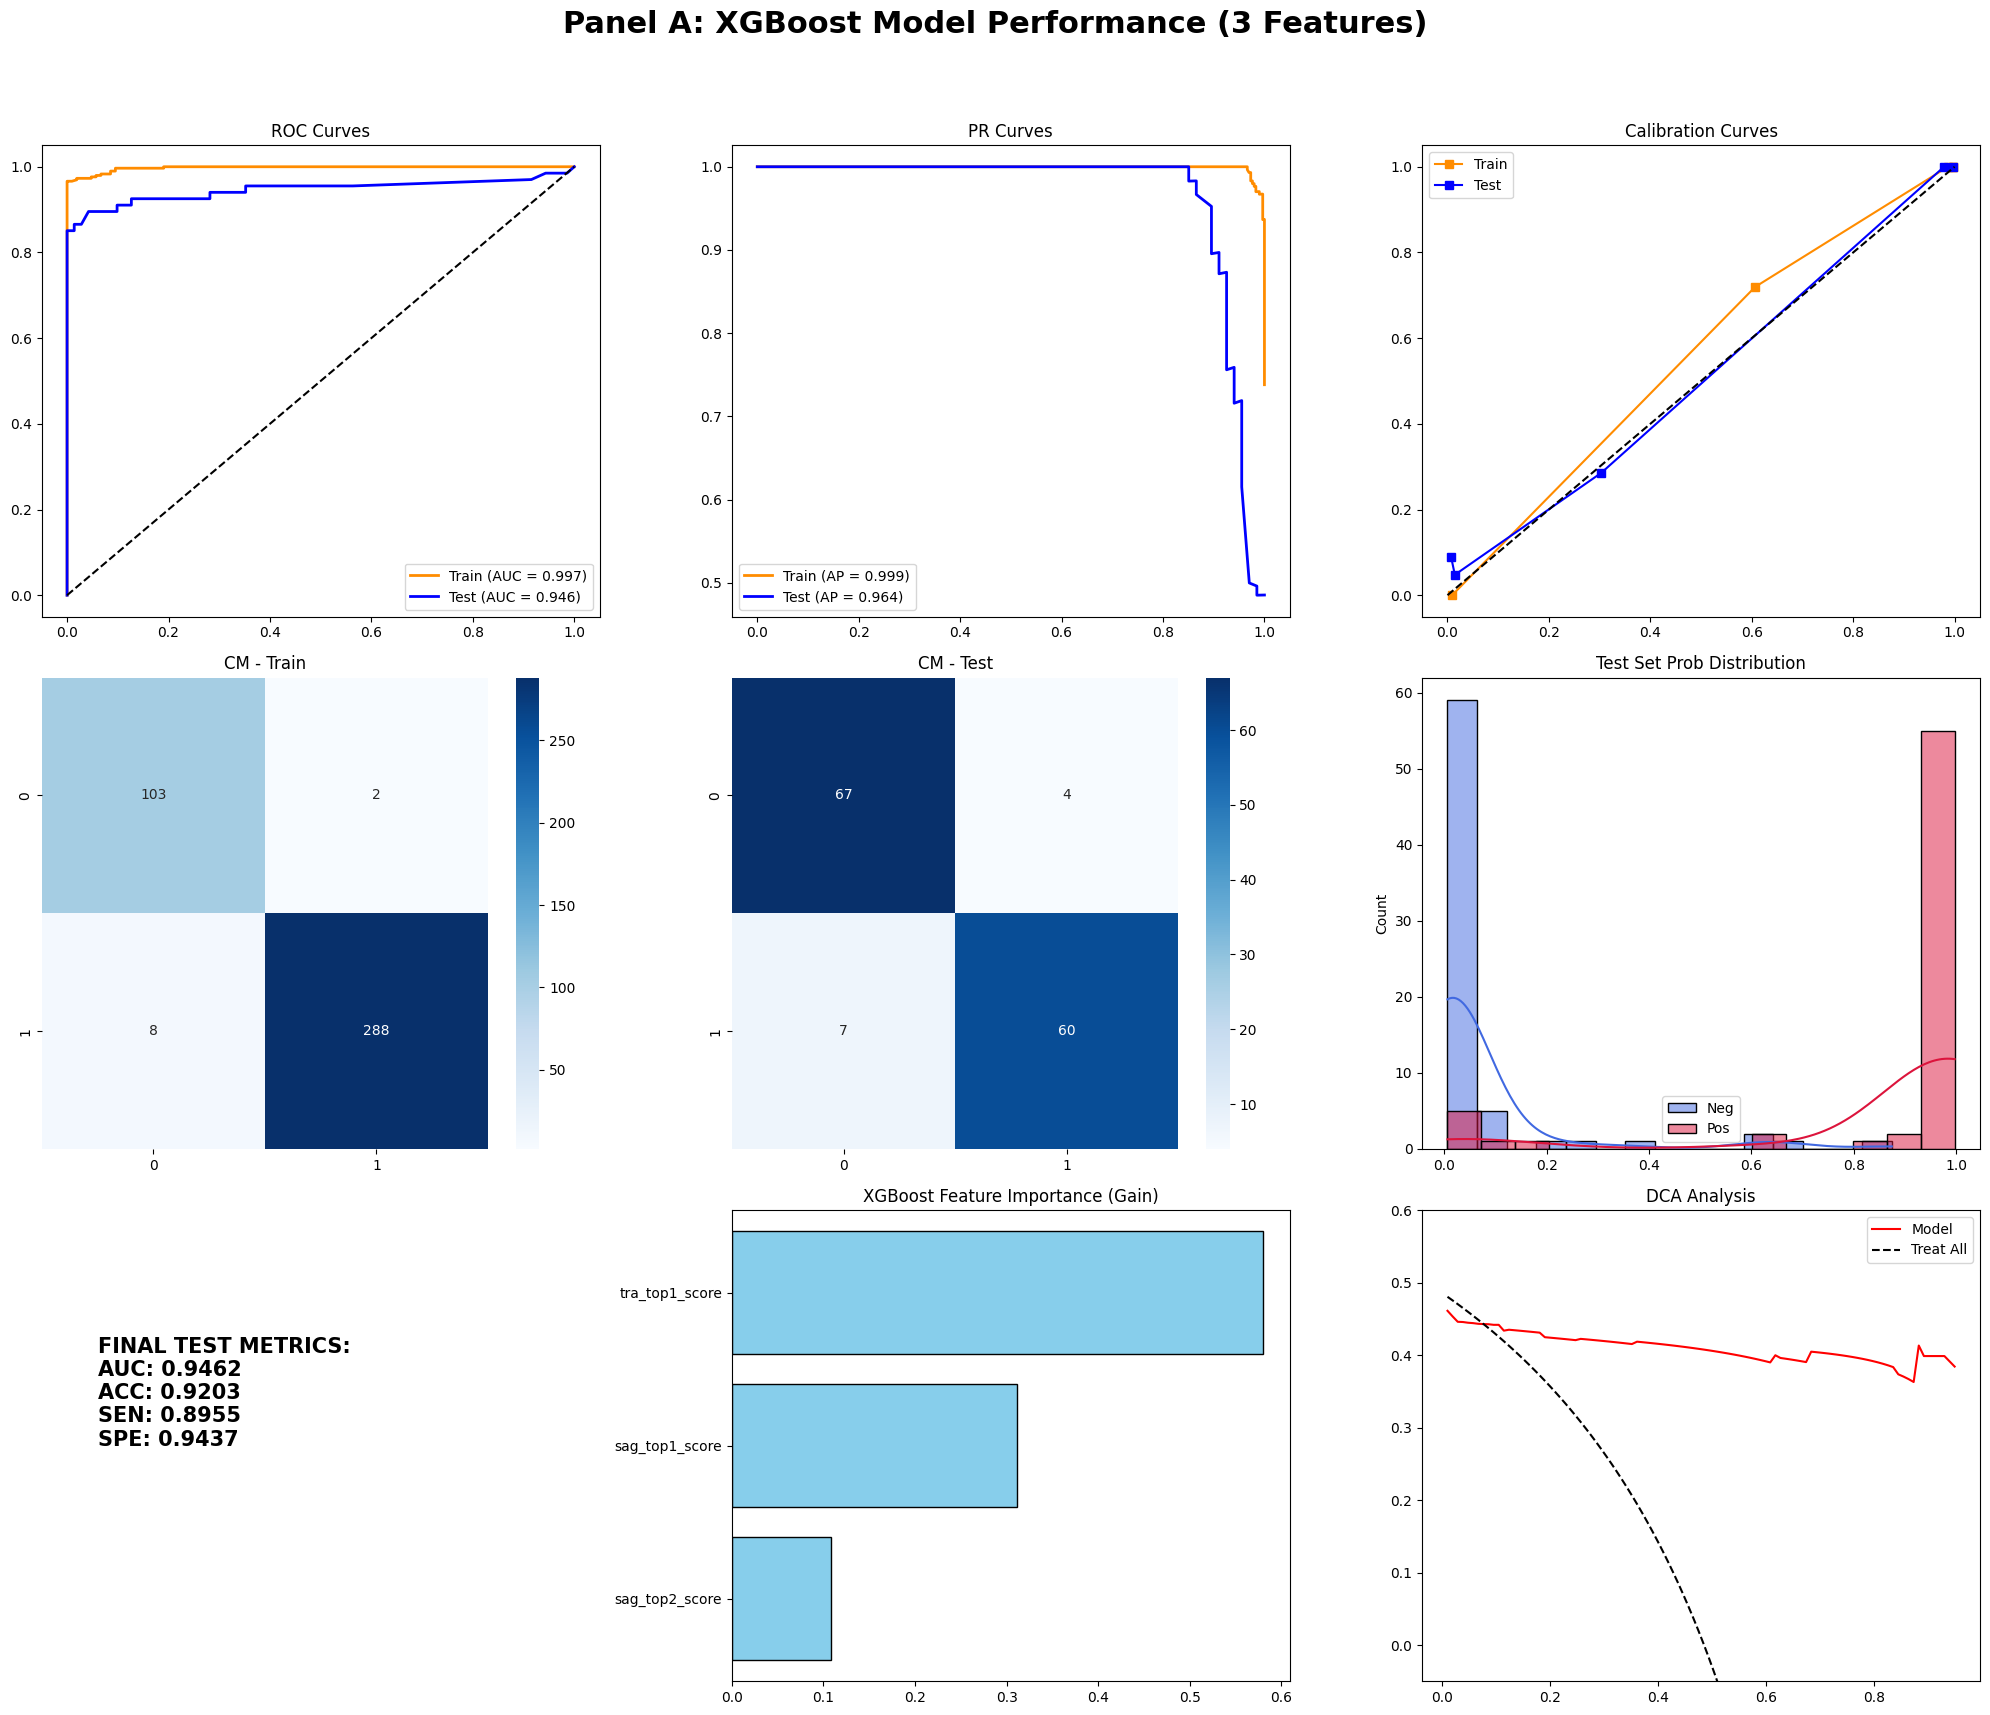

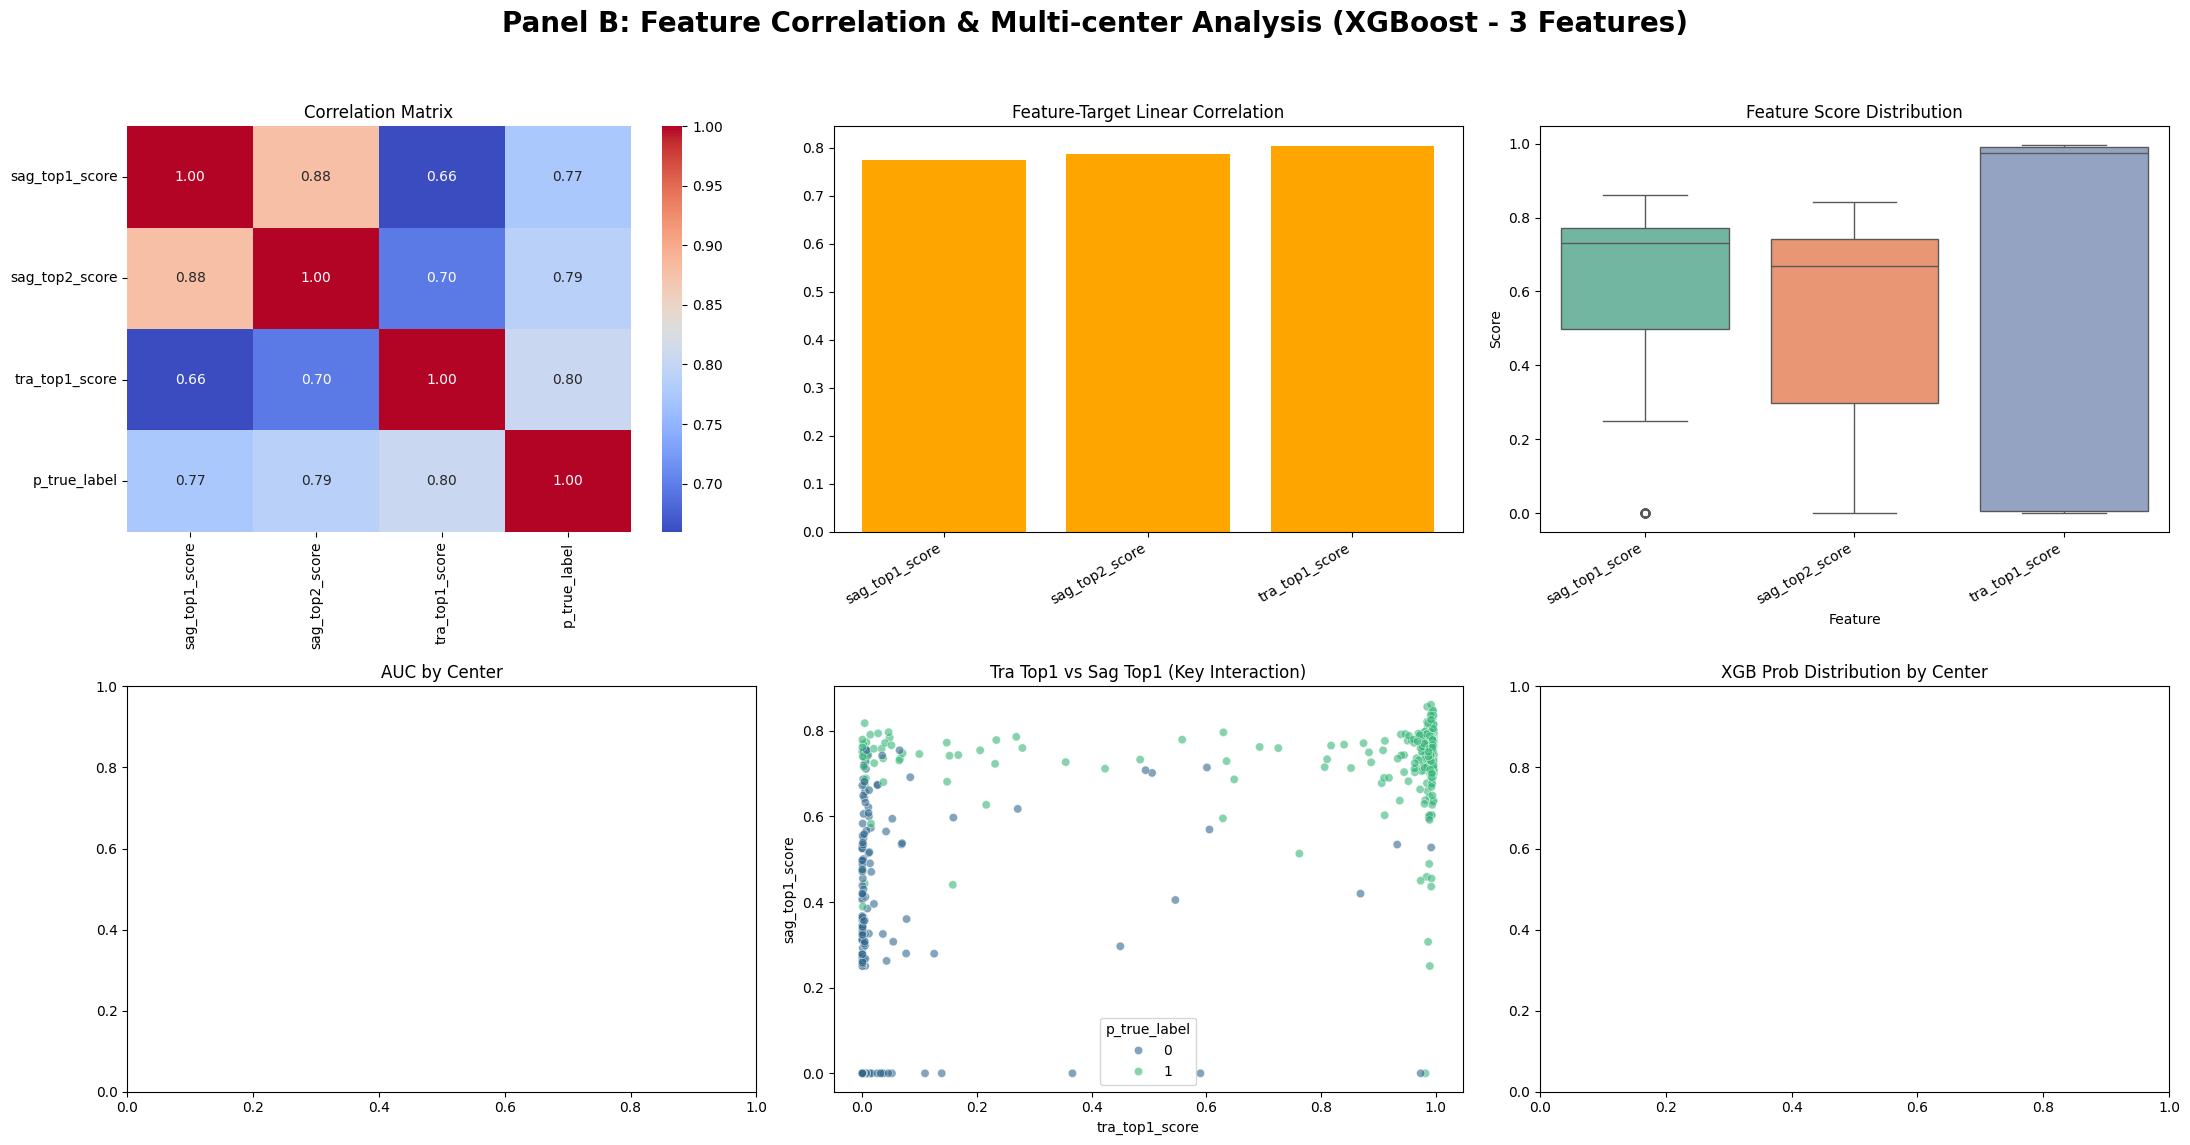


✅ 经过调参的 XGBoost 模型包已成功保存至: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\xgboost_3factors_cv_convnext.pkl

[ 最优 XGBoost 特征重要性 (Gain) ]
注：XGBoost 的重要性(Gain)代表了该特征在所有树中分裂时带来的平均信息增益。
------------------------------------------------------------
 ⭐ tra_top1_score     : 0.5802 (58.02%)
 ⭐ sag_top1_score     : 0.3117 (31.17%)
 ⭐ sag_top2_score     : 0.1081 (10.81%)


In [ ]:
# XGBoost
import pandas as pd
import numpy as np
import os
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, 
                             precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from IPython.display import display, Math

def calculate_detailed_metrics(y_true, y_pred, y_pred_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / len(y_true)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_score = roc_auc_score(y_true, y_pred_proba)
    ap_score = average_precision_score(y_true, y_pred_proba)
    return {'accuracy': accuracy, 'sensitivity': sensitivity, 'specificity': specificity, 
            'auc': auc_score, 'ap': ap_score, 'cm': cm}

def plot_comprehensive_performance(y_train, y_train_proba, y_test, y_test_proba, 
                                  train_metrics, test_metrics, feature_columns, xgb_model):
    fig, axes = plt.subplots(3, 3, figsize=(20, 18))
    plt.suptitle("Panel A: XGBoost Model Performance (3 Features)", fontsize=22, fontweight='bold')

    # ROC, PR, Calibration
    for y, p, m, l, c in [(y_train, y_train_proba, train_metrics, 'Train', 'darkorange'), 
                          (y_test, y_test_proba, test_metrics, 'Test', 'blue')]:
        fpr, tpr, _ = roc_curve(y, p)
        axes[0,0].plot(fpr, tpr, label=f'{l} (AUC = {m["auc"]:.3f})', lw=2, color=c)
        prec, rec, _ = precision_recall_curve(y, p)
        axes[0,1].plot(rec, prec, label=f'{l} (AP = {m["ap"]:.3f})', lw=2, color=c)
        prob_true, prob_pred = calibration_curve(y, p, n_bins=5, strategy='quantile')
        axes[0,2].plot(prob_pred, prob_true, 's-', label=f'{l}', color=c)

    axes[0,0].set_title("ROC Curves"); axes[0,0].legend(); axes[0,0].plot([0, 1], [0, 1], 'k--')
    axes[0,1].set_title("PR Curves"); axes[0,1].legend()
    axes[0,2].set_title("Calibration Curves"); axes[0,2].legend(); axes[0,2].plot([0, 1], [0, 1], 'k--')

    # Confusion Matrix
    sns.heatmap(train_metrics['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[1,0]); axes[1,0].set_title("CM - Train")
    sns.heatmap(test_metrics['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[1,1]); axes[1,1].set_title("CM - Test")

    # Confidence Distribution
    sns.histplot(x=y_test_proba[y_test==0], bins=15, color='royalblue', label='Neg', ax=axes[1,2], kde=True, alpha=0.5)
    sns.histplot(x=y_test_proba[y_test==1], bins=15, color='crimson', label='Pos', ax=axes[1,2], kde=True, alpha=0.5)
    axes[1,2].set_title("Test Set Prob Distribution"); axes[1,2].legend()

    # Metrics Text
    axes[2,0].axis('off')
    txt = f"FINAL TEST METRICS:\nAUC: {test_metrics['auc']:.4f}\nACC: {test_metrics['accuracy']:.4f}\nSEN: {test_metrics['sensitivity']:.4f}\nSPE: {test_metrics['specificity']:.4f}"
    axes[2,0].text(0.1, 0.5, txt, fontsize=15, fontweight='bold')

    # Importance (XGBoost Feature Importances)
    importance = xgb_model.feature_importances_
    sorted_idx = np.argsort(importance)
    axes[2,1].barh(np.array(feature_columns)[sorted_idx], importance[sorted_idx], color='skyblue', edgecolor='black')
    axes[2,1].set_title("XGBoost Feature Importance (Gain)")

    # DCA (Decision Curve Analysis)
    def calculate_nb(y_t, y_p, ths):
        n = len(y_t)
        return [(np.sum((y_p >= t) & (y_t == 1)) / n) - (np.sum((y_p >= t) & (y_t == 0)) / n) * (t / (1 - t)) if t < 1.0 else 0 for t in ths]
    ths = np.linspace(0.01, 0.95, 100)
    axes[2,2].plot(ths, calculate_nb(y_test, y_test_proba, ths), 'r-', label='Model')
    axes[2,2].plot(ths, calculate_nb(y_test, np.ones(len(y_test)), ths), 'k--', label='Treat All')
    axes[2,2].set_title("DCA Analysis"); axes[2,2].legend(); axes[2,2].set_ylim(-0.05, 0.6)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def plot_feature_and_center_analysis(df, feature_cols):
    plt.figure(figsize=(22, 12))
    plt.suptitle("Panel B: Feature Correlation & Multi-center Analysis (XGBoost - 3 Features)", fontsize=20, fontweight='bold')
    
    plt.subplot(2, 3, 1)
    sns.heatmap(df[feature_cols + ['p_true_label']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation Matrix")
    
    plt.subplot(2, 3, 2)
    plt.bar(feature_cols, [df[f].corr(df['p_true_label']) for f in feature_cols], color='orange')
    plt.xticks(rotation=30, ha='right')
    plt.title("Feature-Target Linear Correlation")
    
    plt.subplot(2, 3, 3)
    df_melt = df.melt(value_vars=feature_cols, var_name='Feature', value_name='Score')
    sns.boxplot(data=df_melt, x='Feature', y='Score', palette='Set2')
    plt.xticks(rotation=30, ha='right')
    plt.title("Feature Score Distribution")
    
    plt.subplot(2, 3, 4)
    if 'center' in df.columns:
        centers = df['center'].unique()
        valid_centers = [c for c in centers if len(df[df['center']==c]['p_true_label'].unique()) > 1]
        if valid_centers:
            aucs = [roc_auc_score(df[df['center']==c]['p_true_label'], df[df['center']==c]['xgb_prob']) for c in valid_centers]
            plt.bar(valid_centers, aucs, color='teal')
    plt.title("AUC by Center")
    
    plt.subplot(2, 3, 5)
    sns.scatterplot(data=df, x='tra_top1_score', y='sag_top1_score', hue='p_true_label', alpha=0.6, palette='viridis')
    plt.title("Tra Top1 vs Sag Top1 (Key Interaction)")
    
    plt.subplot(2, 3, 6)
    if 'center' in df.columns:
        sns.violinplot(data=df, x='center', y='xgb_prob', hue='p_true_label', split=True, palette='muted')
    plt.title("XGB Prob Distribution by Center")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

from sklearn.model_selection import GridSearchCV 

csv_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\retinayolo_patient_predictions_detailed_mini_ConvnextYOLO.csv"

if os.path.exists(csv_path):
    print("🚀 正在启动 XGBoost 5折交叉验证建模流程...")
    df = pd.read_csv(csv_path)
    
    selected_features = [
        'sag_top1_score', 'sag_top2_score', 'tra_top1_score'
    ]
    df[selected_features] = df[selected_features].fillna(0)
    
    train_valid_df = df[df['dataset_type'].isin(['train', 'valid'])].copy()
    test_df = df[df['dataset_type'] == 'test'].copy()
    
    X_train = train_valid_df[selected_features].values
    y_train = train_valid_df['p_true_label'].values
    X_test = test_df[selected_features].values
    y_test = test_df['p_true_label'].values

    pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

    print("\n⏳ 正在进行 5 折交叉验证寻找最优超参数，请稍候...")
    
    xgb_base = XGBClassifier(
        scale_pos_weight=pos_weight, 
        random_state=42,             
        eval_metric='logloss',    
        use_label_encoder=False      
    )
    
    param_grid = {
        'n_estimators': [50, 100, 200],      
        'max_depth': [2, 3, 4, 5],            
        'learning_rate': [0.01, 0.05, 0.1],   
        'subsample': [0.8, 1.0],            
        'colsample_bytree': [0.8, 1.0]      
    }
    
    grid_search = GridSearchCV(
        estimator=xgb_base, 
        param_grid=param_grid, 
        cv=5, 
        scoring='roc_auc', 
        n_jobs=-1,          
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    xgb_model = grid_search.best_estimator_
    
    print("\n" + "🌟"*30)
    print("🏆 交叉验证完毕！机器找到的最佳 XGBoost 参数组合如下:")
    for param, value in grid_search.best_params_.items():
        print(f"   - {param}: {value}")
    print(f"   - 对应的内部交叉验证平均 AUC: {grid_search.best_score_:.4f}")
    print("🌟"*30 + "\n")

    y_train_proba = xgb_model.predict_proba(X_train)[:, 1]
    y_test_proba = xgb_model.predict_proba(X_test)[:, 1]
    y_test_pred = xgb_model.predict(X_test)
    
    train_metrics = calculate_detailed_metrics(y_train, (y_train_proba > 0.5).astype(int), y_train_proba)
    test_metrics = calculate_detailed_metrics(y_test, y_test_pred, y_test_proba)
    
    train_valid_df.loc[:, 'xgb_prob'] = y_train_proba
    test_df.loc[:, 'xgb_prob'] = y_test_proba
    combined_df = pd.concat([train_valid_df, test_df], ignore_index=True)

    plot_comprehensive_performance(y_train, y_train_proba, y_test, y_test_proba, 
                                  train_metrics, test_metrics, selected_features, xgb_model)
    plot_feature_and_center_analysis(combined_df, selected_features)

    output_dir = os.path.dirname(csv_path)
    package_path = os.path.join(output_dir, 'xgboost_3factors_cv_convnext.pkl')
    package = {
        'model': xgb_model,
        'features': selected_features,
        'best_params': grid_search.best_params_,
        'model_desc': 'XGBoost Classifier (3 Features, 5-Fold CV Tuned)'
    }
    joblib.dump(package, package_path)
    print(f"\n✅ 经过调参的 XGBoost 模型包已成功保存至: {package_path}")

    print("\n" + "="*60)
    print("[ 最优 XGBoost 特征重要性 (Gain) ]")
    print("注：XGBoost 的重要性(Gain)代表了该特征在所有树中分裂时带来的平均信息增益。")
    print("-" * 60)
    
    importances = xgb_model.feature_importances_
    feat_imp = pd.DataFrame({'Feature': selected_features, 'Importance': importances})
    feat_imp = feat_imp.sort_values('Importance', ascending=False)
    
    for idx, row in feat_imp.iterrows():
        print(f" ⭐ {row['Feature']:<18} : {row['Importance']:.4f} ({row['Importance']:.2%})")
    print("="*60)

else:
    print("❌ 错误：未找到指定的 CSV 数据文件，请检查路径。")

🚀 正在启动 支持向量机 (SVM) 5折交叉验证调参流程...

⏳ 正在进行 5 折交叉验证寻找最优超参数，请稍候...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟
🏆 交叉验证完毕！机器找到的最佳 SVM 参数组合如下:
   - C: 0.01
   - gamma: 1
   - kernel: rbf
   - 对应的内部交叉验证平均 AUC: 0.9936
🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟



AttributeError: coef_ is only available when using a linear kernel

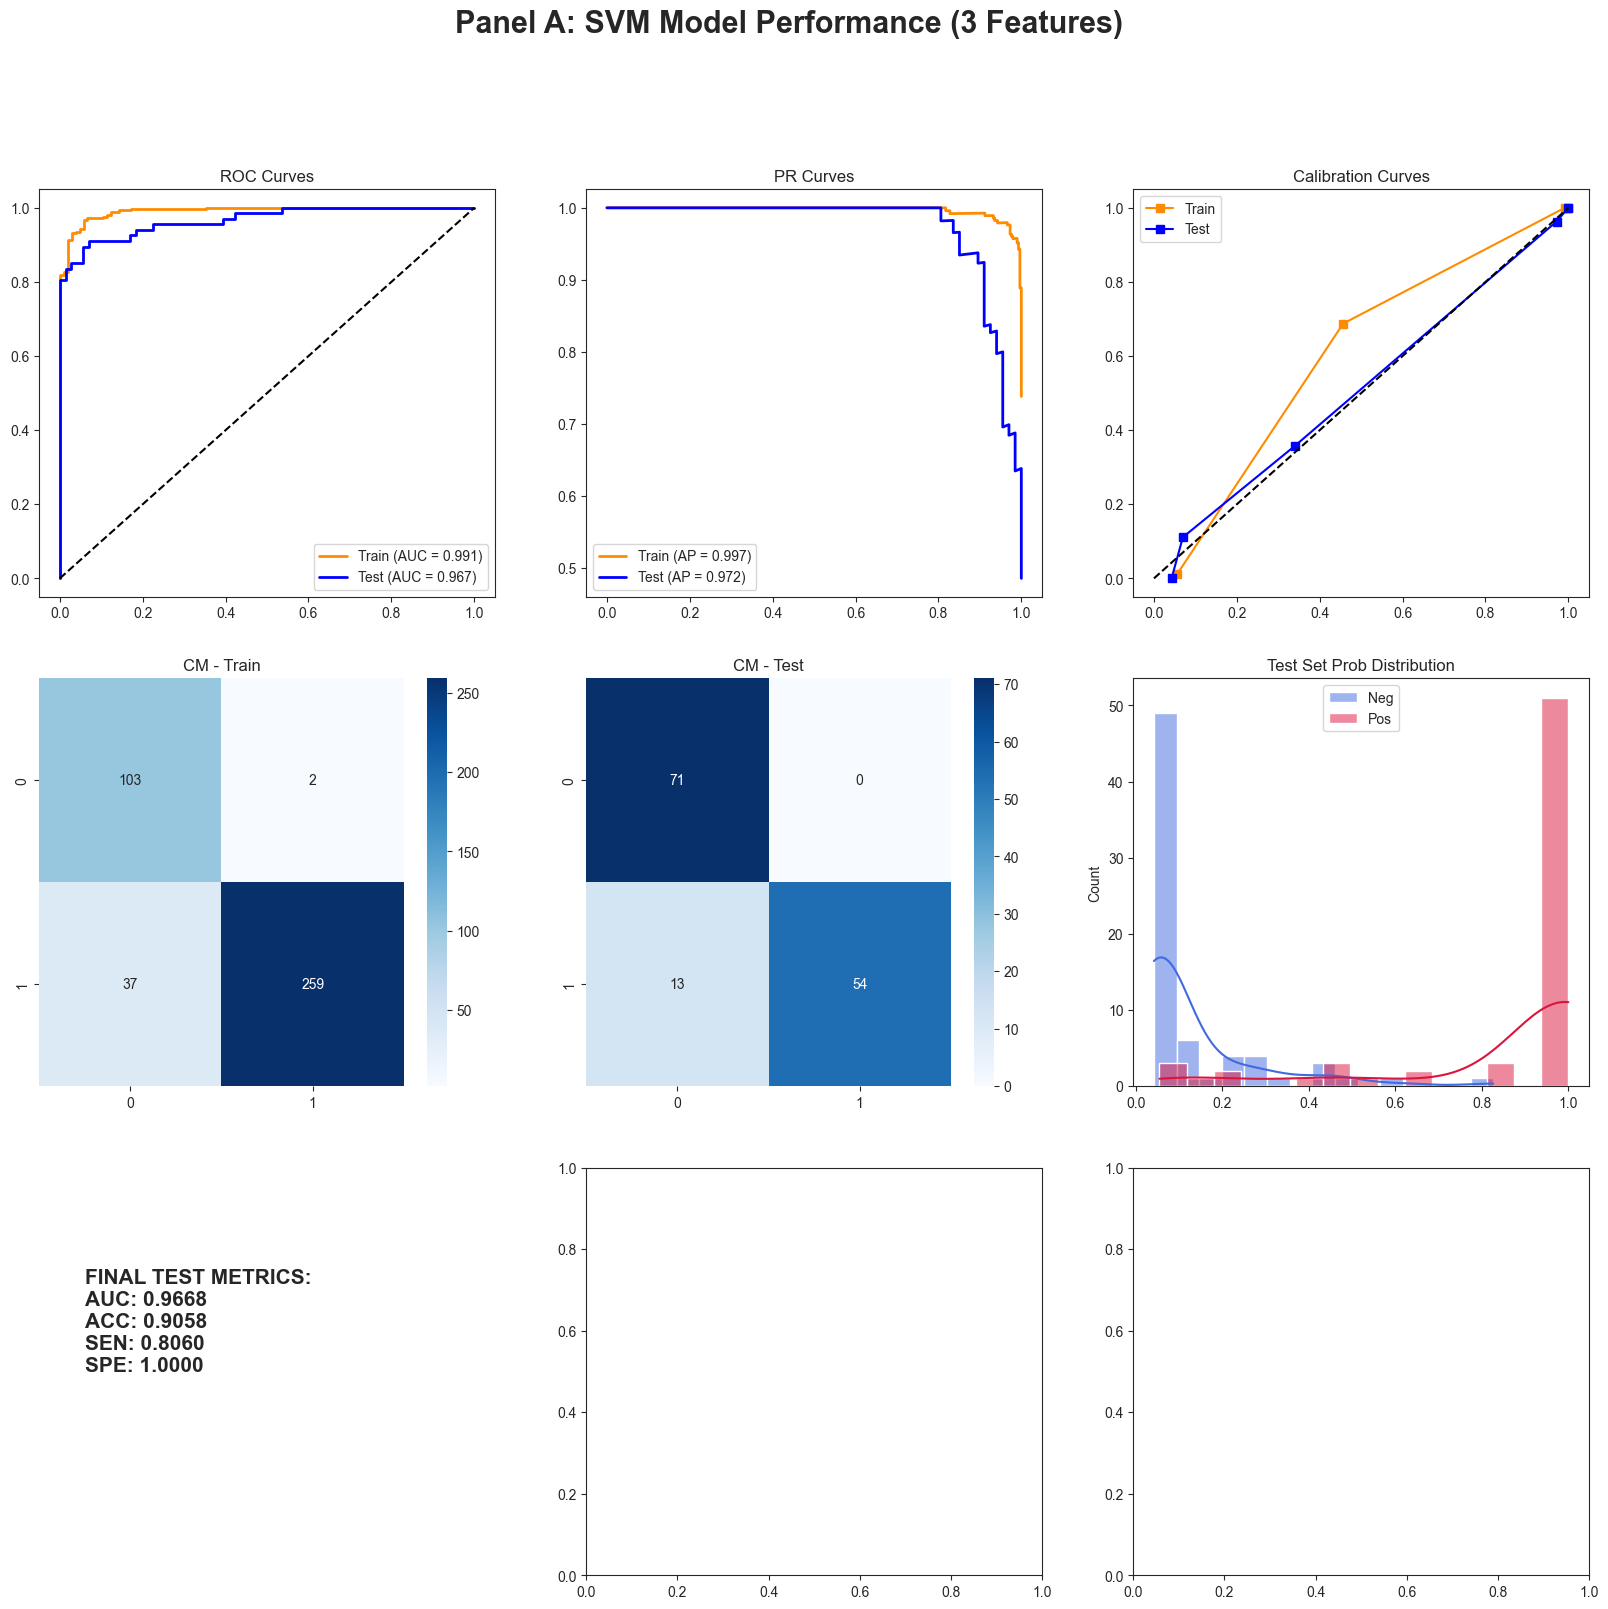

In [ ]:
# SVM
import pandas as pd
import numpy as np
import os
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, 
                             precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from IPython.display import display

def calculate_detailed_metrics(y_true, y_pred, y_pred_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / len(y_true)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_score = roc_auc_score(y_true, y_pred_proba)
    ap_score = average_precision_score(y_true, y_pred_proba)
    return {'accuracy': accuracy, 'sensitivity': sensitivity, 'specificity': specificity, 
            'auc': auc_score, 'ap': ap_score, 'cm': cm}

def plot_comprehensive_performance(y_train, y_train_proba, y_test, y_test_proba, 
                                  train_metrics, test_metrics, feature_columns, svm_pipeline):
    fig, axes = plt.subplots(3, 3, figsize=(20, 18))
    plt.suptitle("Panel A: SVM Model Performance (3 Features)", fontsize=22, fontweight='bold')

    # ROC, PR, Calibration
    for y, p, m, l, c in [(y_train, y_train_proba, train_metrics, 'Train', 'darkorange'), 
                          (y_test, y_test_proba, test_metrics, 'Test', 'blue')]:
        fpr, tpr, _ = roc_curve(y, p)
        axes[0,0].plot(fpr, tpr, label=f'{l} (AUC = {m["auc"]:.3f})', lw=2, color=c)
        prec, rec, _ = precision_recall_curve(y, p)
        axes[0,1].plot(rec, prec, label=f'{l} (AP = {m["ap"]:.3f})', lw=2, color=c)
        prob_true, prob_pred = calibration_curve(y, p, n_bins=5, strategy='quantile')
        axes[0,2].plot(prob_pred, prob_true, 's-', label=f'{l}', color=c)

    axes[0,0].set_title("ROC Curves"); axes[0,0].legend(); axes[0,0].plot([0, 1], [0, 1], 'k--')
    axes[0,1].set_title("PR Curves"); axes[0,1].legend()
    axes[0,2].set_title("Calibration Curves"); axes[0,2].legend(); axes[0,2].plot([0, 1], [0, 1], 'k--')

    # Confusion Matrix
    sns.heatmap(train_metrics['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[1,0]); axes[1,0].set_title("CM - Train")
    sns.heatmap(test_metrics['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[1,1]); axes[1,1].set_title("CM - Test")

    # Confidence Distribution
    sns.histplot(x=y_test_proba[y_test==0], bins=15, color='royalblue', label='Neg', ax=axes[1,2], kde=True, alpha=0.5)
    sns.histplot(x=y_test_proba[y_test==1], bins=15, color='crimson', label='Pos', ax=axes[1,2], kde=True, alpha=0.5)
    axes[1,2].set_title("Test Set Prob Distribution"); axes[1,2].legend()

    # Metrics Text
    axes[2,0].axis('off')
    txt = f"FINAL TEST METRICS:\nAUC: {test_metrics['auc']:.4f}\nACC: {test_metrics['accuracy']:.4f}\nSEN: {test_metrics['sensitivity']:.4f}\nSPE: {test_metrics['specificity']:.4f}"
    axes[2,0].text(0.1, 0.5, txt, fontsize=15, fontweight='bold')

    # Importance (SVM Linear Coefficients Absolute Value)
    svc_model = svm_pipeline.named_steps['svc']
    importance = np.abs(svc_model.coef_[0])
    sorted_idx = np.argsort(importance)
    axes[2,1].barh(np.array(feature_columns)[sorted_idx], importance[sorted_idx], color='skyblue', edgecolor='black')
    axes[2,1].set_title("SVM Feature Importance (Abs Linear Coef)")

    # DCA (Decision Curve Analysis)
    def calculate_nb(y_t, y_p, ths):
        n = len(y_t)
        return [(np.sum((y_p >= t) & (y_t == 1)) / n) - (np.sum((y_p >= t) & (y_t == 0)) / n) * (t / (1 - t)) if t < 1.0 else 0 for t in ths]
    ths = np.linspace(0.01, 0.95, 100)
    axes[2,2].plot(ths, calculate_nb(y_test, y_test_proba, ths), 'r-', label='Model')
    axes[2,2].plot(ths, calculate_nb(y_test, np.ones(len(y_test)), ths), 'k--', label='Treat All')
    axes[2,2].set_title("DCA Analysis"); axes[2,2].legend(); axes[2,2].set_ylim(-0.05, 0.6)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def plot_feature_and_center_analysis(df, feature_cols):
    plt.figure(figsize=(22, 12))
    plt.suptitle("Panel B: Feature Correlation & Multi-center Analysis (SVM - 3 Features)", fontsize=20, fontweight='bold')
    
    plt.subplot(2, 3, 1)
    sns.heatmap(df[feature_cols + ['p_true_label']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation Matrix")
    
    plt.subplot(2, 3, 2)
    plt.bar(feature_cols, [df[f].corr(df['p_true_label']) for f in feature_cols], color='orange')
    plt.xticks(rotation=30, ha='right')
    plt.title("Feature-Target Linear Correlation")
    
    plt.subplot(2, 3, 3)
    df_melt = df.melt(value_vars=feature_cols, var_name='Feature', value_name='Score')
    sns.boxplot(data=df_melt, x='Feature', y='Score', palette='Set2')
    plt.xticks(rotation=30, ha='right')
    plt.title("Feature Score Distribution")
    
    plt.subplot(2, 3, 4)
    if 'center' in df.columns:
        centers = df['center'].unique()
        valid_centers = [c for c in centers if len(df[df['center']==c]['p_true_label'].unique()) > 1]
        if valid_centers:
            aucs = [roc_auc_score(df[df['center']==c]['p_true_label'], df[df['center']==c]['svm_prob']) for c in valid_centers]
            plt.bar(valid_centers, aucs, color='teal')
    plt.title("AUC by Center")
    
    plt.subplot(2, 3, 5)
    sns.scatterplot(data=df, x='tra_top1_score', y='sag_top1_score', hue='p_true_label', alpha=0.6, palette='viridis')
    plt.title("Tra Top1 vs Sag Top1 (Key Interaction)")
    
    plt.subplot(2, 3, 6)
    if 'center' in df.columns:
        sns.violinplot(data=df, x='center', y='svm_prob', hue='p_true_label', split=True, palette='muted')
    plt.title("SVM Prob Distribution by Center")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

from sklearn.model_selection import GridSearchCV 

csv_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\retinayolo_patient_predictions_detailed_mini_ConvnextYOLO.csv"

if os.path.exists(csv_path):
    print("🚀 正在启动 支持向量机 (SVM) 5折交叉验证调参流程...")
    df = pd.read_csv(csv_path)
    
    selected_features = [
        'sag_top1_score', 'sag_top2_score', 'tra_top1_score'
    ]
    df[selected_features] = df[selected_features].fillna(0)
    
    train_valid_df = df[df['dataset_type'].isin(['train', 'valid'])].copy()
    test_df = df[df['dataset_type'] == 'test'].copy()
    
    X_train = train_valid_df[selected_features].values
    y_train = train_valid_df['p_true_label'].values
    X_test = test_df[selected_features].values
    y_test = test_df['p_true_label'].values

    print("\n⏳ 正在进行 5 折交叉验证寻找最优超参数，请稍候...")

    svm_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(
            probability=True,        
            class_weight='balanced', 
            random_state=42
        ))
    ])

    param_grid = {
        'svc__kernel': ['linear', 'rbf'],
        'svc__C': [0.01, 0.1, 1, 10, 50],
        'svc__gamma': ['scale', 'auto', 0.1, 1]
    }

    grid_search = GridSearchCV(
        estimator=svm_pipeline,
        param_grid=param_grid,
        cv=5,
        scoring='roc_auc', 
        n_jobs=-1,         
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    best_svm_pipeline = grid_search.best_estimator_

    print("\n" + "🌟"*30)
    print("🏆 交叉验证完毕！机器找到的最佳 SVM 参数组合如下:")
    for param, value in grid_search.best_params_.items():
        # 把打印出来的 'svc__C' 变回易读的 'C'
        clean_param_name = param.replace('svc__', '')
        print(f"   - {clean_param_name}: {value}")
    print(f"   - 对应的内部交叉验证平均 AUC: {grid_search.best_score_:.4f}")
    print("🌟"*30 + "\n")

    y_train_proba = best_svm_pipeline.predict_proba(X_train)[:, 1]
    y_test_proba = best_svm_pipeline.predict_proba(X_test)[:, 1]
    y_test_pred = best_svm_pipeline.predict(X_test)
    
    train_metrics = calculate_detailed_metrics(y_train, (y_train_proba > 0.5).astype(int), y_train_proba)
    test_metrics = calculate_detailed_metrics(y_test, y_test_pred, y_test_proba)
    
    train_valid_df.loc[:, 'svm_prob'] = y_train_proba
    test_df.loc[:, 'svm_prob'] = y_test_proba
    combined_df = pd.concat([train_valid_df, test_df], ignore_index=True)

    plot_comprehensive_performance(y_train, y_train_proba, y_test, y_test_proba, 
                                  train_metrics, test_metrics, selected_features, best_svm_pipeline)
    plot_feature_and_center_analysis(combined_df, selected_features)

    output_dir = os.path.dirname(csv_path)
    package_path = os.path.join(output_dir, 'svm_3factors_cv_package.pkl')
    package = {
        'model': best_svm_pipeline,
        'features': selected_features,
        'best_params': grid_search.best_params_,
        'model_desc': 'SVM Classifier with StandardScaler (3 Features, 5-Fold CV Tuned)'
    }
    joblib.dump(package, package_path)
    print(f"\n✅ 经过调参的 SVM 模型包已成功保存至: {package_path}")

    best_kernel = grid_search.best_params_['svc__kernel']
    print("\n" + "="*60)
    if best_kernel == 'linear':
        print("[ SVM 特征重要性 (基于最佳模型的线性特征系数绝对值) ]")
        print("注：因为数据已被标准化，系数绝对值(Abs Coef)可反映特征对分类面的贡献权重。")
        print("-" * 60)
        
        svc_model = best_svm_pipeline.named_steps['svc']
        importances = np.abs(svc_model.coef_[0])
        
        feat_imp = pd.DataFrame({'Feature': selected_features, 'Importance(Abs Coef)': importances})
        feat_imp = feat_imp.sort_values('Importance(Abs Coef)', ascending=False)
        
        for idx, row in feat_imp.iterrows():
            print(f" ⭐ {row['Feature']:<18} : {row['Importance(Abs Coef)']:.4f}")
    else:
        print(f"[ SVM 特征重要性分析已跳过 ]")
        print(f"注：交叉验证选出的最佳核函数是 '{best_kernel}' (非线性核)。")
        print("非线性核(如 RBF)会将数据映射到无限维的高维空间，因此无法像线性核那样直接提取单个特征的明确权重系数。")
    print("="*60)

else:
    print("❌ 错误：未找到指定的 CSV 数据文件，请检查路径。")

In [ ]:
# MLP
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.transforms import functional as F
from ultralytics import YOLO
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, 
                             precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from tqdm import tqdm

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

csv_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\retinayolo_patient_predictions_detailed_mini.csv"
retina_pth = r"D:\MED\SpM\SpM_pth\Retina\3_train_mIou_0.8730000257492065_valid_mIou_0.8809999823570251.pth"
densenet_pth = r"D:\MED\SpM\SpM_pth\tra-DenceNet201-aug\20_train_acc_0.990_valid_acc_0.967.pth"
yolo_pt = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\best_model.pt"
mlp_best_pth = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\best_fusion_mlp.pth"

class SpMFusionNetwork(nn.Module):
    def __init__(self, densenet_weight_path, yolo_weight_path):
        super(SpMFusionNetwork, self).__init__()
        self.device = device
        self.densenet = torchvision.models.densenet201(pretrained=False)
        self.densenet.classifier = nn.Linear(self.densenet.classifier.in_features, 2)
        self.densenet.load_state_dict(torch.load(densenet_weight_path, map_location=self.device))
        self.densenet.classifier = nn.Identity() 
        
        yolo_full = YOLO(yolo_weight_path)
        self.yolo_net = yolo_full.model 
        self.yolo_net.eval()
        self.yolo_feature_map = None
        def hook_fn(module, input, output): self.yolo_feature_map = output
        self.yolo_net.model[9].register_forward_hook(hook_fn)
        self.yolo_pool = nn.AdaptiveAvgPool2d(1)
        
        self.mlp = nn.Sequential(
            nn.Linear(1920 + 512, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True), nn.Dropout(p=0.5),
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(p=0.3),
            nn.Linear(128, 1)
        )
    def forward(self, tra_roi, sag_img):
        f_tra = self.densenet(tra_roi)
        _ = self.yolo_net(sag_img) 
        f_sag = torch.flatten(self.yolo_pool(self.yolo_feature_map), 1) 
        f_concat = torch.cat([f_tra, f_sag], dim=1)
        return self.mlp(f_concat)

class SpMInferenceDataset(Dataset):
    def __init__(self, df, retina_model_path):
        self.df = df.reset_index(drop=True)
        self.device = device
        self.retina_model = torchvision.models.detection.retinanet_resnet50_fpn(pretrained=False, num_classes=3)
        retina_ckpt = torch.load(retina_model_path, map_location=self.device)
        self.retina_model.load_state_dict(retina_ckpt.get('model_state_dict', retina_ckpt))
        self.retina_model.to(self.device).eval()
        
        self.dense_tf = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
        self.yolo_tf = transforms.Compose([transforms.Resize((640, 640)), transforms.ToTensor()])

    def extract_roi(self, png_path):
        img_array = np.array(Image.open(png_path).convert('L'))
        img_tensor = F.to_tensor(img_array).unsqueeze(0).to(self.device)
        with torch.no_grad(): pred = self.retina_model(img_tensor)
        if len(pred) > 0 and len(pred[0]['scores']) > 0:
            bbox = map(int, pred[0]['boxes'][np.argmax(pred[0]['scores'].cpu().numpy())].cpu().numpy())
            xmin, ymin, xmax, ymax = bbox
            return Image.fromarray(img_array[ymin:ymax, xmin:xmax]).convert("RGB")
        return Image.fromarray(img_array).convert("RGB")
        
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        tra_roi = self.extract_roi(row['tra_top1_path'])
        sag_img = Image.open(row['sag_top1_path']).convert('RGB')
        return self.dense_tf(tra_roi), self.yolo_tf(sag_img), torch.tensor([float(row['p_true_label'])], dtype=torch.float32)

def calculate_detailed_metrics(y_true, y_pred, y_pred_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0)
    accuracy = (tp + tn) / len(y_true) if len(y_true) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_score = roc_auc_score(y_true, y_pred_proba) if len(np.unique(y_true)) > 1 else np.nan
    ap_score = average_precision_score(y_true, y_pred_proba) if len(np.unique(y_true)) > 1 else np.nan
    return {'accuracy': accuracy, 'sensitivity': sensitivity, 'specificity': specificity, 'auc': auc_score, 'ap': ap_score, 'cm': cm}

def plot_mlp_comprehensive_performance(y_train, y_train_proba, y_test, y_test_proba, train_metrics, test_metrics):
    fig, axes = plt.subplots(3, 3, figsize=(20, 18))
    plt.suptitle("Panel A: Deep Learning (MLP) Model Performance", fontsize=22, fontweight='bold')

    # ROC, PR, Calibration
    for y, p, m, l, c in [(y_train, y_train_proba, train_metrics, 'Train', 'darkorange'), 
                          (y_test, y_test_proba, test_metrics, 'Test', 'blue')]:
        if len(np.unique(y)) > 1:
            fpr, tpr, _ = roc_curve(y, p)
            axes[0,0].plot(fpr, tpr, label=f'{l} (AUC = {m["auc"]:.3f})', lw=2, color=c)
            prec, rec, _ = precision_recall_curve(y, p)
            axes[0,1].plot(rec, prec, label=f'{l} (AP = {m["ap"]:.3f})', lw=2, color=c)
            prob_true, prob_pred = calibration_curve(y, p, n_bins=5, strategy='quantile')
            axes[0,2].plot(prob_pred, prob_true, 's-', label=f'{l}', color=c)

    axes[0,0].set_title("ROC Curves"); axes[0,0].legend(); axes[0,0].plot([0, 1], [0, 1], 'k--')
    axes[0,1].set_title("PR Curves"); axes[0,1].legend()
    axes[0,2].set_title("Calibration Curves"); axes[0,2].legend(); axes[0,2].plot([0, 1], [0, 1], 'k--')

    # Confusion Matrix
    sns.heatmap(train_metrics['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[1,0]); axes[1,0].set_title("CM - Train")
    sns.heatmap(test_metrics['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[1,1]); axes[1,1].set_title("CM - Test")

    # Confidence Distribution
    sns.histplot(x=y_test_proba[y_test==0], bins=15, color='royalblue', label='Neg', ax=axes[1,2], kde=True, alpha=0.5)
    sns.histplot(x=y_test_proba[y_test==1], bins=15, color='crimson', label='Pos', ax=axes[1,2], kde=True, alpha=0.5)
    axes[1,2].set_title("Test Set Prob Distribution"); axes[1,2].legend()

    # Metrics Text
    axes[2,0].axis('off')
    txt = f"FINAL TEST METRICS:\nAUC: {test_metrics['auc']:.4f}\nACC: {test_metrics['accuracy']:.4f}\nSEN: {test_metrics['sensitivity']:.4f}\nSPE: {test_metrics['specificity']:.4f}"
    axes[2,0].text(0.1, 0.5, txt, fontsize=15, fontweight='bold')

    # MLP  Feature Importance
    sns.violinplot(x=y_test, y=y_test_proba, palette=['royalblue', 'crimson'], ax=axes[2,1], inner="quart")
    axes[2,1].set_xticks([0, 1]); axes[2,1].set_xticklabels(['Negative', 'Positive'])
    axes[2,1].set_title("MLP Test Set Prob Density (DL Feature Impact)")

    # DCA 
    def calculate_nb(y_t, y_p, ths):
        n = len(y_t)
        return [(np.sum((y_p >= t) & (y_t == 1)) / n) - (np.sum((y_p >= t) & (y_t == 0)) / n) * (t / (1 - t)) if t < 1.0 else 0 for t in ths]
    ths = np.linspace(0.01, 0.95, 100)
    axes[2,2].plot(ths, calculate_nb(y_test, y_test_proba, ths), 'r-', label='MLP Model')
    axes[2,2].plot(ths, calculate_nb(y_test, np.ones(len(y_test)), ths), 'k--', label='Treat All')
    axes[2,2].set_title("DCA Analysis"); axes[2,2].legend(); axes[2,2].set_ylim(-0.05, 0.6)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def plot_mlp_feature_and_center_analysis(df, feature_cols):
    plt.figure(figsize=(22, 12))
    plt.suptitle("Panel B: Feature Correlation & Multi-center Analysis (Deep Learning MLP)", fontsize=20, fontweight='bold')
    
    plt.subplot(2, 3, 1)
    sns.heatmap(df[feature_cols + ['p_true_label']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation Matrix (Raw Scores vs Label)")
    
    plt.subplot(2, 3, 2)
    plt.bar(feature_cols, [df[f].corr(df['mlp_prob']) for f in feature_cols], color='orange')
    plt.xticks(rotation=30, ha='right')
    plt.title("Feature-to-MLP_Prob Linear Correlation")
    
    plt.subplot(2, 3, 3)
    df_melt = df.melt(value_vars=feature_cols, var_name='Feature', value_name='Score')
    sns.boxplot(data=df_melt, x='Feature', y='Score', palette='Set2')
    plt.xticks(rotation=30, ha='right')
    plt.title("Raw Feature Score Distribution")
    
    plt.subplot(2, 3, 4)
    if 'center' in df.columns:
        centers = df['center'].unique()
        valid_centers = [c for c in centers if len(df[df['center']==c]['p_true_label'].unique()) > 1]
        if valid_centers:
            aucs = [roc_auc_score(df[df['center']==c]['p_true_label'], df[df['center']==c]['mlp_prob']) for c in valid_centers]
            plt.bar(valid_centers, aucs, color='teal')
    plt.title("MLP AUC by Center")
    
    plt.subplot(2, 3, 5)
    sns.scatterplot(data=df, x='tra_top1_score', y='sag_top1_score', hue='p_true_label', alpha=0.6, palette='viridis')
    plt.title("Tra Top1 vs Sag Top1 (Key Interaction)")
    
    plt.subplot(2, 3, 6)
    if 'center' in df.columns:
        sns.violinplot(data=df, x='center', y='mlp_prob', hue='p_true_label', split=True, palette='muted')
    plt.title("MLP Prob Distribution by Center")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

if os.path.exists(csv_path):
    print("🚀 正在启动 深度学习 MLP 融合模型的全景评估...")
    df = pd.read_csv(csv_path)
    
    df = df[(df['tra_top1_path'].notna()) & (df['sag_top1_path'].notna())].copy()
    
    feature_cols = ['tra_top1_score', 'tra_top2_score', 'tra_top3_score', 'sag_top1_score', 'sag_top2_score', 'sag_top3_score']
    df[feature_cols] = df[feature_cols].fillna(0)

    model = SpMFusionNetwork(densenet_pth, yolo_pt).to(device)
    model.load_state_dict(torch.load(mlp_best_pth, map_location=device))
    model.eval()

    dataset = SpMInferenceDataset(df, retina_pth)
    loader = DataLoader(dataset, batch_size=8, shuffle=False, num_workers=0)

    print("🧠 正在对所有患者 (Train/Valid/Test) 进行特征融合推理，请稍候...")
    all_probs = []
    with torch.no_grad():
        for tra, sag, _ in tqdm(loader, desc="MLP Inference"):
            logits = model(tra.to(device), sag.to(device))
            all_probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
            
    df['mlp_prob'] = all_probs
    df['mlp_pred'] = (np.array(all_probs) >= 0.5).astype(int)

    train_valid_df = df[df['dataset_type'].isin(['train', 'valid'])].copy()
    test_df = df[df['dataset_type'] == 'test'].copy()

    y_train = train_valid_df['p_true_label'].values
    y_train_proba = train_valid_df['mlp_prob'].values
    y_test = test_df['p_true_label'].values
    y_test_proba = test_df['mlp_prob'].values
    y_test_pred = test_df['mlp_pred'].values

    train_metrics = calculate_detailed_metrics(y_train, (y_train_proba > 0.5).astype(int), y_train_proba)
    test_metrics = calculate_detailed_metrics(y_test, y_test_pred, y_test_proba)

    plot_mlp_comprehensive_performance(y_train, y_train_proba, y_test, y_test_proba, train_metrics, test_metrics)
    plot_mlp_feature_and_center_analysis(df, feature_cols)
    
    print("✅ 深度学习 MLP 融合评估完成！您可以直接截取上述 Panel A 和 Panel B 与 XGBoost 进行横向对比。")
else:
    print("❌ 错误：未找到指定的 CSV 数据文件，请检查路径。")


模型融合策略性能指标（内部测试集, n=138）
Model                        AUC        Sensitivity  Specificity  Accuracy   F1-Score  
--------------------------------------------------------------------------------
Logistic Regression (Proposed) 0.9660     0.9104       0.9014       0.9058     0.9037    
Random Forest Fusion         0.9650     0.8657       0.9718       0.9203     0.9134    
XGBoost Fusion               0.9460     0.8955       0.9437       0.9203     0.9160    
SVM Fusion                   0.9660     0.8060       1.0000       0.9058     0.8926    
MLP Fusion                   0.9345     0.9104       0.7183       0.8116     0.8243    



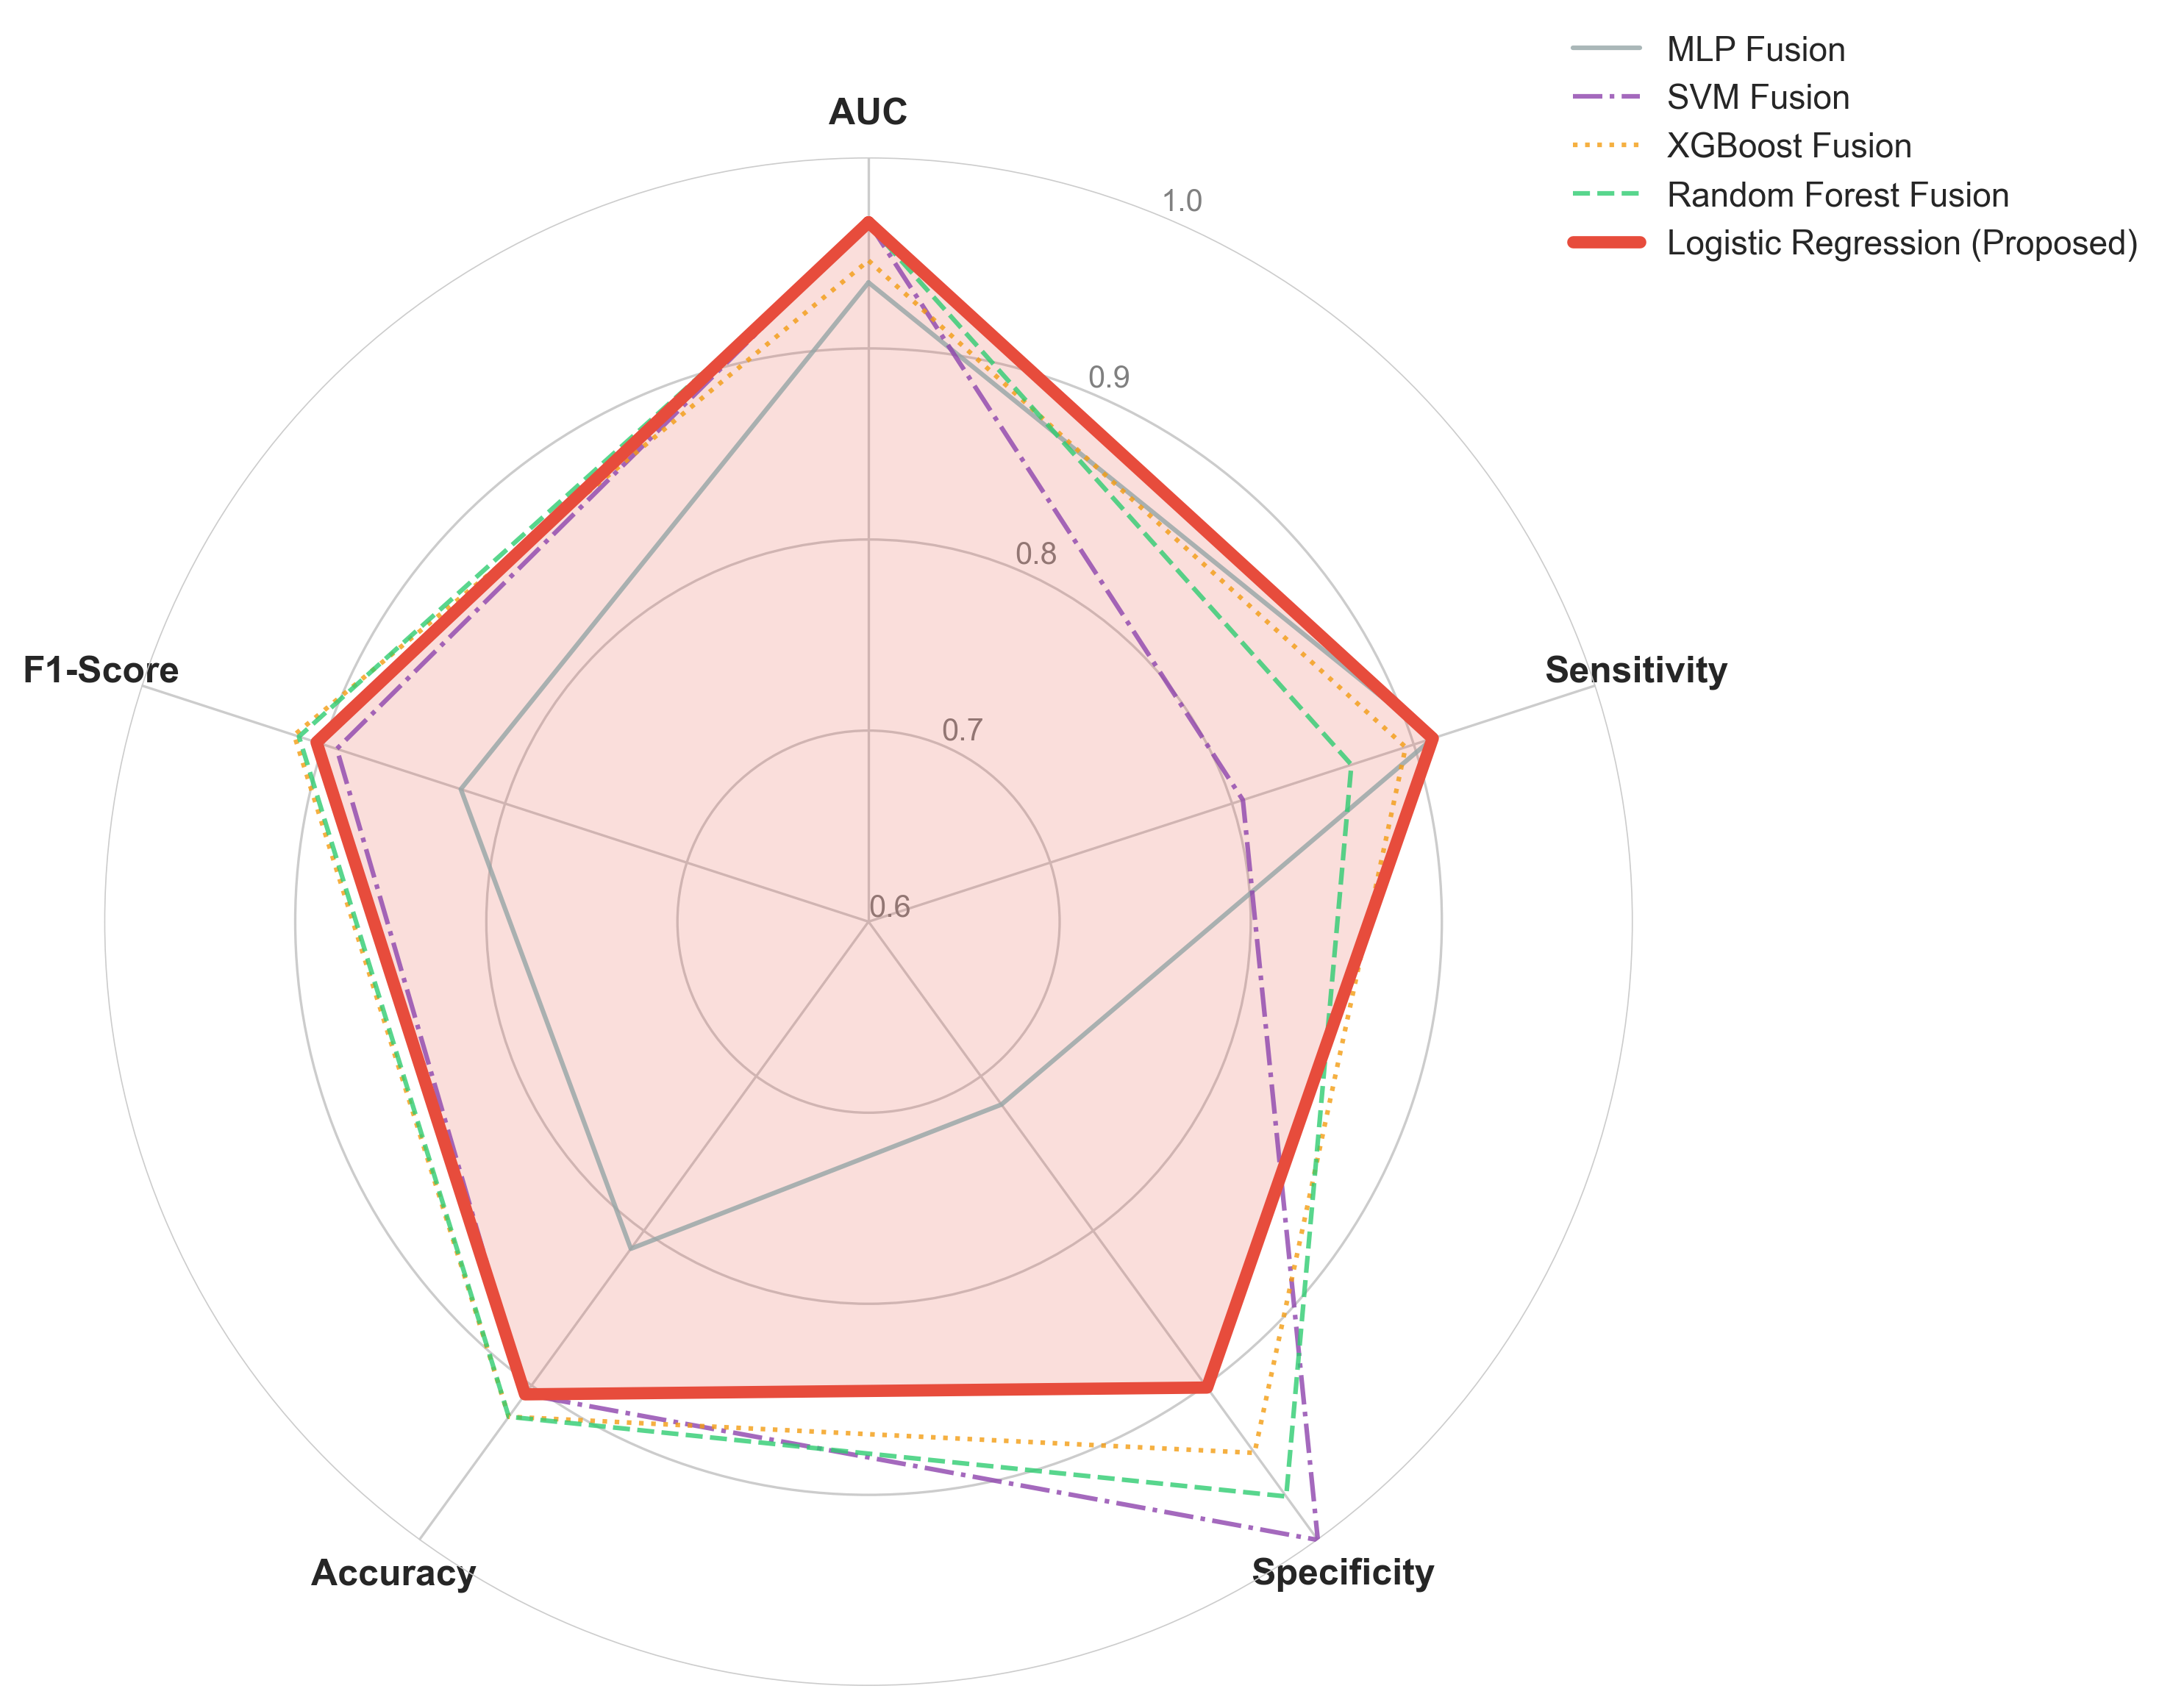

In [ ]:
# Radar Plot for Model Performance Comparison
import numpy as np
import matplotlib.pyplot as plt

TOTAL_SAMPLES = 138  
TOTAL_POS = 67       
TOTAL_NEG = 71      

def calculate_radar_metrics_acc(auc, tn, tp, fp):
    """
    计算指标：AUC, Sensitivity, Specificity, ACC, F1-Score
    """
    fn = TOTAL_POS - tp
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / TOTAL_SAMPLES
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    if (precision + sensitivity) > 0:
        f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)
    else:
        f1_score = 0
        
    return [auc, sensitivity, specificity, accuracy, f1_score]

LR  = calculate_radar_metrics_acc(0.966, 64, 61, 7)  # AUC, tn, tp, fp
RF  = calculate_radar_metrics_acc(0.965, 69, 58, 2)
XGB = calculate_radar_metrics_acc(0.946, 67, 60, 4)
SVM = calculate_radar_metrics_acc(0.966, 71, 54, 0)
MLP = calculate_radar_metrics_acc(0.9345, 51, 61, 20)

print("\n" + "=" * 80)
print("模型融合策略性能指标（内部测试集, n=138）")
print("=" * 80)
print(f"{'Model':<28} {'AUC':<10} {'Sensitivity':<12} {'Specificity':<12} {'Accuracy':<10} {'F1-Score':<10}")
print("-" * 80)

models = [
    ("Logistic Regression (Proposed)", LR),
    ("Random Forest Fusion", RF),
    ("XGBoost Fusion", XGB),
    ("SVM Fusion", SVM),
    ("MLP Fusion", MLP)
]

for name, metrics in models:
    auc, sens, spec, acc, f1 = metrics
    print(f"{name:<28} {auc:<10.4f} {sens:<12.4f} {spec:<12.4f} {acc:<10.4f} {f1:<10.4f}")

print("=" * 80 + "\n")

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial'] 

labels = ['AUC', 'Sensitivity', 'Specificity', 'Accuracy', 'F1-Score']
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

def close_loop(data):
    return data + data[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2) 
ax.set_theta_direction(-1)     

ax.plot(angles, close_loop(MLP), color='#95a5a6', lw=1.5, ls='-', label='MLP Fusion', alpha=0.8)
ax.plot(angles, close_loop(SVM), color='#8e44ad', lw=1.5, ls='-.', label='SVM Fusion', alpha=0.8)
ax.plot(angles, close_loop(XGB), color='#f39c12', lw=1.5, ls=':', label='XGBoost Fusion', alpha=0.8)
ax.plot(angles, close_loop(RF),  color='#2ecc71', lw=1.5, ls='--', label='Random Forest Fusion', alpha=0.8)

ax.plot(angles, close_loop(LR), color='#e74c3c', lw=4, label='Logistic Regression (Proposed)')
ax.fill(angles, close_loop(LR), color='#e74c3c', alpha=0.18)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')

ax.set_ylim(0.6, 1.0) 
ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['0.6', '0.7', '0.8', '0.9', '1.0'], color="grey", size=10)
ax.spines['polar'].set_visible(False) 

plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11, frameon=False)
# plt.title('Performance Comparison of Model Fusion Strategies\n(Internal Testing Set, n=138)', 
#           size=16, fontweight='bold', y=1.1)

plt.show()

# External validation

In [ ]:
# load external patient data from JSON
save_path = r"D:\MED\SpM\external_patient_data.json"
def load_dict_from_json(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    print(f"已成功从 JSON 文件加载字典，共 {len(data)} 名患者。")
    return data
external_patient_data = load_dict_from_json(save_path)

已成功从 JSON 文件加载字典，共 218 名患者。


In [ ]:
# tra_top1-3, sag_top1-3 scores + paths, true label
import os
import json
import torch
import torchvision
import numpy as np
import pandas as pd
from tqdm import tqdm
from ultralytics import YOLO
from torchvision import transforms
from torchvision.transforms import functional as F
import pydicom 
import warnings
warnings.filterwarnings('ignore')

def read_dcm_as_uint8(dcm_path, window_center=40, window_width=400):
    try:
        ds = pydicom.dcmread(dcm_path)
        img = ds.pixel_array.astype(float)
        
        # 尝试读取 DICOM 自带的斜率和截距进行 HU 值修正
        if hasattr(ds, 'RescaleSlope') and hasattr(ds, 'RescaleIntercept'):
            img = img * float(ds.RescaleSlope) + float(ds.RescaleIntercept)
            
        # 应用窗宽窗位截断逻辑
        min_pixel = window_center - (window_width / 2)
        max_pixel = window_center + (window_width / 2)
        img = np.clip(img, min_pixel, max_pixel)
        
        # 归一化到 0-255
        img = (img - min_pixel) / (max_pixel - min_pixel + 1e-8) * 255
        return img.astype(np.uint8)
    except Exception as e:
        print(f"\n❌ 读取 DICOM 文件失败 {dcm_path}: {e}")
        # 如果读取失败返回空数组，避免整个循环死掉
        return np.zeros((512, 512), dtype=np.uint8)


class RetinaNetWithConvNeXtPredictor:
    def __init__(self, retina_model_path, convnext_model_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        self.retina_model = torchvision.models.detection.retinanet_resnet50_fpn(pretrained=False, num_classes=3)
        retina_ckpt = torch.load(retina_model_path, map_location=self.device)
        self.retina_model.load_state_dict(retina_ckpt['model_state_dict'] if 'model_state_dict' in retina_ckpt else retina_ckpt)
        self.retina_model.to(self.device).eval()
        
        self.convnext_model = torchvision.models.convnext_tiny(pretrained=False)
        self.convnext_model.classifier[2] = torch.nn.Linear(self.convnext_model.classifier[2].in_features, 2)
        self.convnext_model.load_state_dict(torch.load(convnext_model_path, map_location=self.device))
        self.convnext_model.to(self.device).eval()
        
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)), 
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def predict(self, dcm_path):
        try:
            img_uint8 = read_dcm_as_uint8(dcm_path)
            img_tensor = F.to_tensor(img_uint8).unsqueeze(0).to(self.device)
            
            with torch.no_grad():
                pred = self.retina_model(img_tensor)
                
            if len(pred) > 0 and len(pred[0]['scores']) > 0:
                idx = torch.argmax(pred[0]['scores'])
                if pred[0]['labels'][idx] == 1: 
                    box = pred[0]['boxes'][idx].cpu().numpy().astype(int)
                    roi_array = img_uint8[box[1]:box[3], box[0]:box[2]]
                    roi_rgb = cv2.cvtColor(roi_array, cv2.COLOR_GRAY2RGB)
                    
                    from PIL import Image as PILImage
                    roi_pil = PILImage.fromarray(roi_rgb)
                    roi_tensor = self.transform(roi_pil).unsqueeze(0).to(self.device)
                    
                    outputs = self.convnext_model(roi_tensor)
                    prob = torch.softmax(outputs, dim=1)[:, 1].item()
                    return 1 if prob > 0.5 else 0, prob
            return 0, 0.0
        except: 
            return 0, 0.0


class YOLOPredictor:
    def __init__(self, model_path):
        self.model = YOLO(model_path)
        
    def predict(self, dcm_path):
        try:
            img_uint8 = read_dcm_as_uint8(dcm_path)
            img_rgb = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2RGB)
            
            results = self.model(img_rgb, verbose=False)
            
            if results and len(results[0].boxes) > 0:
                idx = torch.argmax(results[0].boxes.conf)
                return int(results[0].boxes.cls[idx]) + 1, float(results[0].boxes.conf[idx])
            return 0, 0.0
        except: 
            return 0, 0.0


json_path = r"D:\MED\SpM\external_patient_data.json"

tra_paths = (r"D:\MED\SpM\SpM_pth\Retina\3_train_mIou_0.8730000257492065_valid_mIou_0.8809999823570251.pth",
             r"D:\MED\SpM\SpMjpg-20240920-sagcopy\tra_ConvNeXt_Tiny_pth\epoch_3_train_auc_0.9972_valid_auc_0.9797.pth")
sag_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\best_model.pt"

output_csv_A = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\external_patient_predictions_v2_Convnext_DCM.csv"


print("🚀 [Cell A] 正在加载原生 DICOM 深度学习影像模型...")
tra_predictor = RetinaNetWithConvNeXtPredictor(tra_paths[0], tra_paths[1])
sag_predictor = YOLOPredictor(sag_path)

with open(json_path, 'r', encoding='utf-8') as f: 
    data_dict = json.load(f)
patient_records = []

print(f"📸 正在对 {len(data_dict)} 名患者进行原生 DICOM 影像推理，并提取 Top3 路径...")
for pid, info in tqdm(data_dict.items()):
    
    tra_list = [(tra_predictor.predict(p)[1], os.path.abspath(p)) for p in info.get('tra_seq', [])]
    tra_list.sort(key=lambda x: x[0], reverse=True) 
    while len(tra_list) < 3: tra_list.append((0.0, ''))
        
    sag_list = [(sag_predictor.predict(p)[1], os.path.abspath(p)) for p in info.get('sag_seq', [])]
    sag_list.sort(key=lambda x: x[0], reverse=True)
    while len(sag_list) < 3: sag_list.append((0.0, ''))

    rec = {
        'patient_name': info.get('name', ''),
        'center': info.get('center', ''),
        'sex': info.get('sex', ''),
        'age': info.get('age', ''),
        'diag': info.get('diag', ''),
        'sub_diag': info.get('sub_diag', ''),
        
        'tra_top1_score': tra_list[0][0], 'tra_top1_path': tra_list[0][1],
        'tra_top2_score': tra_list[1][0], 'tra_top2_path': tra_list[1][1],
        'tra_top3_score': tra_list[2][0], 'tra_top3_path': tra_list[2][1],
        
        'sag_top1_score': sag_list[0][0], 'sag_top1_path': sag_list[0][1],
        'sag_top2_score': sag_list[1][0], 'sag_top2_path': sag_list[1][1],
        'sag_top3_score': sag_list[2][0], 'sag_top3_path': sag_list[2][1],
        
        'p_true_label': info.get('true_label', 0)
    }
    patient_records.append(rec)

df_base = pd.DataFrame(patient_records)
os.makedirs(os.path.dirname(output_csv_A), exist_ok=True)
df_base.to_csv(output_csv_A, index=False, encoding='utf-8-sig')

print(f"\n✅ [Cell A] 特征提取全部完成！数据已存至: {output_csv_A}")

🚀 [Cell A] 正在加载深度学习影像模型...
📸 正在对 218 名患者进行影像推理，并提取 Top3 路径...


100%|██████████| 218/218 [02:09<00:00,  1.68it/s]


✅ [Cell A] 影像特征提取完成！数据已存至: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\external_patient_predictions_v2_Convnext.csv


In [ ]:
# LR fusion
import os
import pandas as pd
import joblib

input_csv = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\external_patient_predictions_v2_Convnext.csv"
pkg_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\logistic_lasso_3factors_convnext.pkl" 
output_csv_B = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\external_patient_predictions_logistics_3factors_convnext.csv"

print("🚀 [Cell B] 正在加载基础特征数据与 Logistics 模型...")
if not os.path.exists(input_csv):
    print(f"❌ 找不到基础数据文件，请先运行 Cell A生成: {input_csv}")
else:
    df_external = pd.read_csv(input_csv)
    pkg = joblib.load(pkg_path)
    logreg, scaler, feature_cols = pkg['model'], pkg['scaler'], pkg['features']

    df_external[feature_cols] = df_external[feature_cols].fillna(0.0)

    print("🧠 正在执行 Logistics 回归分析...")
    X_scaled = scaler.transform(df_external[feature_cols].values)
    
    df_external['logreg_prob'] = logreg.predict_proba(X_scaled)[:, 1]
    df_external['logreg_pred'] = (df_external['logreg_prob'] > 0.5).astype(int)

    df_external.to_csv(output_csv_B, index=False, encoding='utf-8-sig')

    print(f"\n✅ [Cell B] 融合预测完成！")
    print(f"📊 包含患者信息、影像路径及最终 Logistics 概率的结果已存至: {output_csv_B}")

🚀 [Cell B] 正在加载基础特征数据与 Logistics 模型...
🧠 正在执行 Logistics 回归分析...

✅ [Cell B] 融合预测完成！
📊 包含患者信息、影像路径及最终 Logistics 概率的结果已存至: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\external_patient_predictions_logistics_3factors_convnext.csv


🚀 正在加载数据与 Logistic 回归模型...

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 📊 正在分析队列: Overall Patients (样本量: 218)
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  > ACCURACY    : 0.9083
  > SENSITIVITY : 0.9145
  > SPECIFICITY : 0.8939
  > AUC         : 0.9653
  > AP          : 0.9843


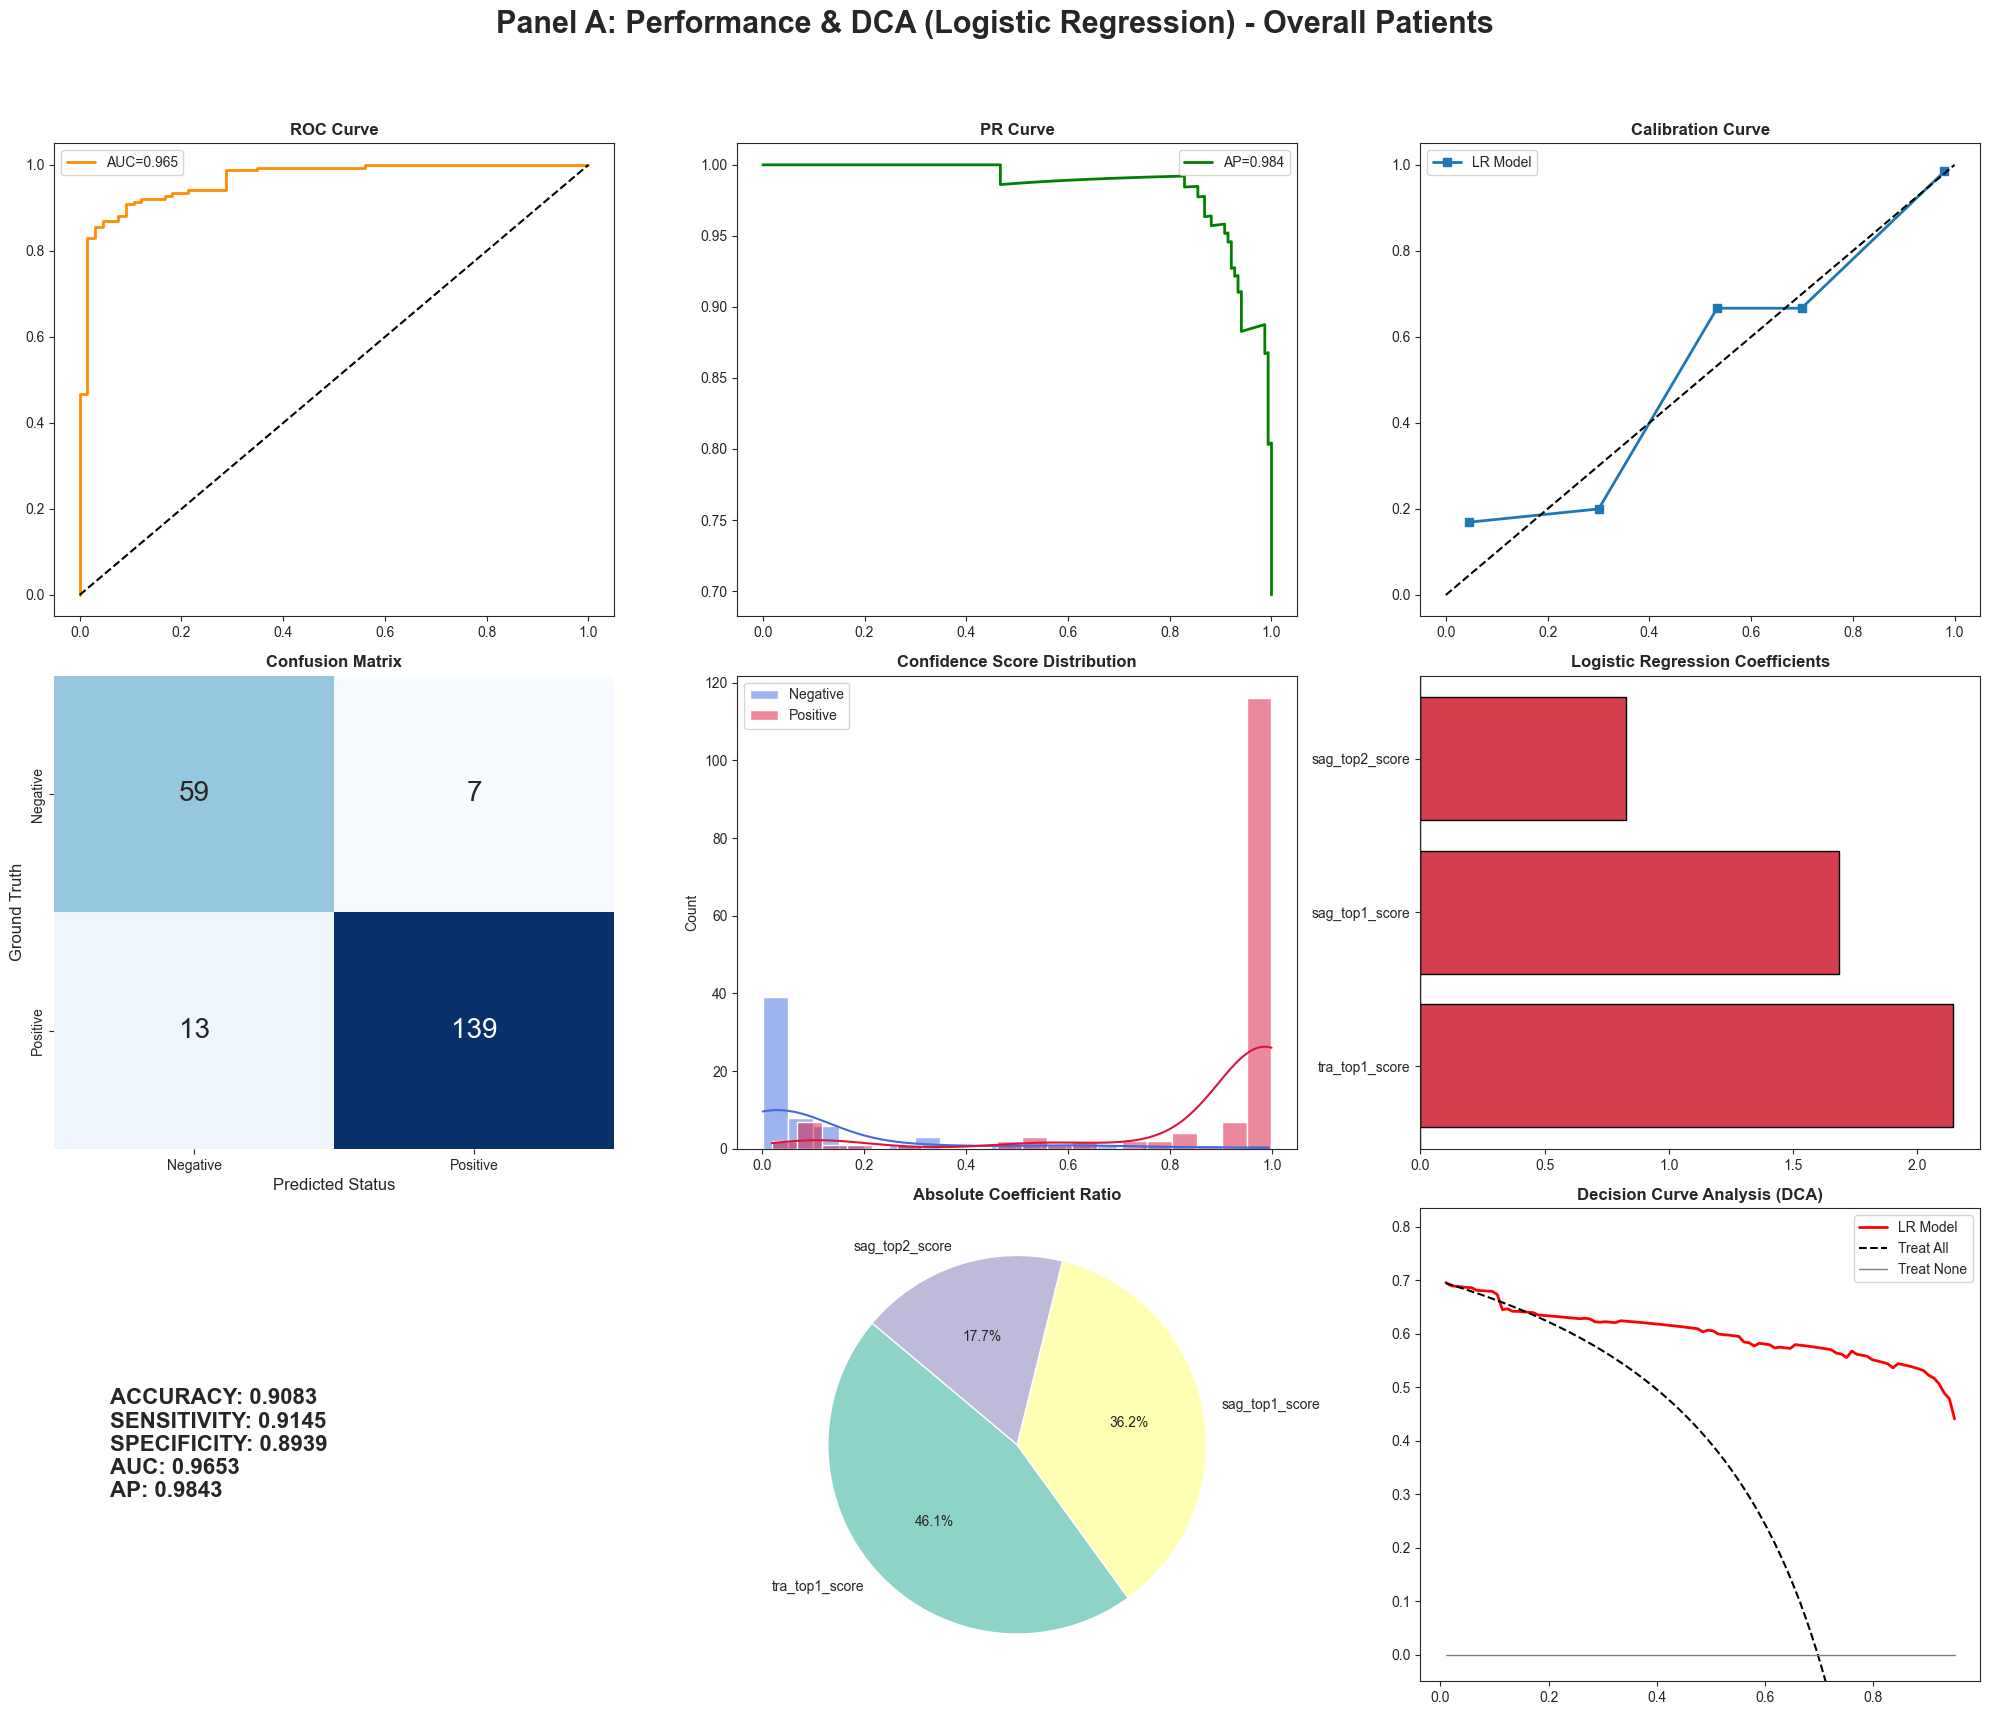

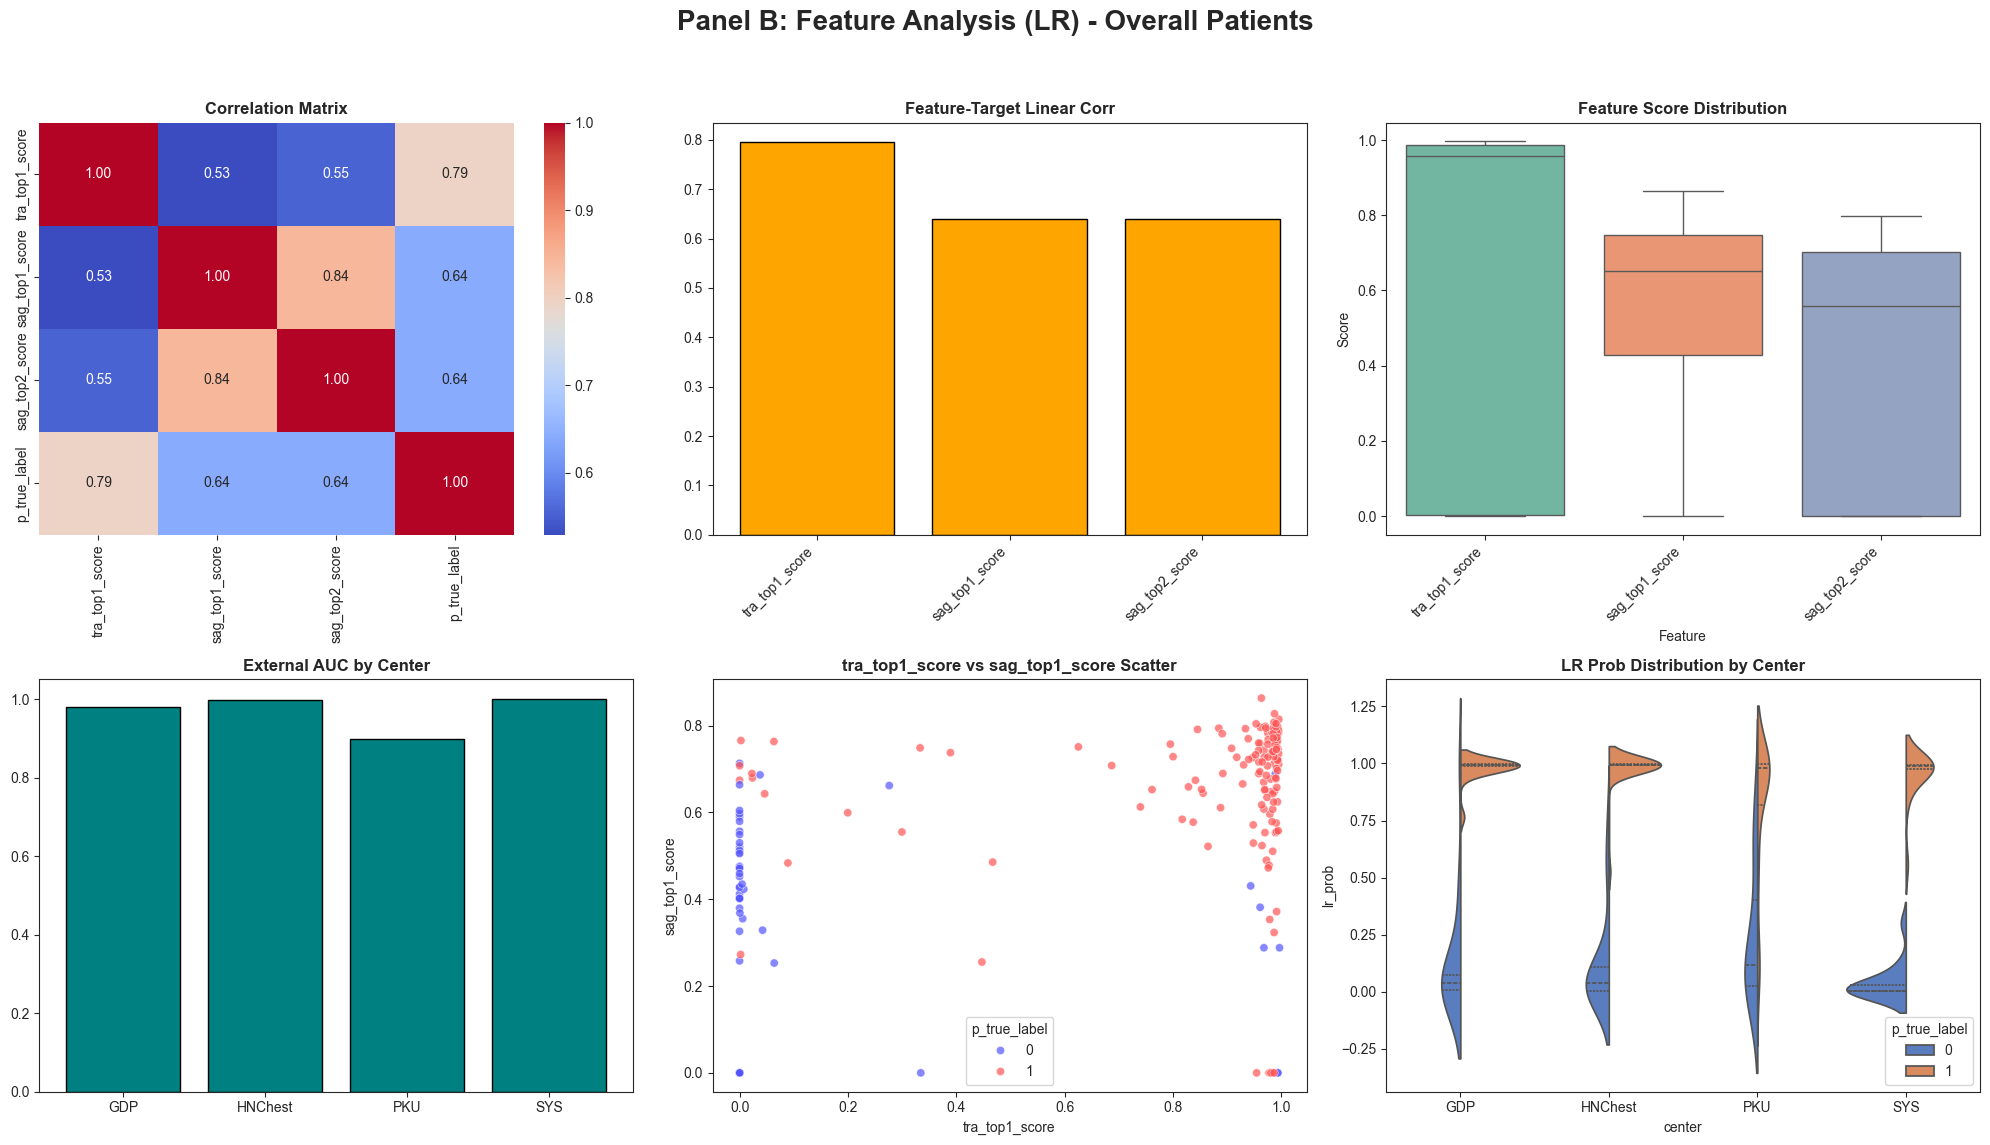


 🚨 错误溯源清单 (Error Case Review) - Overall Patients

🔴 假阳性 (False Positives / 无压迫被判为有压迫) : 共 7 例
----------------------------------------------------------------------
 [患者]: MR201812220038  | [预测阳性概率]: 0.993 | [目录]: D:\MED\SpM\external validation\GDP_SpM\MR201812220038
 [患者]: GuGenPo         | [预测阳性概率]: 0.758 | [目录]: D:\MED\SpM\external validation\HNChest_TB\GuGenPo
 [患者]: LiuSuRong       | [预测阳性概率]: 0.524 | [目录]: D:\MED\SpM\external validation\HNChest_TB\LiuSuRong
 [患者]: SunHongZhen     | [预测阳性概率]: 0.586 | [目录]: D:\MED\SpM\external validation\HNChest_TB\SunHongZhen
 [患者]: FanChangQing    | [预测阳性概率]: 0.648 | [目录]: D:\MED\SpM\external validation\PKU\PKU_SpM\FanChangQing
 [患者]: YinTao          | [预测阳性概率]: 0.838 | [目录]: D:\MED\SpM\external validation\PKU\PKU_SpM\YinTao
 [患者]: WangLiFang      | [预测阳性概率]: 0.625 | [目录]: D:\MED\SpM\external validation\PKU\PKU_TDH\WangLiFang

⚠️ 假阴性 (False Negatives / 真实有压迫却漏诊) : 共 13 例
----------------------------------------------------------------------
 [患者

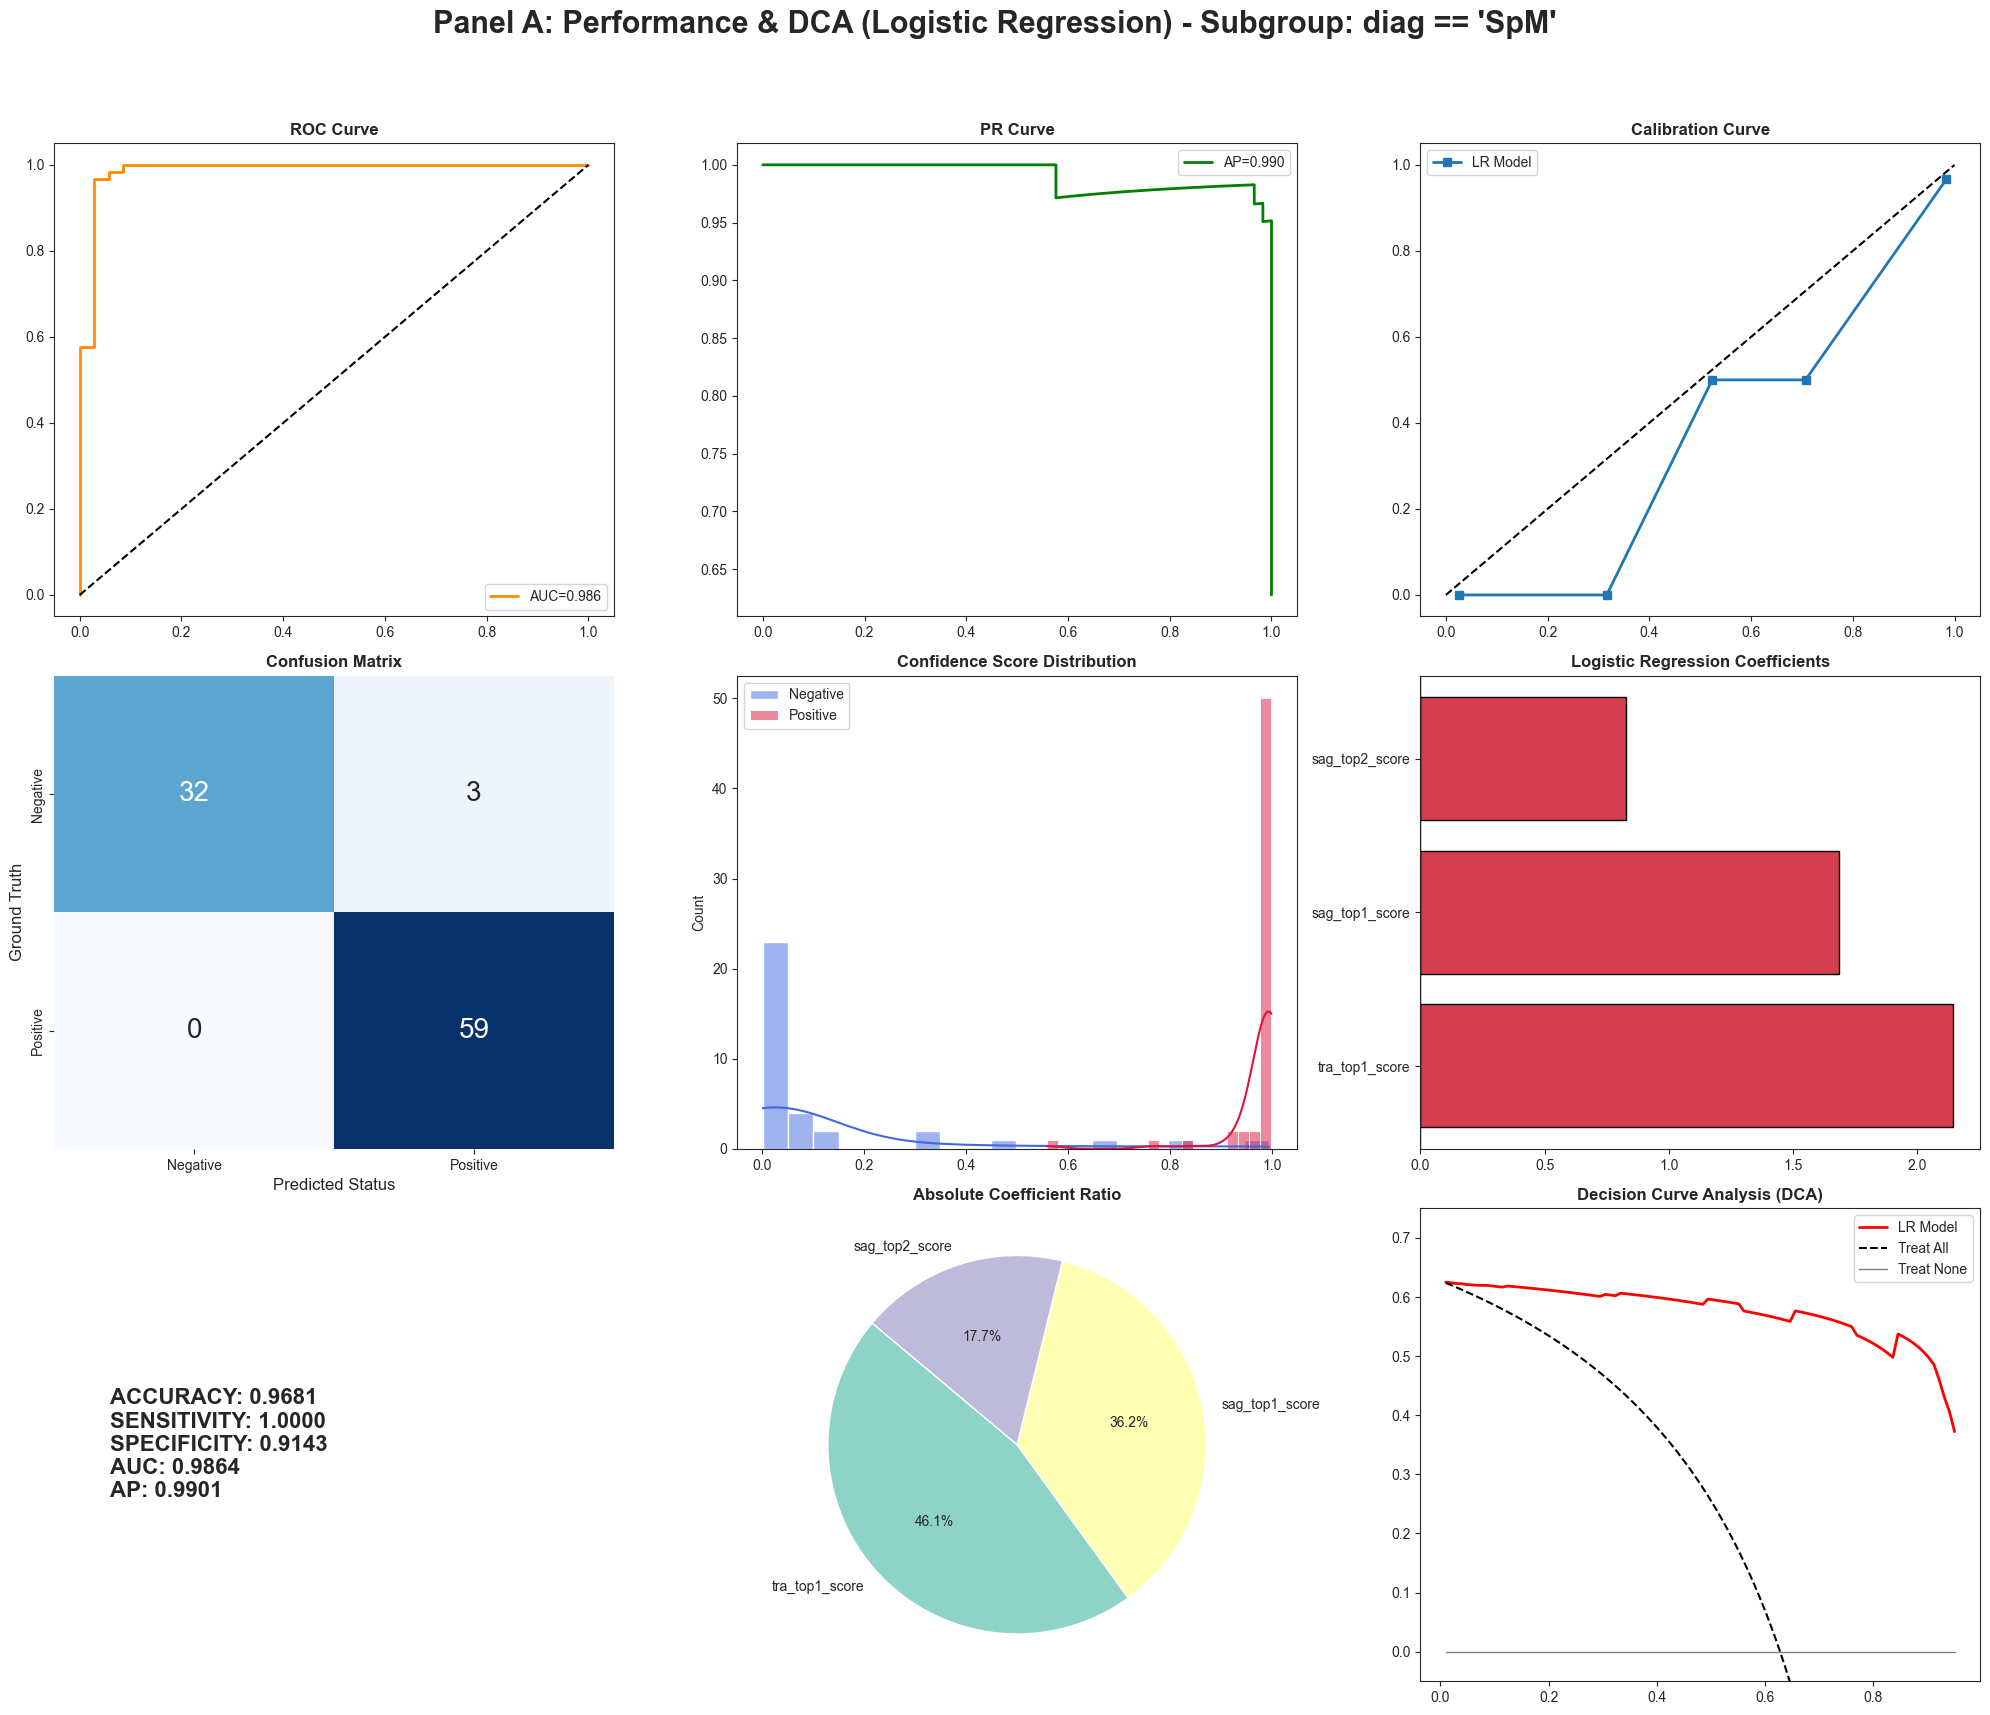

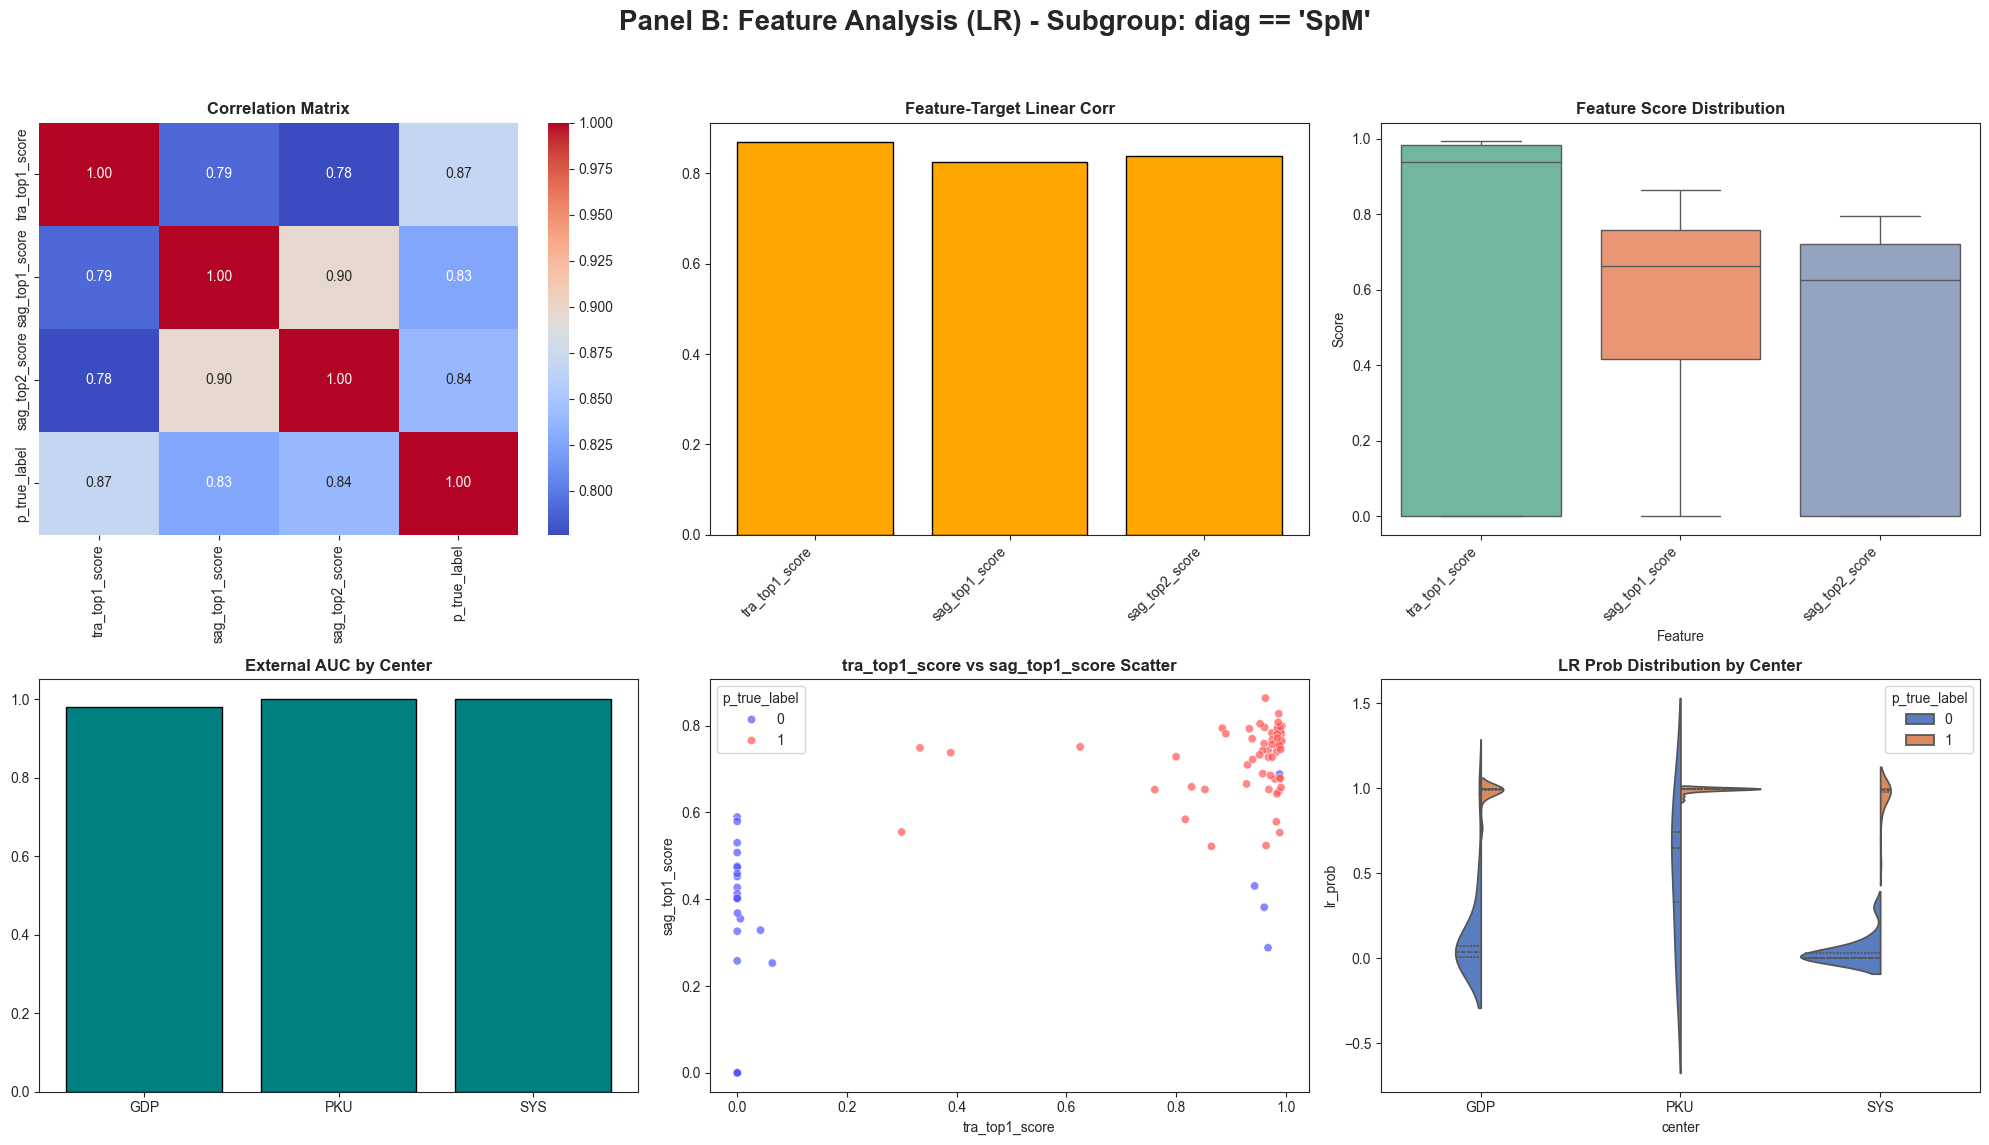


 🚨 错误溯源清单 (Error Case Review) - Subgroup: diag == 'SpM'

🔴 假阳性 (False Positives / 无压迫被判为有压迫) : 共 3 例
----------------------------------------------------------------------
 [患者]: MR201812220038  | [预测阳性概率]: 0.993 | [目录]: D:\MED\SpM\external validation\GDP_SpM\MR201812220038
 [患者]: FanChangQing    | [预测阳性概率]: 0.648 | [目录]: D:\MED\SpM\external validation\PKU\PKU_SpM\FanChangQing
 [患者]: YinTao          | [预测阳性概率]: 0.838 | [目录]: D:\MED\SpM\external validation\PKU\PKU_SpM\YinTao

⚠️ 假阴性 (False Negatives / 真实有压迫却漏诊) : 共 0 例
----------------------------------------------------------------------
 -> 完美！该队列没有漏诊病例。




★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 📊 正在分析队列: Subgroup: diag != 'SpM' (样本量: 124)
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  > ACCURACY    : 0.8629
  > SENSITIVITY : 0.8602
  > SPECIFICITY : 0.8710
  > AUC         : 0.9473
  > AP          : 0.9831


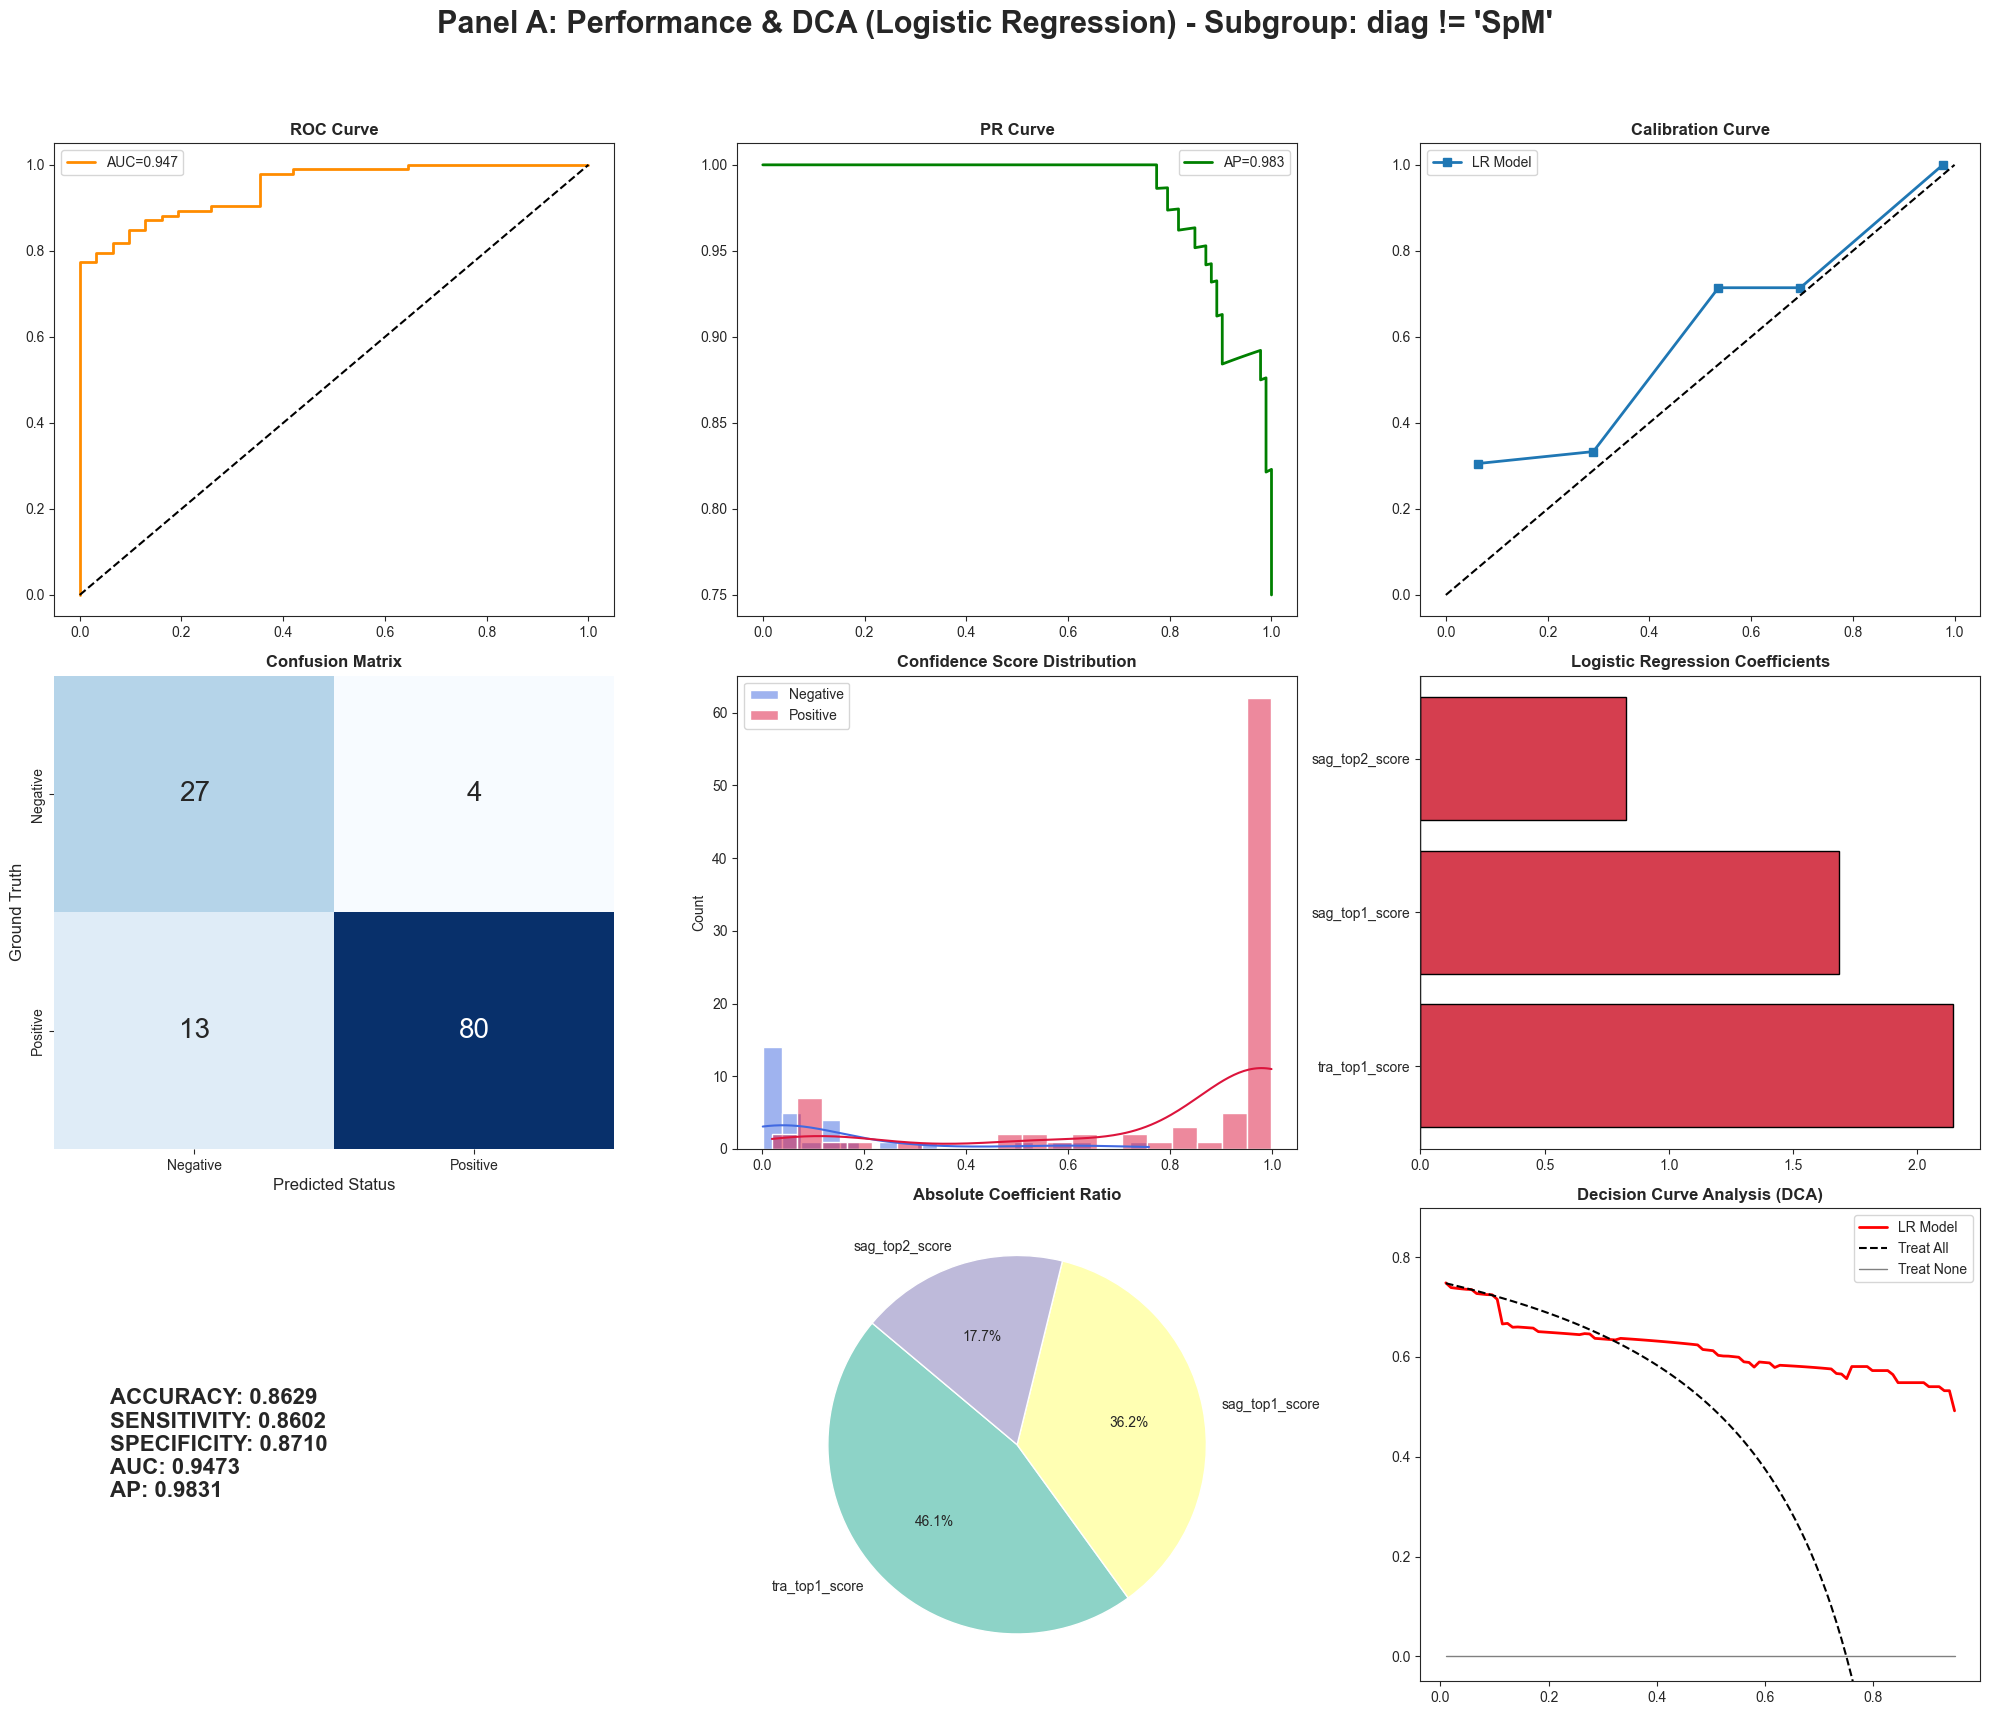

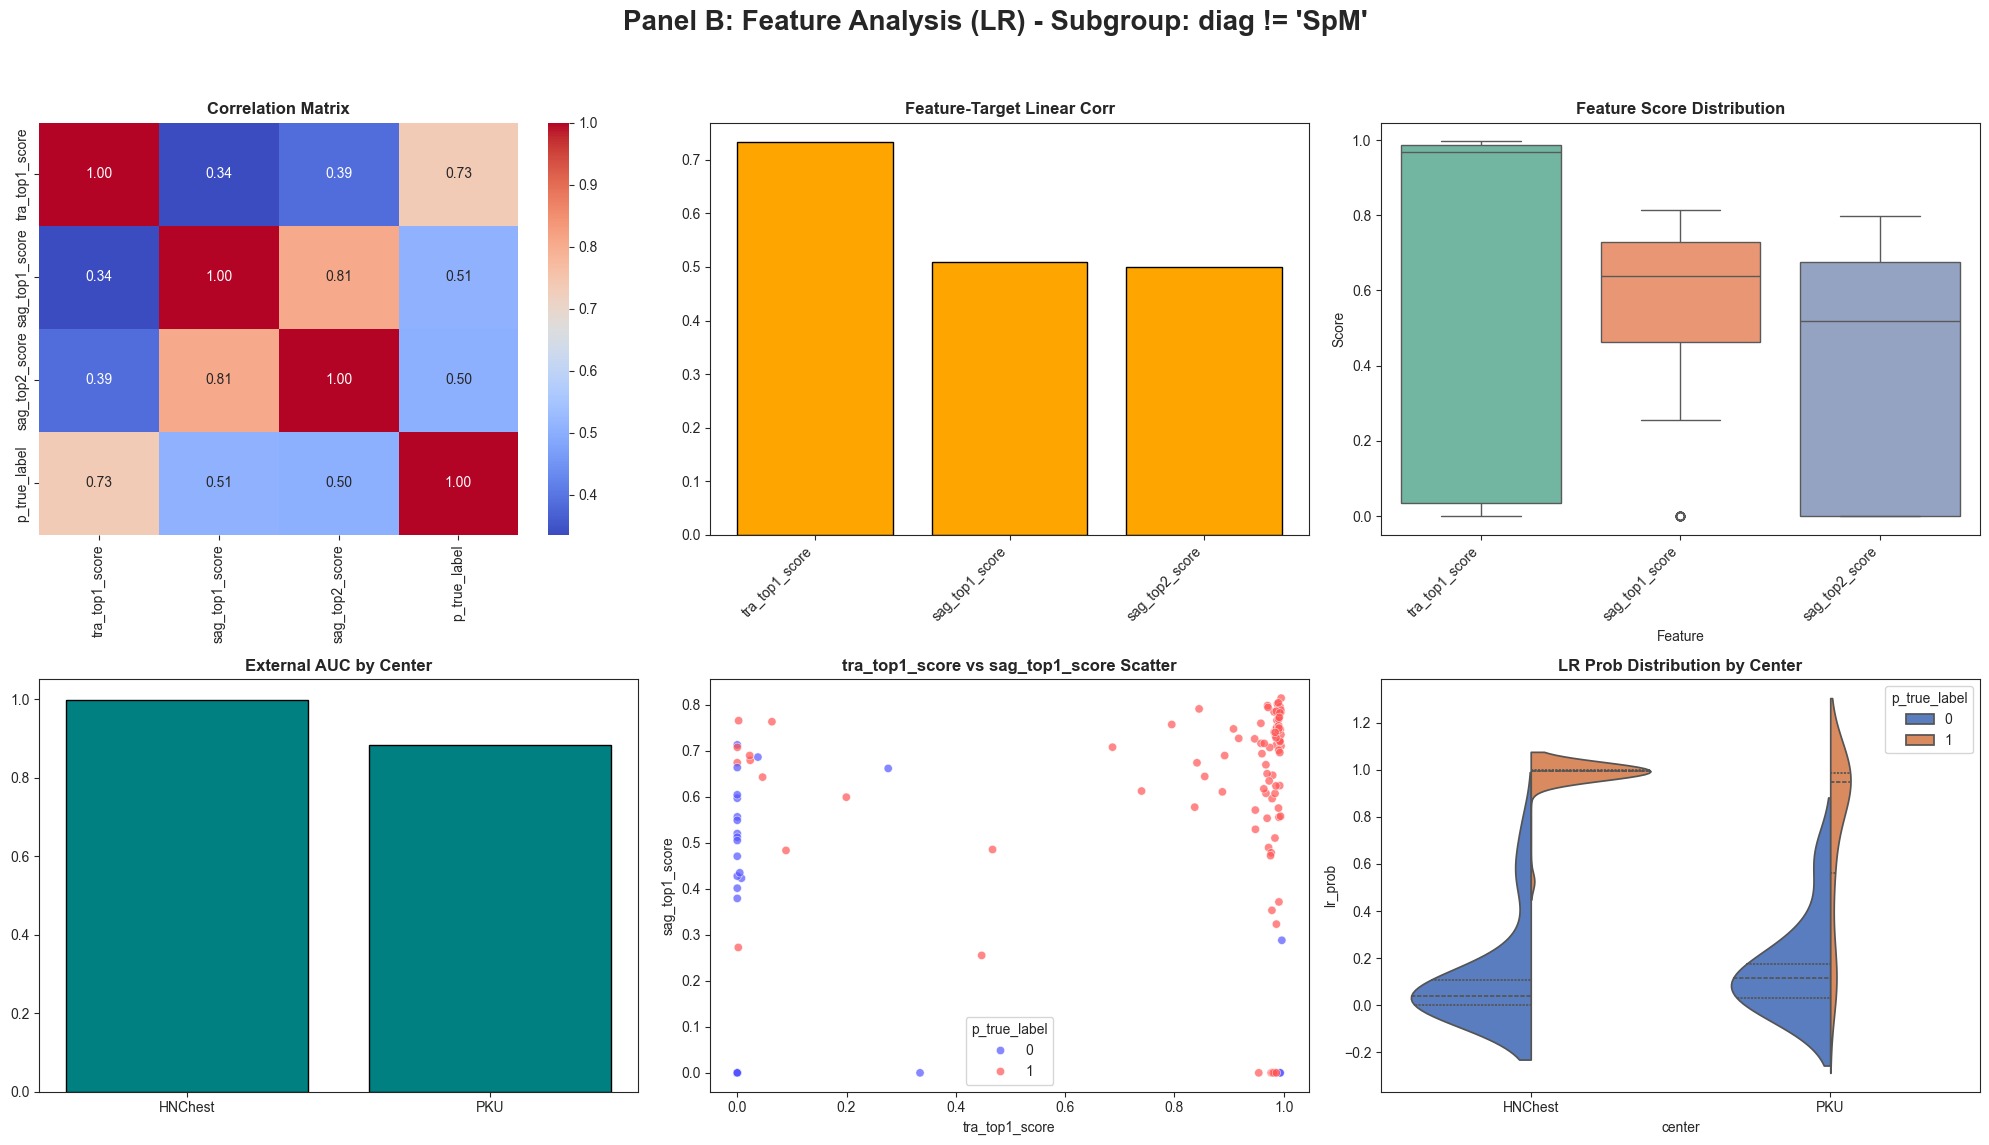


 🚨 错误溯源清单 (Error Case Review) - Subgroup: diag != 'SpM'

🔴 假阳性 (False Positives / 无压迫被判为有压迫) : 共 4 例
----------------------------------------------------------------------
 [患者]: GuGenPo         | [预测阳性概率]: 0.758 | [目录]: D:\MED\SpM\external validation\HNChest_TB\GuGenPo
 [患者]: LiuSuRong       | [预测阳性概率]: 0.524 | [目录]: D:\MED\SpM\external validation\HNChest_TB\LiuSuRong
 [患者]: SunHongZhen     | [预测阳性概率]: 0.586 | [目录]: D:\MED\SpM\external validation\HNChest_TB\SunHongZhen
 [患者]: WangLiFang      | [预测阳性概率]: 0.625 | [目录]: D:\MED\SpM\external validation\PKU\PKU_TDH\WangLiFang

⚠️ 假阴性 (False Negatives / 真实有压迫却漏诊) : 共 13 例
----------------------------------------------------------------------
 [患者]: GaoShiJiang     | [预测阳性概率]: 0.098 | [目录]: D:\MED\SpM\external validation\PKU\PKU_OL\GaoShiJiang
 [患者]: MaChengLan      | [预测阳性概率]: 0.476 | [目录]: D:\MED\SpM\external validation\PKU\PKU_OL\MaChengLan
 [患者]: WeiZhenYi       | [预测阳性概率]: 0.061 | [目录]: D:\MED\SpM\external validation\PKU\PKU_OL\WeiZhenY

In [ ]:
# LR external validation：(Overall, SpM, Non-SpM)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
import warnings
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, 
                             precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore') 

csv_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\external_patient_predictions_logistics_3factors_convnext.csv"
pkg_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\logistic_lasso_3factors_convnext.pkl"

print("🚀 正在加载数据与 Logistic 回归模型...")
df = pd.read_csv(csv_path)
pkg = joblib.load(pkg_path)

lr_model = pkg['model']
feature_cols = pkg['features']
scaler = pkg.get('scaler', None) 

df[feature_cols] = df[feature_cols].fillna(0)

def get_patient_root_dir(row):
    for col in ['tra_top1_path', 'sag_top1_path', 'tra_top2_path', 'sag_top2_path']:
        if col in row and pd.notna(row[col]) and str(row[col]).strip() != '':
            path = str(row[col])
            folder_dir = os.path.dirname(path)
            patient_dir = os.path.dirname(folder_dir)
            return patient_dir
    return "❌ 无法提取路径 (图片路径列为空)"

def calculate_net_benefit(y_true, y_proba, thresholds):
    n = len(y_true)
    nb = []
    for pt in thresholds:
        if pt < 1.0:
            tp_rate = np.sum((y_proba >= pt) & (y_true == 1)) / n
            fp_rate = np.sum((y_proba >= pt) & (y_true == 0)) / n
            nb.append(tp_rate - fp_rate * (pt / (1 - pt)))
        else:
            nb.append(0)
    return nb

def evaluate_cohort(cohort_df, cohort_name):
    print("\n" + "★"*60)
    print(f" 📊 正在分析队列: {cohort_name} (样本量: {len(cohort_df)})")
    print("★"*60)
    
    if len(cohort_df) == 0:
        print("❌ 该队列为空，跳过分析。")
        return

    X = cohort_df[feature_cols].values
    
    if scaler is not None:
        X = scaler.transform(X)
        
    y_true = cohort_df['p_true_label'].values
    y_prob = lr_model.predict_proba(X)[:, 1]
    y_pred = lr_model.predict(X)
    
    cohort_df = cohort_df.copy()
    cohort_df['lr_prob'] = y_prob
    cohort_df['lr_pred'] = y_pred

    has_both_classes = len(np.unique(y_true)) > 1

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0) 
    
    metrics = {
        'accuracy': (tp + tn) / len(y_true) if len(y_true) > 0 else 0,
        'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else np.nan,
    }
    
    if has_both_classes:
        metrics['auc'] = roc_auc_score(y_true, y_prob)
        metrics['ap'] = average_precision_score(y_true, y_prob)
    else:
        metrics['auc'] = np.nan
        metrics['ap'] = np.nan
        print("⚠️ 注意: 该队列只包含单一类别(全是阳性或全阴性)，无法计算AUC/AP。")

    for k, v in metrics.items():
        print(f"  > {k.upper():12}: {v:.4f}")

    fig, axes = plt.subplots(3, 3, figsize=(20, 18))
    plt.suptitle(f"Panel A: Performance & DCA (Logistic Regression) - {cohort_name}", fontsize=22, fontweight='bold')

    if has_both_classes:
        # ROC
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        axes[0,0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={metrics["auc"]:.3f}')
        axes[0,0].plot([0,1],[0,1],'k--'); axes[0,0].set_title("ROC Curve", fontweight='bold'); axes[0,0].legend()
        # PR
        p, r, _ = precision_recall_curve(y_true, y_prob)
        axes[0,1].plot(r, p, color='green', lw=2, label=f'AP={metrics["ap"]:.3f}')
        axes[0,1].set_title("PR Curve", fontweight='bold'); axes[0,1].legend()
        # Calibration
        try:
            p_true_cal, p_pred_cal = calibration_curve(y_true, y_prob, n_bins=5)
            axes[0,2].plot(p_pred_cal, p_true_cal, 's-', lw=2, label='LR Model')
            axes[0,2].plot([0,1],[0,1],'k--'); axes[0,2].set_title("Calibration Curve", fontweight='bold'); axes[0,2].legend()
        except:
            axes[0,2].text(0.5, 0.5, "Calibration failed", ha='center')
    else:
        for i in range(3):
            axes[0,i].text(0.5, 0.5, "Requires both positive\nand negative samples", ha='center', fontsize=12)
            axes[0,i].axis('off')

    # CM & Prob Distribution
    if cm.size == 4:
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1,0],
                    annot_kws={"size": 20}, 
            xticklabels=['Negative', 'Positive'],   
            yticklabels=['Negative', 'Positive'])   

        axes[1,0].set_xlabel('Predicted Status', fontsize=12)
        axes[1,0].set_ylabel('Ground Truth', fontsize=12)
        axes[1,0].set_title("Confusion Matrix", fontweight='bold')

    sns.histplot(x=y_prob[y_true==0], bins=20, color='royalblue', label='Negative', ax=axes[1,1], alpha=0.5, kde=True)
    sns.histplot(x=y_prob[y_true==1], bins=20, color='crimson', label='Positive', ax=axes[1,1], alpha=0.5, kde=True)
    axes[1,1].set_title("Confidence Score Distribution", fontweight='bold'); axes[1,1].legend()

    coefs = lr_model.coef_[0]
    bar_colors = ['#d53e4f' if c > 0 else '#3288bd' for c in coefs]
    axes[1,2].barh(feature_cols, coefs, color=bar_colors, edgecolor='black')
    axes[1,2].axvline(0, color='black', lw=1)
    axes[1,2].set_title("Logistic Regression Coefficients", fontweight='bold')

    # Metrics Text & Pie & DCA
    axes[2,0].axis('off')
    txt = "\n".join([f"{k.upper()}: {v:.4f}" for k,v in metrics.items() if not np.isnan(v)])
    axes[2,0].text(0.1, 0.5, txt, fontsize=16, fontweight='bold', va='center')

    abs_coefs = np.abs(coefs)
    axes[2,1].pie(abs_coefs, labels=feature_cols, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3"))
    axes[2,1].set_title("Absolute Coefficient Ratio", fontweight='bold')

    if has_both_classes:
        th = np.linspace(0.01, 0.95, 100)
        net_benefit_model = calculate_net_benefit(y_true, y_prob, th)
        axes[2,2].plot(th, net_benefit_model, 'r-', lw=2, label='LR Model')
        axes[2,2].plot(th, calculate_net_benefit(y_true, np.ones(len(y_true)), th), 'k--', label='Treat All')
        axes[2,2].plot(th, [0]*100, 'gray', lw=1, label='Treat None')
        axes[2,2].set_ylim(-0.05, max(max(net_benefit_model)*1.2, 0.1))
        axes[2,2].legend(); axes[2,2].set_title("Decision Curve Analysis (DCA)", fontweight='bold')
    else:
        axes[2,2].text(0.5, 0.5, "DCA requires both classes", ha='center', fontsize=12); axes[2,2].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    fig_b = plt.figure(figsize=(20, 12))
    plt.suptitle(f"Panel B: Feature Analysis (LR) - {cohort_name}", fontsize=20, fontweight='bold')

    plt.subplot(2, 3, 1)
    if has_both_classes:
        sns.heatmap(cohort_df[feature_cols + ['p_true_label']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation Matrix", fontweight='bold')

    plt.subplot(2, 3, 2)
    if has_both_classes:
        plt.bar(feature_cols, [cohort_df[f].corr(cohort_df['p_true_label']) for f in feature_cols], color='orange', edgecolor='black')
        plt.xticks(rotation=45, ha='right')
    plt.title("Feature-Target Linear Corr", fontweight='bold')

    plt.subplot(2, 3, 3)
    df_melt = cohort_df.melt(value_vars=feature_cols, var_name='Feature', value_name='Score')
    sns.boxplot(data=df_melt, x='Feature', y='Score', palette='Set2')
    plt.xticks(rotation=45, ha='right'); plt.title("Feature Score Distribution", fontweight='bold')

    plt.subplot(2, 3, 4)
    if 'center' in cohort_df.columns and has_both_classes:
        centers = cohort_df['center'].unique()
        aucs = [roc_auc_score(cohort_df[cohort_df['center']==c]['p_true_label'], cohort_df[cohort_df['center']==c]['lr_prob']) 
                if len(cohort_df[cohort_df['center']==c]['p_true_label'].unique())>1 else 0 for c in centers]
        plt.bar(centers, aucs, color='teal', edgecolor='black'); plt.title("External AUC by Center", fontweight='bold')
        plt.ylim(0, 1.05)
    else:
        plt.text(0.5, 0.5, "Not applicable", ha='center')
        
    plt.subplot(2, 3, 5)
    f1, f2 = feature_cols[0], feature_cols[1]
    sns.scatterplot(data=cohort_df, x=f1, y=f2, hue='p_true_label' if has_both_classes else None, alpha=0.7, palette='seismic')
    plt.title(f"{f1} vs {f2} Scatter", fontweight='bold')

    plt.subplot(2, 3, 6)
    if 'center' in cohort_df.columns:
        sns.violinplot(data=cohort_df, x='center', y='lr_prob', hue='p_true_label' if has_both_classes else None, split=True, inner="quart", palette='muted')
    plt.title("LR Prob Distribution by Center", fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


    print("\n" + "="*70)
    print(f" 🚨 错误溯源清单 (Error Case Review) - {cohort_name}")
    print("="*70)
    
    mask_fp = (cohort_df['p_true_label'] == 0) & (cohort_df['lr_pred'] == 1)
    df_fp = cohort_df[mask_fp]
    
    mask_fn = (cohort_df['p_true_label'] == 1) & (cohort_df['lr_pred'] == 0)
    df_fn = cohort_df[mask_fn]
    
    print(f"\n🔴 假阳性 (False Positives / 无压迫被判为有压迫) : 共 {len(df_fp)} 例")
    print("-" * 70)
    if len(df_fp) > 0:
        for _, row in df_fp.iterrows():
            name = row.get('patient_name', 'Unknown')
            prob = row['lr_prob']
            p_dir = get_patient_root_dir(row)
            print(f" [患者]: {name:<15} | [预测阳性概率]: {prob:.3f} | [目录]: {p_dir}")
    else:
        print(" -> 太棒了！该队列没有假阳性误报。")
        
    print(f"\n⚠️ 假阴性 (False Negatives / 真实有压迫却漏诊) : 共 {len(df_fn)} 例")
    print("-" * 70)
    if len(df_fn) > 0:
        for _, row in df_fn.iterrows():
            name = row.get('patient_name', 'Unknown')
            prob = row['lr_prob']
            p_dir = get_patient_root_dir(row)
            print(f" [患者]: {name:<15} | [预测阳性概率]: {prob:.3f} | [目录]: {p_dir}")
    else:
        print(" -> 完美！该队列没有漏诊病例。")
    print("\n\n")

# Overall
evaluate_cohort(df, cohort_name="Overall Patients")

# Spinal Metastasis
if 'diag' in df.columns:
    df_spm = df[df['diag'] == 'SpM']
    evaluate_cohort(df_spm, cohort_name="Subgroup: diag == 'SpM'")

    # Non-Spinal Metastasis
    df_non_spm = df[df['diag'] != 'SpM']
    evaluate_cohort(df_non_spm, cohort_name="Subgroup: diag != 'SpM'")
else:
    print("❌ 您的CSV文件中没有找到 'diag' 列，无法执行亚组分析。")

In [ ]:
# Internal Test and External
import pandas as pd
import joblib
import os

internal_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\retinayolo_patient_predictions_detailed_mini_ConvnextYOLO.csv"
external_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\external_patient_predictions_logistics_3factors_convnext.csv"
pkg_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\logistic_lasso_3factors_convnext.pkl"
output_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\three_cohorts_results_3factors_mini_convnext.csv"

print("🔄 正在提取内部测试集并计算概率...")
df_internal_raw = pd.read_csv(internal_path)

df_internal = df_internal_raw[df_internal_raw['dataset_type'] == 'test'].copy()

pkg = joblib.load(pkg_path)
logreg, scaler, feature_cols = pkg['model'], pkg['scaler'], pkg['features']

X_internal = df_internal[feature_cols].values
X_internal_scaled = scaler.transform(X_internal)
df_internal['logreg_prob'] = logreg.predict_proba(X_internal_scaled)[:, 1]

df_internal['center'] = 'HNC' 
df_internal['diag'] = 'SpM'  
df_internal['cohort_type'] = 'internal_test'

print("🔄 正在加载外部验证集...")
df_external = pd.read_csv(external_path)
df_external['cohort_type'] = 'external_test'

final_columns = [
    'patient_name', 'center', 'diag',
    'tra_top1_score', 'tra_top2_score', 'tra_top3_score', 
    'sag_top1_score', 'sag_top2_score', 'sag_top3_score',
    'p_true_label', 'logreg_prob', 'cohort_type'
]

df_combined = pd.concat([df_internal, df_external], axis=0, join='inner', ignore_index=True)

df_final = df_combined[final_columns].copy()

df_final.rename(columns={'cohort_type': 'dataset_type'}, inplace=True)

df_final.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"\n✅ 汇总完成！")
print(f"📊 内部测试集样本数: {len(df_internal)}")
print(f"📊 外部验证集样本数: {len(df_external)}")
print(f"📁 最终文件已保存至: {output_path}")

🔄 正在提取内部测试集并计算概率...
🔄 正在加载外部验证集...

✅ 汇总完成！
📊 内部测试集样本数: 138
📊 外部验证集样本数: 218
📁 最终文件已保存至: D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\three_cohorts_results_3factors_mini_convnext.csv


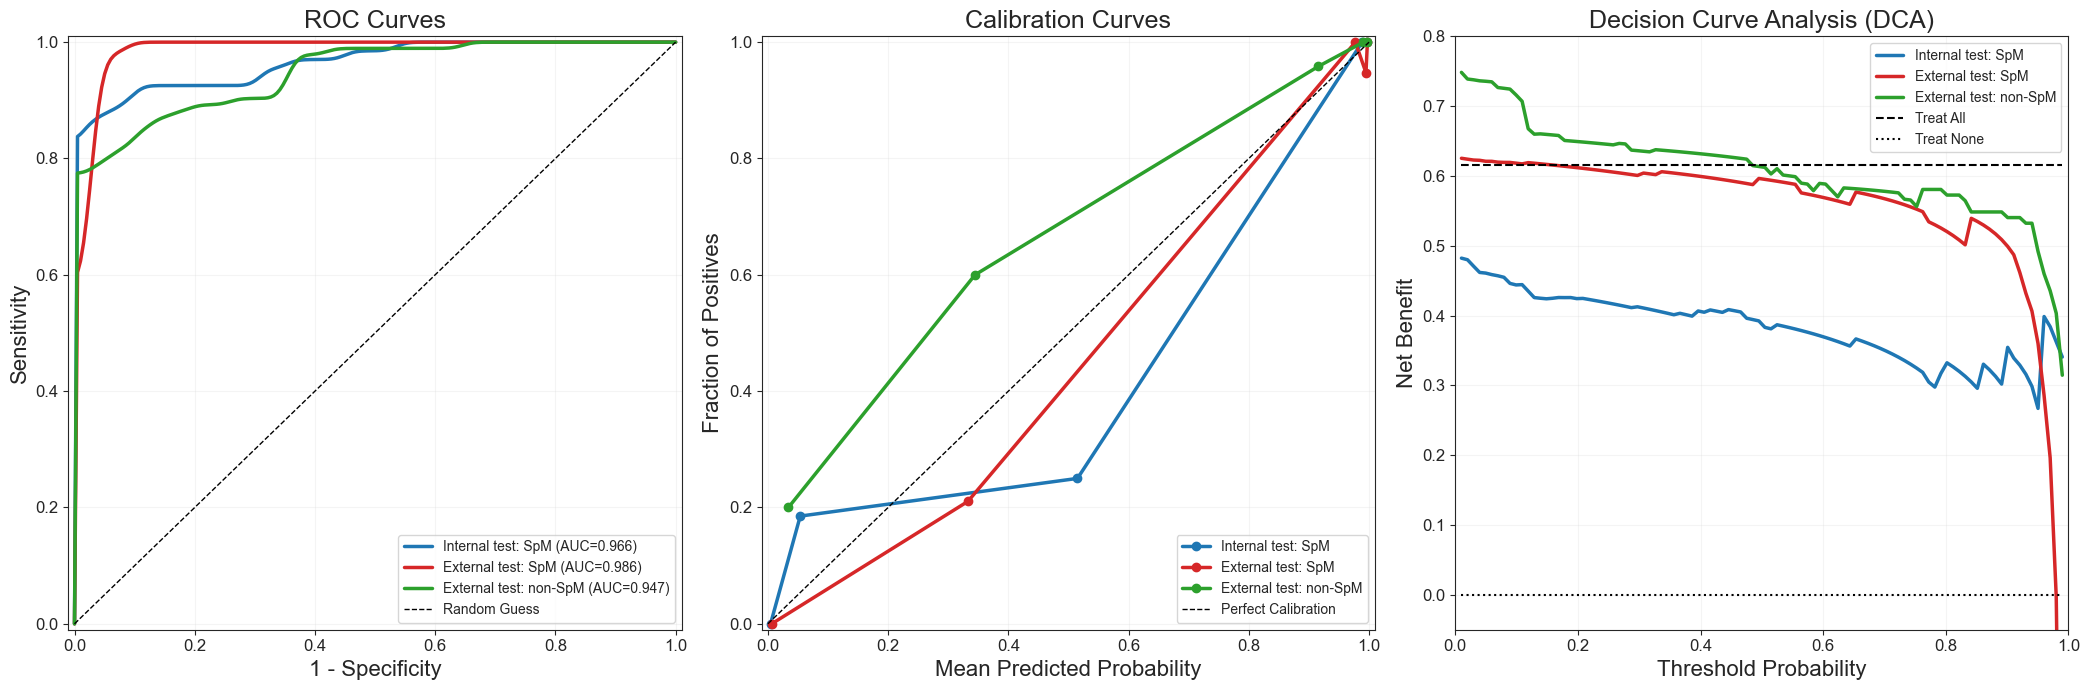

In [ ]:
# Three cohorts analysis: ROC, Calibration, DCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.ndimage import gaussian_filter1d
from sklearn.calibration import calibration_curve

file_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\three_cohorts_results_3factors_mini_convnext.csv"
df = pd.read_csv(file_path)

groups = [
    {'data': df[df['dataset_type'] == 'internal_test'],
     'label': 'Internal test: SpM', 'color': '#1f77b4'},
    {'data': df[(df['dataset_type'] == 'external_test') & (df['diag'] == 'SpM')],
     'label': 'External test: SpM', 'color': '#d62728'},
    {'data': df[(df['dataset_type'] == 'external_test') & (df['diag'] != 'SpM')],
     'label': 'External test: non-SpM', 'color': '#2ca02c'}
]

# DCA 
def dca_curve(y_true, y_pred, thresholds):
    n = len(y_true)
    net_benefit = []
    for t in thresholds:
        y_pred_binary = (y_pred >= t).astype(int)
        tp = np.sum((y_pred_binary == 1) & (y_true == 1))
        fp = np.sum((y_pred_binary == 1) & (y_true == 0))
        nb = (tp / n) - (fp / n) * (t / (1 - t) if t != 1 else 0)
        net_benefit.append(nb)
    return np.array(net_benefit)

fig, axes = plt.subplots(1, 3, figsize=(21, 7), dpi=100)

ax1 = axes[0]
for group in groups:
    data = group['data']
    if len(data) > 1:
        y_true = data['p_true_label']
        y_score = data['logreg_prob']
        
        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc = roc_auc_score(y_true, y_score)
        
        x_smooth = np.linspace(0, 1, 200)
        y_interp = np.interp(x_smooth, fpr, tpr)
        y_smooth = gaussian_filter1d(y_interp, sigma=3)
        y_smooth = np.sort(np.maximum(y_smooth, 0))
        y_smooth[0], y_smooth[-1] = 0, 1
        
        ax1.plot(x_smooth, y_smooth, label=f"{group['label']} (AUC={auc:.3f})",
                 color=group['color'], lw=2.5)
ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
ax1.set_xlim([-0.01, 1.01])
ax1.set_ylim([-0.01, 1.01])
ax1.set_xlabel('1 - Specificity', fontsize=16)
ax1.set_ylabel('Sensitivity', fontsize=16)
ax1.set_title('ROC Curves', fontsize=18)
ax1.tick_params(labelsize=12)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(alpha=0.2)

ax2 = axes[1]
for group in groups:
    data = group['data']
    if len(data) > 1:
        y_true = data['p_true_label']
        y_prob = data['logreg_prob']
        
        frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=5, strategy='quantile')
        ax2.plot(mean_pred, frac_pos, marker='o', lw=2.5, color=group['color'], label=group['label'])
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect Calibration')
ax2.set_xlim([-0.01, 1.01])
ax2.set_ylim([-0.01, 1.01])
ax2.set_xlabel('Mean Predicted Probability', fontsize=16)
ax2.set_ylabel('Fraction of Positives', fontsize=16)
ax2.set_title('Calibration Curves', fontsize=18)
ax2.tick_params(labelsize=12)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(alpha=0.2)

ax3 = axes[2]
thresholds = np.linspace(0.01, 0.99, 100)

for group in groups:
    data = group['data']
    if len(data) > 1:
        y_true = data['p_true_label']
        y_prob = data['logreg_prob']
        nb = dca_curve(y_true, y_prob, thresholds)
        ax3.plot(thresholds, nb, color=group['color'], lw=2.5, label=group['label'])

all_y_true = np.concatenate([g['data']['p_true_label'].values for g in groups])
benefit_treat_all = all_y_true.mean() - thresholds * 0
benefit_treat_none = np.zeros_like(thresholds)

ax3.plot(thresholds, benefit_treat_all, 'k--', lw=1.5, label='Treat All')
ax3.plot(thresholds, benefit_treat_none, 'k:', lw=1.5, label='Treat None')
ax3.set_xlabel('Threshold Probability', fontsize=16)
ax3.set_ylabel('Net Benefit', fontsize=16)
ax3.set_xlim([0, 1])
ax3.set_ylim([-0.05, max(0.8, benefit_treat_all.max()*1.1)])
ax3.set_title('Decision Curve Analysis (DCA)', fontsize=18)
ax3.tick_params(labelsize=12)
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(alpha=0.2)

plt.tight_layout()
plt.show()

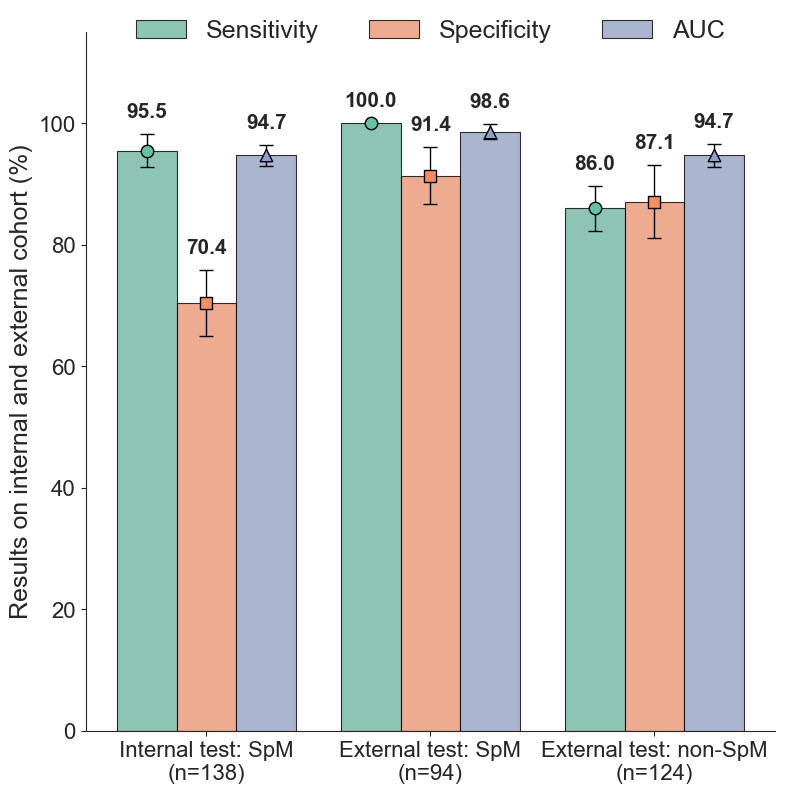

In [ ]:
# Three cohorts analysis: Bar plot with error bars
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score

def calculate_metrics_with_ci(y_true, y_prob, n_bootstraps=1000):
    """使用 Bootstrap 方法计算指标及其置信区间 (95% CI)"""
    y_pred = (y_prob > 0.5).astype(int)
    
    def get_base_metrics(yt, yp, ypp):
        cm = confusion_matrix(yt, yp)
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        auc = roc_auc_score(yt, ypp)
        return sens * 100, spec * 100, auc * 100

    sens_orig, spec_orig, auc_orig = get_base_metrics(y_true, y_pred, y_prob)
    
    boot_sens, boot_spec, boot_auc = [], [], []
    rng = np.random.RandomState(42)
    indices = np.arange(len(y_true))
    
    for _ in range(n_bootstraps):
        resample_idx = rng.choice(indices, size=len(indices), replace=True)
        try:
            se, sp, au = get_base_metrics(y_true[resample_idx], y_pred[resample_idx], y_prob[resample_idx])
            boot_sens.append(se); boot_spec.append(sp); boot_auc.append(au)
        except: continue
            
    return {
        'Sensitivity': [sens_orig, np.std(boot_sens)],
        'Specificity': [spec_orig, np.std(boot_spec)],
        'AUC': [auc_orig, np.std(boot_auc)]
    }

df = pd.read_csv(r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\three_cohorts_results_3factors_mini_convnext.csv")

group_filters = [
    ('Internal test: SpM', df[df['dataset_type'] == 'internal_test']),
    ('External test: SpM', df[(df['dataset_type'] == 'external_test') & (df['diag'] == 'SpM')]),
    ('External test: non-SpM', df[(df['dataset_type'] == 'external_test') & (df['diag'] != 'SpM')])
]

plot_data = []
for name, sub_df in group_filters:
    res = calculate_metrics_with_ci(sub_df['p_true_label'].values, sub_df['logreg_prob'].values)
    for metric, values in res.items():
        plot_data.append({
            'Cohort': f"{name}\n(n={len(sub_df)})",
            'Metric': metric,
            'Value': values[0],
            'Std': values[1]
        })

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(8, 8), dpi=100)
sns.set_style("ticks")

colors = ['#66c2a5', '#fc8d62', '#8da0cb']
metrics_list = ['Sensitivity', 'Specificity', 'AUC']

ax = sns.barplot(
    data=plot_df, x='Cohort', y='Value', hue='Metric',
    palette=colors, edgecolor='black', linewidth=0.8, alpha=0.8
)

x_coords = []
for i in range(len(group_filters)):
    n_metrics = len(metrics_list)
    width = 0.8 / n_metrics
    start = i - 0.4 + width/2
    for j in range(n_metrics):
        x_pos = start + j * width
        row = plot_df[(plot_df['Cohort'].str.startswith(group_filters[i][0])) & (plot_df['Metric'] == metrics_list[j])].iloc[0]
        
        plt.errorbar(x_pos, row['Value'], yerr=row['Std'], fmt='none', c='black', capsize=5, lw=1)
        
        marker = 'o' if j==0 else 's' if j==1 else '^'
        plt.scatter(x_pos, row['Value'], marker=marker, color=colors[j], edgecolors='black', s=80, zorder=3)

        plt.text(x_pos, row['Value'] + row['Std'] + 2, f"{row['Value']:.1f}", 
                 ha='center', va='bottom', fontsize=15, fontweight='bold')

plt.ylim(0, 115)
plt.ylabel('Results on internal and external cohort (%)', fontsize=18)
plt.xlabel('', fontsize=13)
plt.xticks(fontsize=16)
plt.yticks(np.arange(0, 101, 20), fontsize=16)


plt.legend(title='', frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=18)
sns.despine() 

plt.tight_layout()
plt.show()

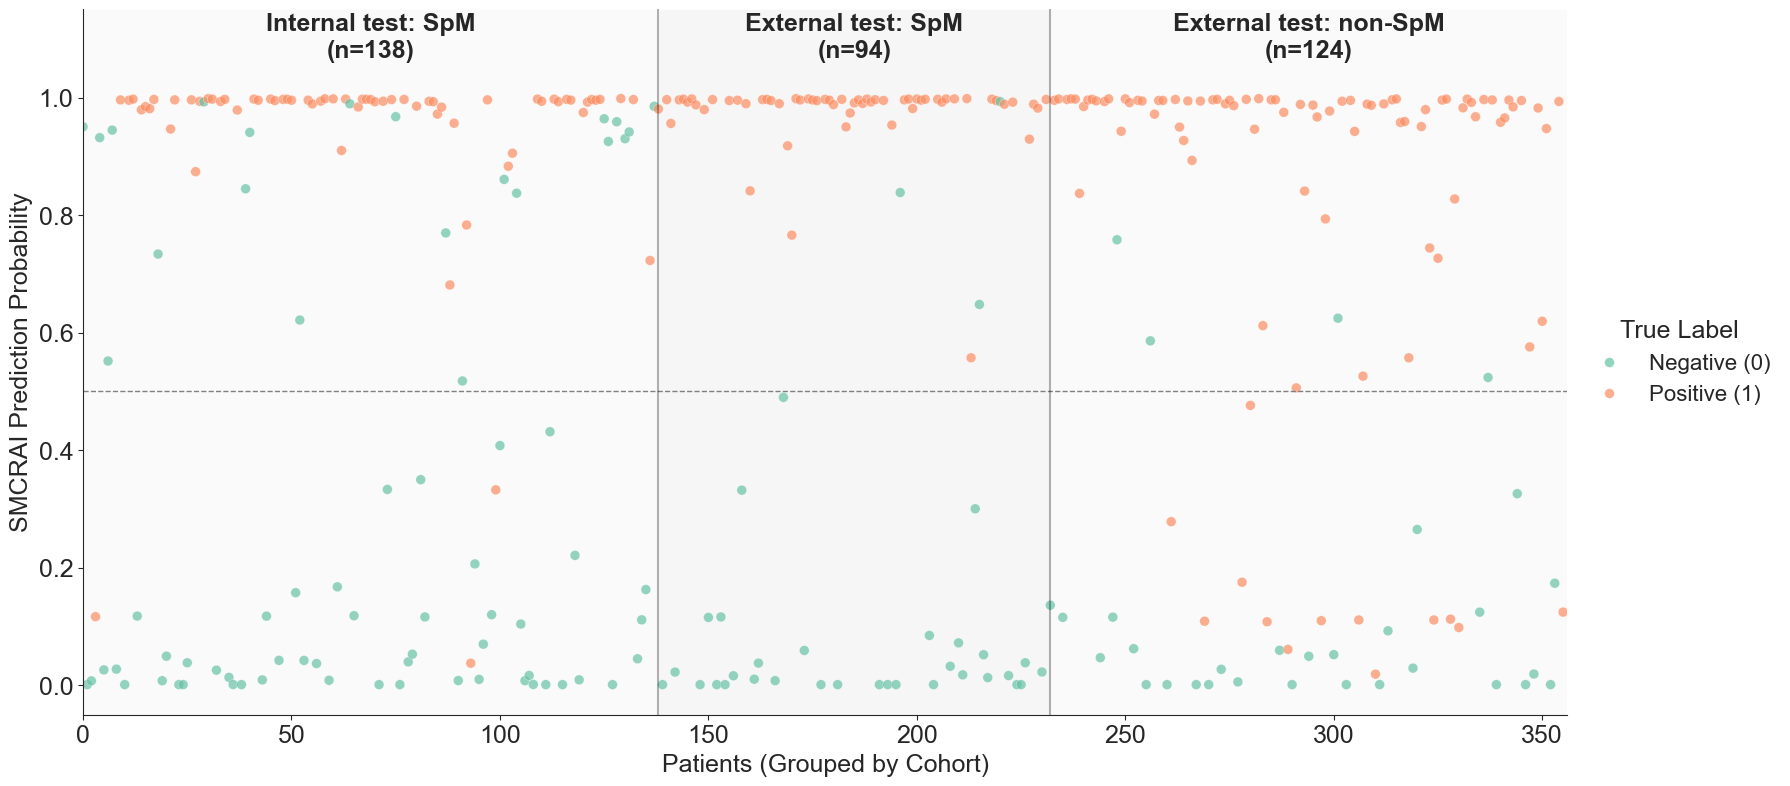

In [ ]:
# Three cohorts analysis: Scatter plot of probabilities
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\three_cohorts_results_3factors_mini_convnext.csv"
df = pd.read_csv(file_path)

df_list = []
labels = ['Internal test: SpM', 'External test: SpM', 'External test: non-SpM']

d1 = df[df['dataset_type'] == 'internal_test'].copy()
d2 = df[(df['dataset_type'] == 'external_test') & (df['diag'] == 'SpM')].copy()
d3 = df[(df['dataset_type'] == 'external_test') & (df['diag'] != 'SpM')].copy()

current_idx = 0
group_boundaries = [0]

for sub_df in [d1, d2, d3]:
    sub_df = sub_df.sample(frac=1, random_state=42) 
    sub_df['plot_idx'] = range(current_idx, current_idx + len(sub_df))
    current_idx += len(sub_df)
    group_boundaries.append(current_idx)
    df_list.append(sub_df)

df_all = pd.concat(df_list)

plt.figure(figsize=(18, 8), dpi=100)
sns.set_style("ticks")
colors = ["#66c2a5", "#fc8d62"] 

ax = sns.scatterplot(
    data=df_all,
    x='plot_idx', 
    y='logreg_prob',
    hue='p_true_label', 
    palette=colors,
    alpha=0.7,
    s=50,
    edgecolor='w',
    linewidth=0.3
)

v_colors = ['#f7f7f7', '#eeeeee', '#f7f7f7'] 
for i in range(len(group_boundaries)-1):
    start = group_boundaries[i]
    end = group_boundaries[i+1]
    plt.axvspan(start, end, facecolor=v_colors[i], alpha=0.5, zorder=0)
    if i > 0:
        plt.axvline(x=start, color='black', linestyle='-', lw=1.5, alpha=0.3)
    
    mid_point = (start + end) / 2
    plt.text(mid_point, 1.06, f"{labels[i]}\n(n={end-start})", 
             ha='center', va='bottom', fontsize=18, fontweight='bold')

plt.axhline(y=0.5, color='gray', linestyle='--', lw=1, zorder=1) 

plt.ylim(-0.05, 1.15)
plt.xlim(0, current_idx)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18) 
plt.ylabel('SMCRAI Prediction Probability', fontsize=18)
plt.xlabel('Patients (Grouped by Cohort)', fontsize=18)
plt.title('', fontsize=18, pad=40)

# plt.xticks([]) 

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Negative (0)', 'Positive (1)'], title='True Label', title_fontsize=18,
          loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=16)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Sub-diag analysis
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score

# 1. 加载数据
df = pd.read_csv(r"D:\MED\SpM\SpMjpg-20240920-sagcopy-mini\external_patient_predictions_logistics_3factors_convnext.csv")

# 2. 定义分组逻辑
def group_diag(diag):
    if diag == 'SpM':
        return 'SpM'
    elif diag in ['TDH', 'OL']:
        return 'TDH/OL'
    elif diag in ['TB', 'IF']:
        return 'TB/IF'
    elif diag == 'Prim':
        return 'Prim'
    else:
        return 'Other'

df['diag_group'] = df['diag'].apply(group_diag)

def calculate_metrics(group):
    y_true = group['p_true_label']
    y_pred = group['logreg_pred']
    y_prob = group['logreg_prob']
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    accuracy = (y_true == y_pred).mean()
    
    try:
        auc = roc_auc_score(y_true, y_prob) if len(y_true.unique()) > 1 else float('nan')
    except:
        auc = float('nan')
        
    return pd.Series({
        'Total Samples': len(y_true),
        'Accuracy': round(accuracy, 4),
        'Sensitivity': round(sensitivity, 4),
        'Specificity': round(specificity, 4),
        'AUC': round(auc, 4) if pd.notnull(auc) else "N/A",
        'F1-score': round(f1, 4)
    })

results = df.groupby('diag_group').apply(calculate_metrics).reset_index()
results.to_csv('detailed_metrics_by_diag_group.csv', index=False)
print(results)

  diag_group  Total Samples  Accuracy  Sensitivity  Specificity     AUC  \
0       Prim           14.0    0.9286       0.8750       1.0000  0.9375   
1        SpM           94.0    0.9681       1.0000       0.9143  0.9864   
2      TB/IF           71.0    0.9577       1.0000       0.8696  0.9964   
3     TDH/OL           39.0    0.6667       0.6757       0.5000  0.7703   

   F1-score  
0    0.9333  
1    0.9752  
2    0.9697  
3    0.7937  
